# Budget Estimation for Calls for Proposals

Predicting the **budget tier of a Ministry of Education call for proposals (קול קורא)** from the research methodology that the call is expected to attract.

**Run order:** top to bottom (*Kernel → Restart & Run All*). Every cross-validation in this notebook uses **`StratifiedGroupKFold` grouped by `call_group`**, except the one leakage demonstration in [§6.6](#leakage-demo), which is labelled as leaky on purpose.

## Table of Contents

0. [Background & Problem Framing](#background)
1. [Setup & Imports](#setup)
2. [Data Loading & Attribution](#loading)
3. [Data Dictionary](#dictionary)
4. [Exploratory Data Analysis (EDA)](#eda)
    - 4.1 [Structure](#eda-structure) · 4.2 [Missing values](#eda-missing) · 4.3 [Cleaning & project scope](#eda-cleaning) · 4.4 [Univariate distributions](#eda-univariate) · 4.5 [Correlation analysis](#eda-correlation)
5. [Feature Engineering](#feature-engineering)
    - 5.1 [Input-range binning](#fe-binning) · 5.2 [Association screening (Cramér's V)](#fe-cramers) · 5.3 [Modeling scope](#fe-scope) · 5.4 [Call identity — `call_group`](#fe-call-group) · 5.5 [Call year — `call_year`](#fe-call-year) · 5.6 [Year-level context features](#fe-year-features) · 5.7 [Model matrix](#fe-matrix)
6. [Methodology & Statistical Validity](#methodology)
    - 6.1 [Unit of observation vs. unit of target](#meth-unit) · 6.2 [Why the approach is valid — and what it does not claim](#meth-validity) · 6.3 [Leakage and grouped cross-validation](#meth-leakage) · 6.4 [Leakage risk in the year-level features](#meth-year-leakage) · 6.5 [Evaluation protocol](#meth-protocol) · 6.6 [Leakage demonstration](#leakage-demo)
7. [Modeling](#modeling)
    - 7.1 [Baseline — multinomial LR (L1)](#model-baseline) · 7.2 [Feature reduction](#model-reduction) · 7.3 [Reduced + year-level features](#model-year) · 7.4 [Ordinal logistic regression](#model-ordinal) · 7.5 [Hyperparameter tuning](#model-tuning)
8. [Results & Analysis](#results)
9. [Conclusions & Next Steps](#conclusions)
10. [Appendix — Revision log](#revision-log)

<a id="background"></a>
# 0. Background & Problem Framing

A **call for proposals (קול קורא)** is research that the Ministry of Education publishes to the public with a budget that is **fixed before publication** — before any researcher has submitted a proposal. This notebook estimates that budget tier.

1. **Data structure.** 140 records, each extracted from a *"golden triangle"* of source documents: call for proposals + research proposal + budget breakdown. **One row = one research proposal, not one call.** Several proposals can be submitted to the same call.

2. **The target (`target_budget`) is an attribute of the call, not of the individual proposal.** The Ministry sets it *before* the call is published, before any proposal exists. Every proposal submitted to the same call shares exactly the same target value.

3. **Modeling goal.** Learn the statistical pattern between the methodology that researchers tend to propose (`duration_months`, `data_waves_count`, `collection_mode`, …) and the budget that was already fixed for the call they applied to. In the future, when the Ministry itself defines the desired methodology for a new call (before publication), the model can then suggest a price. **Therefore there is no need to reduce the data to a single winning proposal per call:** every proposal, winning or not, is a valid observation of *"what researchers propose, given a budget X"*.

4. **Critical methodological caveat.** Historical prices were set *before* the methodology was known. The relationship the model learns is therefore **associative (correlational) and not necessarily causal** in the direction *methodology → budget*. History may reflect the reverse process: *budget already fixed → researchers proposed a methodology that fits it*. This does not rule out the statistical use, because an associative comparison is still useful as a **benchmark**. It is a limitation that must be stated clearly in any report built on this model.

5. **A leakage problem was found and fixed.** Several proposals from the same call share exactly the same target. A plain `StratifiedKFold` therefore leaked information between train and test: *"sibling"* proposals from the same call were split across folds, which artificially inflated CV scores by **~9–10 percentage points**. **Fix: `StratifiedGroupKFold`**, grouped by `call_group` (a normalized field derived from `call_title`), so all proposals from the same call stay together in one fold.
   **Why this removes the need to collect more data:** the problem was not the sample size. It was the **measurement method** (how performance is estimated), not the amount of data itself. Fixing the CV scheme gives an honest, reliable performance estimate on the same existing data, without collecting more researchers or calls.

6. **`call_title` normalization.** Titles of the same call were written in different formats (different date order, different punctuation), so they were wrongly counted as **33 separate "groups"**. The function `normalize_call_title` extracts the numbers (call number + year) and groups by them, falling back to normalized text for titles without a number. The result was **18 real groups**. *This revision tightens the normalization further (2-digit years, number-less titles that belong to a numbered call). See [§5.4](#fe-call-group).*

**Project scope.** The model covers research budgets **up to 1,000,000 NIS**. Proposals above this threshold go through a separate committee review, so they are excluded from both the dataset and the problem definition. In the current data this affects only ~5 records (all at the 4,000,000 NIS tier). The scoping cost is minimal, and it also removes the most extreme tail driving the target's skewness. For modeling, the scope is narrowed further to **≤ 500,000 NIS** ([§5.3](#fe-scope)).

<a id="setup"></a>
# 1. Setup & Imports

In [1]:
# --- Standard library ---
import re
import warnings
from pathlib import Path

# --- Data handling ---
import numpy as np
import pandas as pd

# --- Statistics ---
from scipy import stats
from scipy.stats import skew, kurtosis, median_abs_deviation, chi2_contingency

# --- Visualization ---
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotnine as pln
from plotnine import (
    ggplot, aes, geom_col, geom_errorbar, geom_text, geom_vline,
    coord_flip, labs, theme_minimal, theme, element_text, element_blank,
)
from IPython.display import display, Markdown

# --- Modeling ---
import sklearn
import mord
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import (
    StratifiedKFold, StratifiedGroupKFold, LeaveOneGroupOut, cross_validate, cross_val_predict, GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
# ---------------------------------------------------------------
# Global configuration: every downstream cell reads from here
# ---------------------------------------------------------------
DATA_PATH = Path(r"C:\Users\idowe\MyProjects\MOECSO\budget_estimation\research_table_with_budget_and_sources.csv")

RANDOM_STATE = 42
N_SPLITS = 5                        # folds of the StratifiedGroupKFold splitter
N_CANDIDATE_SEEDS = 200             # seeds scanned for DISTINCT grouped partitions (see section 6.5)
N_BOOT = 2000                       # call-level bootstrap resamples for confidence intervals
SCORING = ["accuracy", "f1_macro", "f1_weighted"]
scoring = SCORING                                          # original name, kept for compatibility

SCOPE_MAX_BUDGET = 1_000_000        # project scope (above this: separate committee track)
MODEL_SCOPE_MAX_BUDGET = 500_000    # modeling scope (drops the n=9 top tier, see section 5.3)
YEAR_MIN, YEAR_MAX = 2015, 2030     # plausible publication years for call-year extraction
YEAR_CONTEXT_MAX_BUDGET = None      # calls counted in the year-level features: None = every call in the dataset

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

pandas 3.0.2 | numpy 2.4.2 | scikit-learn 1.9.0


<a id="loading"></a>
# 2. Data Loading & Attribution

This dataset was built from **140 Israeli Ministry of Education research grant records**. Each row is **one research proposal**, extracted from a *"golden triangle"* of three source documents:

1. **Call for proposals** (קול קורא): the funding call under which the proposal was submitted
2. **Research proposal** (הצעת מחקר): the PI's submitted research design
3. **Budget breakdown** (פילוח תקציבי): the itemized budget allocation for the proposal

Structured fields (25 attributes per record, including study-design parameters, methodology flags and budgeted person-work) were extracted from each triangle with **Google NotebookLM**. They were then consolidated, validated and merged into a single table through manual QA.

In [3]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns from '{DATA_PATH.name}'")
df.head()

Loaded 140 rows x 27 columns from 'research_table_with_budget_and_sources.csv'


,source_file,call_title,pi_name,proposal_title,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,has_interviews,has_focus_groups,has_observations,has_tests,collection_mode,tool_development_type,languages_count,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,deliverables_level,has_special_equipment,is_multidisciplinary,target_budget
0,אורטל_סלובדין_21.txt,קול קורא מס' 2021.11/27 למחקר בנושא החינוך בחב...,פרופ' אורטל סלובודין,"הארון הכפול: נוער להט""בי במערכת החינוך הערבית ...",18,80,80,-1,-1,0,1,0,0,0,Online,Unknown,3,-1,0,0,0,125280.0,1,Unknown,0,-1,300000
1,אורטל_סלובדין_24.txt,קול קורא מס' 15/5.2024 למחקר בנושא חינוך בצל מ...,"פרופ' אורטל סלובודין, פרופ' הללי פינסון",חסמים באיתור ובהשתתפות תלמידים/ות מהחברה הבדוא...,18,8,100,2,1,0,1,0,0,0,Mixed,New,2,1,1,0,1,134676.0,1,Extended,0,1,200000
2,אורי_כהן_21.txt,קול קורא מס' 27/11.2021 למחקר בנושא החינוך בחב...,אורי כהן,יחסי גומלין בין מנהל החינוך ברשות המקומית לבתי...,18,25,65,3,-1,0,1,0,0,0,Field,Unknown,2,-1,0,0,0,248400.0,0,Unknown,0,-1,300000
3,אורית_חזן_24.txt,"קול קורא מס' 27/8.24 למחקר בנושא ""קבלת החלטות ...",אורית חזן,קבלת החלטות בית ספריות מבוססות נתונים בקרב מנה...,16,25,175,1,2,1,1,0,0,0,Mixed,New,1,0,0,0,1,217500.0,1,Standard,0,0,250000
4,אורלי_ליפקה_24.txt,קול קורא מס 15/5.2024 למחקר בנושא חינוך בצל מש...,"אורלי ליפקה, תמר קציר",חוסן אישי ותחושת שלומות של מורים בחברה הערבית ...,18,-1,1255,2,2,1,0,1,0,1,Online,Adaptation,1,1,0,0,1,135000.0,1,Extended,0,1,200000


<a id="dictionary"></a>
# 3. Data Dictionary

**Source fields**, as specified in the extraction prompt given to NotebookLM:

| Column | Type | Description |
|---|---|---|
| `source_file` | string | Name of the source text file (the 2-digit suffix is used only as a last-resort year fallback, see §5.5) |
| `call_title` | string | Title of the call for proposals (קול קורא) |
| `pi_name` | string | Name of the principal investigator(s) |
| `proposal_title` | string | Title of the submitted research proposal |
| `duration_months` | int | Research duration in months (`-1` = unknown) |
| `site_count` | int | Number of research sites / participating schools (`-1` = unknown) |
| `subject_count` | int | Number of research subjects / participants (`-1` = unknown) |
| `target_populations_count` | int | Number of distinct target populations (`-1` = unknown) |
| `data_waves_count` | int | Number of data-collection waves (`-1` = unknown) |
| `has_surveys` | binary | Uses questionnaires/surveys (1 = yes, 0 = no, -1 = unknown) |
| `has_interviews` | binary | Uses interviews (1/0/-1) |
| `has_focus_groups` | binary | Uses focus groups (1/0/-1) |
| `has_observations` | binary | Uses observations (1/0/-1) |
| `has_tests` | binary | Uses tests/assessments (1/0/-1) |
| `collection_mode` | categorical | Primary data-collection mode: `Online`, `Field`, `SurveyInstitute`, `Mixed`, `Unknown` |
| `tool_development_type` | categorical | Level of instrument development: `Existing`, `Adaptation`, `New`, `Validation`, `Unknown` |
| `languages_count` | int | Number of languages used (`-1` = unknown) |
| `requires_translation` | binary | Requires translation / cultural adaptation (1/0/-1) |
| `uses_admin_data` | binary | Uses administrative / research-room data (1/0/-1) |
| `requires_data_linking` | binary | Requires linking/merging of datasets (1/0/-1) |
| `is_complex_design` | binary | Complex design (control group / complex population) (1/0/-1) |
| `budgeted_person_work` | int/float | Total budgeted amount for personnel work, in NIS (a monetary value, not months; `-1` = unknown) |
| `has_external_services` | binary | Purchases external services (surveys, statistics, editing) (1/0/-1) |
| `deliverables_level` | categorical | Scope of deliverables: `Standard`, `Extended`, `Unknown` |
| `has_special_equipment` | binary | Includes dedicated equipment in the budget (1/0/-1) |
| `is_multidisciplinary` | binary | Multidisciplinary research (1/0/-1) |
| `target_budget` | int | **Target.** Budget fixed for the call, in NIS |

**Engineered fields** (created in [§5](#feature-engineering)):

| Column | Level | Description |
|---|---|---|
| `<feature>_bin` | proposal | Ordered range bins of the continuous inputs, with an explicit `Not yet decided` bin |
| `target_budget_bin` | call | Target tier (4 tiers in EDA, 3 tiers in the modeling scope) |
| `call_group` | call | Canonical call identity: the **grouping key for every CV** |
| `call_year` | call | Publication year of the call |
| `num_calls_year_excl_self` | call | Number of **other** calls published in the same year (leave-one-out) |
| `total_budget_year_excl_self` | call | Sum of the budgets of those **other** calls (leave-one-out) |

<a id="eda"></a>
# 4. Exploratory Data Analysis (EDA)

<a id="eda-structure"></a>
## 4.1 Structure

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   source_file               140 non-null    str    
 1   call_title                140 non-null    str    
 2   pi_name                   140 non-null    str    
 3   proposal_title            140 non-null    str    
 4   duration_months           140 non-null    int64  
 5   site_count                140 non-null    int64  
 6   subject_count             140 non-null    int64  
 7   target_populations_count  140 non-null    int64  
 8   data_waves_count          140 non-null    int64  
 9   has_surveys               140 non-null    int64  
 10  has_interviews            140 non-null    int64  
 11  has_focus_groups          140 non-null    int64  
 12  has_observations          140 non-null    int64  
 13  has_tests                 140 non-null    int64  
 14  collection_mode      

<a id="eda-missing"></a>
## 4.2 Missing values

The extraction prompt encodes *unknown* as **`-1`**, so `isnull()` finds no `NaN` in the raw file. The `-1` counts are the real measure of missingness.

In [5]:
print(f"NaN cells in the raw data: {df.isnull().sum().sum()}")   # expected 0: unknowns are encoded as -1

counts = (df == -1).sum()
percent = (counts / len(df) * 100).round(1)
missing_raw = pd.DataFrame({"count": counts, "percent": percent}).sort_values("count", ascending=False)
missing_raw[missing_raw["count"] > 0]

NaN cells in the raw data: 0


,count,percent
site_count,74,52.9
languages_count,56,40.0
data_waves_count,51,36.4
subject_count,37,26.4
target_populations_count,34,24.3
is_multidisciplinary,24,17.1
requires_translation,11,7.9
requires_data_linking,6,4.3
is_complex_design,5,3.6
uses_admin_data,4,2.9


### Interpretation of the `-1` counts (140 raw records)

- **Text fields** (`source_file`, `call_title`, `pi_name`, `proposal_title`): 0% missing. These are copied names/titles, so something is always there.
- **`duration_months`** (0.7%): almost every proposal states its duration, which is a basic requirement of any proposal.
- **`site_count`** (52.9%): the largest gap. Many studies (online surveys, phone interviews) do not work through a fixed number of sites, or the number was simply not stated.
- **`subject_count`** (26.4%): about 1 in 4 proposals omit the sample size, possibly because it was not yet decided at proposal stage.
- **`target_populations_count`** (24.3%): often not stated explicitly, especially when there is a single obvious population.
- **`data_waves_count`** (36.4%): many studies collect data once, so "waves" do not apply, or the number is not stated.
- **Binary methodology flags**: almost always known, because whether a study uses surveys or interviews is usually obvious from the proposal.

**Bottom line:** missingness is **not random**. It concentrates in the "give me an exact number" fields (sites, subjects, populations, waves), which require someone to write down a specific number that is often only settled during the research itself. The yes/no methodology questions are almost always answered.

### NotebookLM labeling audit (open item)

High missingness in `site_count` (52.9%), `data_waves_count` (36.4%) and `languages_count` (40%) does not necessarily mean the information was absent from the source triangle. It may instead reflect **NotebookLM failing to extract data that was present**. Before excluding or imputing these features, a manual audit is needed: sample ~15–20 missing rows per suspect feature, check the original documents, and classify each case as either **(a) genuinely missing** or **(b) an extraction failure**. A high extraction-failure rate means the fix is a better prompt / re-run, not feature exclusion.

The audit matters even more because of the input-range binning in [§5.1](#fe-binning). Once a feature becomes a small set of user-facing ranges, an explicit **"Not yet decided"** option can be a legitimate bin, which is exactly the situation of an early-stage researcher filling in the tool. If the missingness reflects a genuine *not-yet-decided* state rather than a labeling failure, it becomes a **first-class, predictive category** instead of a problem to clean away.

<a id="eda-cleaning"></a>
## 4.3 Cleaning & project scope

Two steps: **(1)** convert `-1` to `NaN` so that statistical methods treat unknowns correctly, and **(2)** apply the project scope (`target_budget ≤ 1,000,000 NIS`).

In [6]:
cols_with_unknown = df.select_dtypes(include=["number"]).columns.tolist()   # numeric columns that may hold -1
df_clean = df.copy()
df_clean[cols_with_unknown] = df_clean[cols_with_unknown].replace(-1, np.nan)

original_n = len(df)
df_clean = df_clean[df_clean["target_budget"] <= SCOPE_MAX_BUDGET].reset_index(drop=True)
after_n = len(df_clean)
print(f"Project scope (target_budget <= {SCOPE_MAX_BUDGET:,} NIS): {original_n} -> {after_n} rows "
      f"({original_n - after_n} excluded)")

print("\nMissing values after cleaning and scoping:")
df_clean.isnull().sum().loc[lambda s: s > 0].sort_values(ascending=False)

Project scope (target_budget <= 1,000,000 NIS): 140 -> 135 rows (5 excluded)

Missing values after cleaning and scoping:


site_count                  72
languages_count             56
data_waves_count            50
target_populations_count    34
subject_count               33
is_multidisciplinary        24
requires_translation        11
requires_data_linking        6
is_complex_design            5
uses_admin_data              4
has_tests                    2
has_focus_groups             2
has_observations             2
budgeted_person_work         2
duration_months              1
has_surveys                  1
has_interviews               1
dtype: int64

<a id="eda-univariate"></a>
## 4.4 Univariate distributions

### 4.4.1 Column groups & statistical summary

In [7]:
numeric_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()

binary_cols = ["has_surveys", "has_interviews", "has_focus_groups", "has_observations",
               "has_tests", "requires_translation", "uses_admin_data",
               "requires_data_linking", "is_complex_design", "has_external_services",
               "has_special_equipment", "is_multidisciplinary"]

continuous_cols = ["duration_months", "site_count", "subject_count",
                   "target_populations_count", "data_waves_count",
                   "languages_count", "budgeted_person_work", "target_budget"]

categorical_cols = ["collection_mode", "tool_development_type", "deliverables_level"]

In [8]:
summary = df_clean.describe().T

# MAD = median(|x - median(x)|); scale=1 keeps the raw MAD (no rescaling to a normal-distribution std)
summary["MAD"] = df_clean[summary.index].apply(lambda col: median_abs_deviation(col.dropna(), scale=1))
summary

,count,mean,std,min,25%,50%,75%,max,MAD
duration_months,134.0,24.522388,8.917092,16.0,18.00,18.0,36.0,60.0,0.0
site_count,63.0,49.555556,79.251290,1.0,8.00,25.0,55.0,500.0,20.0
subject_count,102.0,1103.794118,2114.473201,25.0,156.25,490.0,1057.5,14400.0,390.0
target_populations_count,101.0,2.316832,1.028890,1.0,2.00,2.0,3.0,7.0,1.0
data_waves_count,85.0,2.141176,0.861241,1.0,2.00,2.0,3.0,5.0,1.0
has_surveys,134.0,0.843284,0.364897,0.0,1.00,1.0,1.0,1.0,0.0
has_interviews,134.0,0.701493,0.459320,0.0,0.00,1.0,1.0,1.0,0.0
has_focus_groups,133.0,0.210526,0.409224,0.0,0.00,0.0,0.0,1.0,0.0
has_observations,133.0,0.210526,0.409224,0.0,0.00,0.0,0.0,1.0,0.0
has_tests,133.0,0.278195,0.449804,0.0,0.00,0.0,1.0,1.0,0.0


In [9]:
skew_kurt = pd.DataFrame({
    "Skewness": df_clean[continuous_cols].apply(lambda x: skew(x.dropna())),
    "Kurtosis": df_clean[continuous_cols].apply(lambda x: kurtosis(x.dropna())),
}).sort_values("Skewness", ascending=False)

skew_kurt

,Skewness,Kurtosis
subject_count,4.373755,21.424804
site_count,3.633777,16.075457
target_budget,2.119663,4.245004
budgeted_person_work,1.994417,4.479514
duration_months,1.323853,1.730211
target_populations_count,1.274849,3.345894
data_waves_count,0.625611,0.452306
languages_count,0.253087,-0.627509


### 4.4.2 Continuous variables

| Feature | Missingness | Reading | Outliers |
|---|---|---|---|
| `site_count` | very high (~53%) | Either poor NotebookLM labeling or genuinely not stated in the triangle. On its own, expected to carry little signal. | Present; compare against the source triangle |
| `subject_count` | ~25% | Same two explanations as above. | Extreme right tail (up to ~14k), compare against source |
| `budgeted_person_work` ⚠ | ~1% | Labeled well. | May represent uniquely funded studies |
| `duration_months` | <1% | Labeled well. | Values cluster on conventional lengths (16/18/24/36/60) |
| `target_populations_count` | ~25% | Labeled reasonably. | A few studies with 5+ populations |
| `data_waves_count` | ~37% | Poor labeling or not stated. | Small, tight range (1–5) |
| `languages_count` | ~40% | Poor labeling or not stated. | Narrow range (1–3) |

**⚠ Excluded from training: `budgeted_person_work`.** This feature is dropped before modeling, for two independent reasons:

1. **Leakage risk.** It is extracted from the same source document as `target_budget` (the budget breakdown) and is almost collinear with it (Pearson r ≈ 0.9–0.96, see §4.5).
2. **Not available at prediction time.** Whoever prices a call does not yet know how much will go to personnel specifically. This value is a *downstream breakdown* of the total budget, not an independent input that precedes it.

Each block below shows the 10 largest values (for outlier checks against the source triangle) and a histogram + boxplot annotated with skewness and kurtosis.

In [10]:
def plot_continuous(feature, bins, kde=False, thousands=False):
    """Histogram + boxplot of one continuous feature, annotated with the skewness/kurtosis above."""
    values = df_clean[feature].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
    sns.histplot(values, bins=bins, kde=kde, ax=axes[0], color="steelblue")
    axes[0].set_title(f"Histogram - {feature}")
    sns.boxplot(y=values, ax=axes[1], color="lightcoral")
    axes[1].set_title("Boxplot")

    if thousands:
        # plain thousands separators (e.g. "1,500,000") instead of matplotlib's offset notation
        axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
        axes[0].tick_params(axis="x", rotation=45)
        axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))

    s, k = skew_kurt.loc[feature, "Skewness"], skew_kurt.loc[feature, "Kurtosis"]
    n_missing = df_clean[feature].isna().sum()
    fig.suptitle(f"{feature}  |  n={len(values)}, missing={n_missing}  |  skew={s:.2f}, kurtosis={k:.2f}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def top_rows(feature, extra_cols=(), n=10):
    """The n largest values of a feature, with identifying columns for manual checks against the source."""
    cols = list(dict.fromkeys(["source_file", "pi_name", "proposal_title", *extra_cols, feature]))
    return df_clean.nlargest(n, feature)[cols]


CONTINUOUS_PLOT_CONFIG = {
    "site_count":               dict(bins=34, kde=True, extra_cols=("subject_count",)),
    "subject_count":            dict(bins=63, kde=True, extra_cols=("site_count",)),
    "budgeted_person_work":     dict(bins=200, kde=True, thousands=True, extra_cols=("duration_months",)),
    "duration_months":          dict(bins=6),
    "target_populations_count": dict(bins=6),
    "data_waves_count":         dict(bins=5),
    "languages_count":          dict(bins=4),
}

#### `site_count`

,source_file,pi_name,proposal_title,subject_count,site_count
102,שושי_דורפברגר_24.txt,"ד""ר אנאבל פרידלנדר-ליפסיק, ד""ר שושי דורפברגר",הקשר בין קבלת החלטות מבוססת נתונים על ידי מנהל...,NaN,500.0
99,רימאא_דעאס_21.txt,רימאא דעאס,"מנהלים משבר: פיתוח כלי למדידת ""ניהול בזמן משבר""",2500.0,300.0
24,גוי_בנטוב_25.txt,"ד""ר ג'וי בנטוב, פרופ' נוגה כהן, ד""ר דנה לסרי","הערכת קבלת, יישמות, ויעילות התוכנית הבית ספרית...",14400.0,180.0
44,יאיר_זיו_23.txt,"פרופ' יאיר זיו, פרופ' אסתר עדי יפה",הערכת תכניות להכשרה פדגוגית של מחנכים מטפלים ב...,NaN,160.0
75,נטע_אחדות_21.txt,נטע אחדות,הקשר בין מאפייני התלמיד ומאפייני היישוב לקורבנ...,NaN,160.0
124,יוסי_פיש_21.txt,פרופ' יוסי הראל-פיש,גורמי חוסן והגנה וגורמי סיכון במרחבים של מערכת...,12000.0,143.0
43,יאיר_זיו_21.txt,פרופ' יאיר זיו,החינוך בחברה הערבית בישראל,2440.0,120.0
21,ברוריה_עדיני_21.txt,"ד""ר ברוריה עדיני",חוסן פונקציונלי של בתי הספר: הפקת לקחים ממגפת ...,NaN,100.0
25,גלי_בנימין_25.txt,"ד""ר גלי בנימין",אימוץ בינה מלאכותית בהוראה: השפעת גורמים ארגונ...,400.0,100.0
33,איריס_בן_דוד_הדר_25.txt,איריס בן דוד הדר,הערכת השפעת פיילוט הלמידה המקצועית על התפתחות ...,NaN,100.0


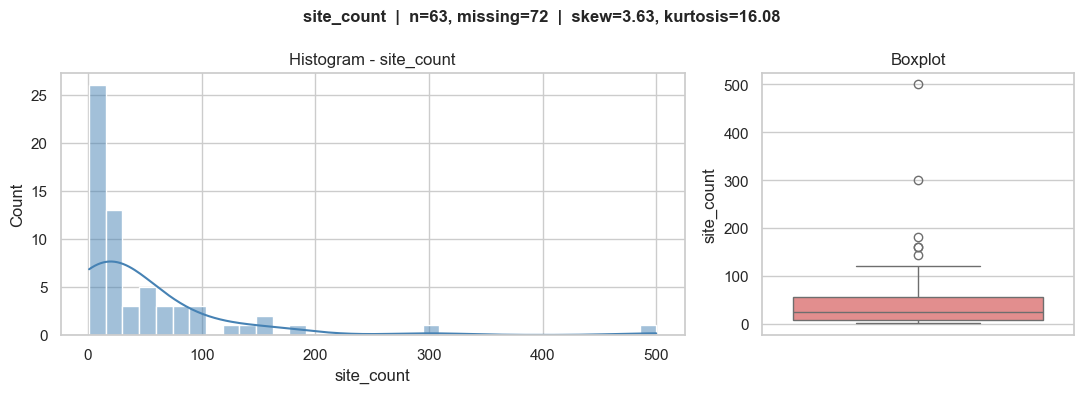

#### `subject_count`

,source_file,pi_name,proposal_title,site_count,subject_count
24,גוי_בנטוב_25.txt,"ד""ר ג'וי בנטוב, פרופ' נוגה כהן, ד""ר דנה לסרי","הערכת קבלת, יישמות, ויעילות התוכנית הבית ספרית...",180.0,14400.0
124,יוסי_פיש_21.txt,פרופ' יוסי הראל-פיש,גורמי חוסן והגנה וגורמי סיכון במרחבים של מערכת...,143.0,12000.0
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,16.0,8480.0
15,אימאן_גרה_עלוש_23.txt,"ד""ר אימאן גרה עלוש",שחק אותה: פיתוח אוריינות השפה העברית בקרב תלמי...,30.0,5000.0
5,אורלי_ליפקה_25.txt,אורלי ליפקה,בינה מלאכותית יוצרת: מהבנה ליישום במערכת החינו...,10.0,4250.0
84,ראויה_חאיק_25.txt,ראויה חאיק,השפעות בינה מלאכותית יוצרת על תלמידים ועובדי ה...,80.0,3900.0
67,מירי_ימיני_21.txt,Unknown,הוראה ולמידה מרחוק בעתות של ריחוק חברתי - חקר ...,16.0,3820.0
45,יאסר_עואד_24.txt,פרופ' יאסר עואד,רווחה והתנהגות סיכון בקרב תלמידים בתקופת המשבר...,60.0,3000.0
110,רול_25.txt,עדו רול,"אוריינות בינה מלאכותית בגילאי חטה""ב ותיכון - ת...",NaN,3000.0
99,רימאא_דעאס_21.txt,רימאא דעאס,"מנהלים משבר: פיתוח כלי למדידת ""ניהול בזמן משבר""",300.0,2500.0


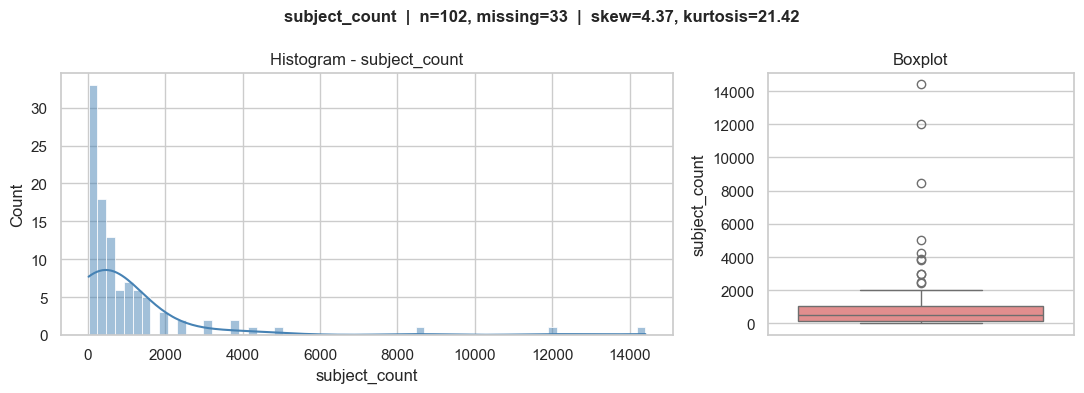

#### `budgeted_person_work`

,source_file,pi_name,proposal_title,duration_months,budgeted_person_work
108,תומס_גומפל_24.txt,פרופ' תומס גומפל,התמקצעות של מורים להוראה בכיתה ההטרוגנית: יישו...,60.0,848950.0
122,מירי_טל_23.txt,"ד""ר מירי טל סבן",תרומת תהליך ההכשרה הפדגוגי של מחנכות-מטפלות במ...,36.0,762336.0
28,דורית_טובין_25.txt,פרופ' דורית טובין,למידת מורים מקצועית בבית הספר,36.0,748440.0
33,איריס_בן_דוד_הדר_25.txt,איריס בן דוד הדר,הערכת השפעת פיילוט הלמידה המקצועית על התפתחות ...,36.0,715000.0
44,יאיר_זיו_23.txt,"פרופ' יאיר זיו, פרופ' אסתר עדי יפה",הערכת תכניות להכשרה פדגוגית של מחנכים מטפלים ב...,36.0,684000.0
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,60.0,675830.0
29,דינה_ציבולסקי_25__2_.txt,דינה ציבולסקי,מחקר מלווה לפיילוט המבוסס על מודל חדש ללמידת מ...,36.0,622000.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,36.0,560000.0
110,רול_25.txt,עדו רול,"אוריינות בינה מלאכותית בגילאי חטה""ב ותיכון - ת...",36.0,421800.0
128,ירדן_גליקסמן_24.txt,Unknown,תהליכים נוירופדגוגיים - ממיפוי להתערבות,36.0,421093.0


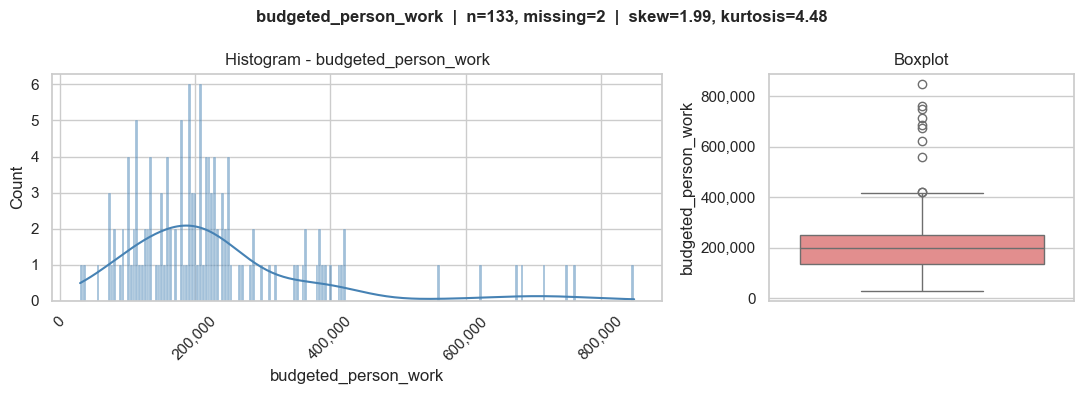

#### `duration_months`

,source_file,pi_name,proposal_title,duration_months
108,תומס_גומפל_24.txt,פרופ' תומס גומפל,התמקצעות של מורים להוראה בכיתה ההטרוגנית: יישו...,60.0
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,60.0
5,אורלי_ליפקה_25.txt,אורלי ליפקה,בינה מלאכותית יוצרת: מהבנה ליישום במערכת החינו...,36.0
6,אורלי_רובינשטיין_24.txt,"אורלי רובינשטיין, נגה כהן","""לדבר את החשיבה"" אימון תפקודים קוגניטביים גבוה...",36.0
15,אימאן_גרה_עלוש_23.txt,"ד""ר אימאן גרה עלוש",שחק אותה: פיתוח אוריינות השפה העברית בקרב תלמי...,36.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,36.0
20,בנטוב25.txt,Unknown,דפוסי שימוש והשפעות בינה מלאכותית יוצרת (במ״י)...,36.0
25,גלי_בנימין_25.txt,"ד""ר גלי בנימין",אימוץ בינה מלאכותית בהוראה: השפעת גורמים ארגונ...,36.0
28,דורית_טובין_25.txt,פרופ' דורית טובין,למידת מורים מקצועית בבית הספר,36.0
29,דינה_ציבולסקי_25__2_.txt,דינה ציבולסקי,מחקר מלווה לפיילוט המבוסס על מודל חדש ללמידת מ...,36.0


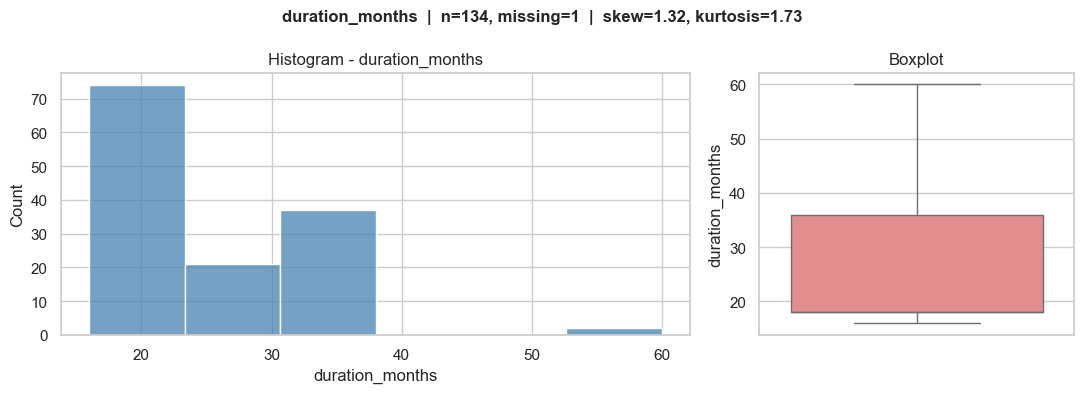

#### `target_populations_count`

,source_file,pi_name,proposal_title,target_populations_count
41,טלי_טל_21.txt,פרופ' טלי טל,"""כן, גם בשבילנו"": חינוך בסביבות למידה לא פורמא...",7.0
16,אבו_נסרא_24.txt,"ד""ר מוחמד אבו נסרה",משאבים לחוסן של מורים ומנהלים ערבים בצל משבר מ...,5.0
82,קורץ_אמזלג_אבידב_25.txt,פרופ' גילה קורץ,"ממשקים, תפיסות והשפעות של שימוש בבינה מלאכותית...",5.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,4.0
21,ברוריה_עדיני_21.txt,"ד""ר ברוריה עדיני",חוסן פונקציונלי של בתי הספר: הפקת לקחים ממגפת ...,4.0
56,זהבית_גרוס_21.txt,פרופ' זהבית גרוס,מאפייני פעילות החינוך הבלתי פורמאלי בבית הספר ...,4.0
78,נעמי_שרויאר_21.txt,פרופ' נעמי שרויאר,"יישום תוכנית הכנה לחיי עבודה (בלשנ""א) לבני נוע...",4.0
81,צמרת_ריקון_24.txt,"ד""ר צמרת ריקון",חוויות הורים יהודים וערבים שקיבלו הוראת פינוי ...,4.0
122,מירי_טל_23.txt,"ד""ר מירי טל סבן",תרומת תהליך ההכשרה הפדגוגי של מחנכות-מטפלות במ...,4.0
124,יוסי_פיש_21.txt,פרופ' יוסי הראל-פיש,גורמי חוסן והגנה וגורמי סיכון במרחבים של מערכת...,4.0


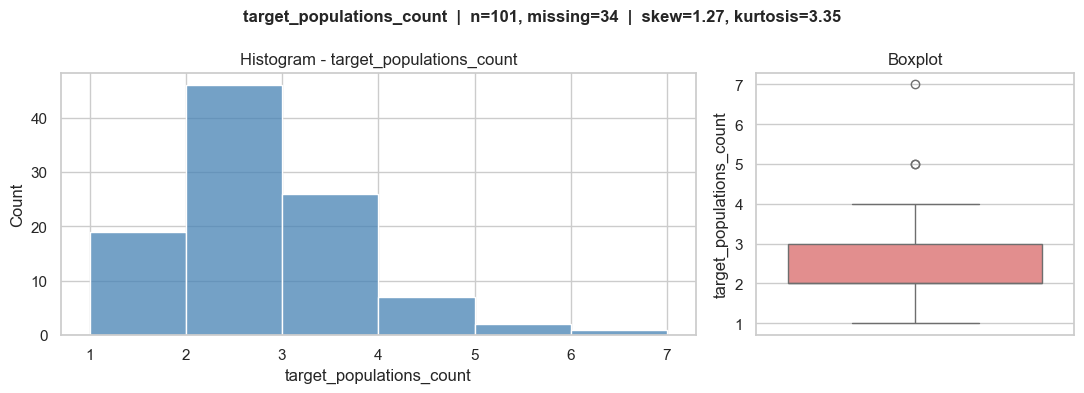

#### `data_waves_count`

,source_file,pi_name,proposal_title,data_waves_count
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,5.0
34,אלט_ועובד_25.txt,"דורית אלט, אורית עובד",פיתוח מדדי SEL-AI: למידה חברתית-רגשית של מורים...,4.0
38,בנטוב_25.txt,Unknown,חיזוק החוסן של תלמידים בגילאי 13-18 באמצעות הת...,4.0
65,עינת_הד_24.txt,פרופ' עינת הד מצויינים,פרקטיקות הוראה היכולות למנוע מעגלי כישלון ולמנ...,4.0
130,כרמל_אלטמן_21.txt,"דר' כרמית אלטמן, דר' איריס הדר",אי שיוויון ופערים ופדגוגיה רלוונטית תרבות,4.0
5,אורלי_ליפקה_25.txt,אורלי ליפקה,בינה מלאכותית יוצרת: מהבנה ליישום במערכת החינו...,3.0
7,אורלי_שפירא_21.txt,אורלי שפירא,הערכת חוסר היציבות במסגרות לגיל הרך על רקע מגי...,3.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,3.0
20,בנטוב25.txt,Unknown,דפוסי שימוש והשפעות בינה מלאכותית יוצרת (במ״י)...,3.0
24,גוי_בנטוב_25.txt,"ד""ר ג'וי בנטוב, פרופ' נוגה כהן, ד""ר דנה לסרי","הערכת קבלת, יישמות, ויעילות התוכנית הבית ספרית...",3.0


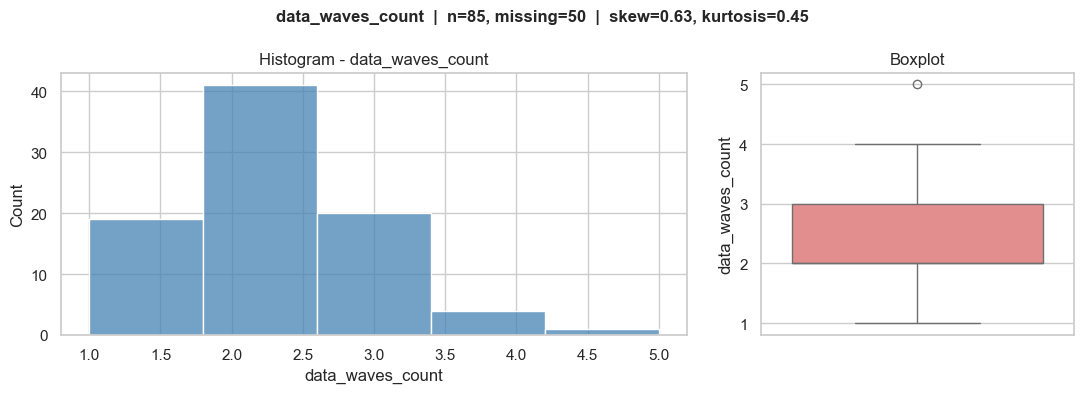

#### `languages_count`

,source_file,pi_name,proposal_title,languages_count
0,אורטל_סלובדין_21.txt,פרופ' אורטל סלובודין,"הארון הכפול: נוער להט""בי במערכת החינוך הערבית ...",3.0
6,אורלי_רובינשטיין_24.txt,"אורלי רובינשטיין, נגה כהן","""לדבר את החשיבה"" אימון תפקודים קוגניטביים גבוה...",3.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,3.0
45,יאסר_עואד_24.txt,פרופ' יאסר עואד,רווחה והתנהגות סיכון בקרב תלמידים בתקופת המשבר...,3.0
92,פאידה_נסר_24.txt,פאדיה נאסר-אבו אלהיג'א,שלומות ורווחה רגשית בקרב צוותי הוראה וניהול בח...,3.0
124,יוסי_פיש_21.txt,פרופ' יוסי הראל-פיש,גורמי חוסן והגנה וגורמי סיכון במרחבים של מערכת...,3.0
1,אורטל_סלובדין_24.txt,"פרופ' אורטל סלובודין, פרופ' הללי פינסון",חסמים באיתור ובהשתתפות תלמידים/ות מהחברה הבדוא...,2.0
2,אורי_כהן_21.txt,אורי כהן,יחסי גומלין בין מנהל החינוך ברשות המקומית לבתי...,2.0
13,איילון_25.txt,Unknown,לילו: סימולציית שיחה מבוססת מודלי שפה גדולים ל...,2.0
15,אימאן_גרה_עלוש_23.txt,"ד""ר אימאן גרה עלוש",שחק אותה: פיתוח אוריינות השפה העברית בקרב תלמי...,2.0


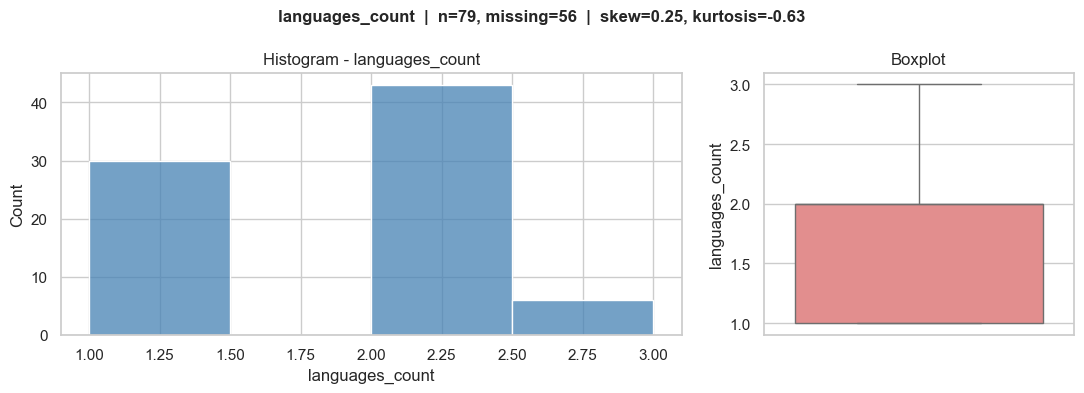

In [11]:
for feature, cfg in CONTINUOUS_PLOT_CONFIG.items():
    display(Markdown(f"#### `{feature}`"))
    display(top_rows(feature, cfg.get("extra_cols", ())))
    plot_continuous(feature, bins=cfg["bins"], kde=cfg.get("kde", False), thousands=cfg.get("thousands", False))

### 4.4.3 Target — `target_budget`

`target_budget` takes suspiciously **round values**, which suggests **fixed, call-defined budget caps** rather than a truly continuous variable. Together with the extreme skew and kurtosis of the unscoped target (4.48 / 19.5 before scoping to ≤1M), this motivates framing the problem as **ordinal classification over a few budget tiers**, not regression. The `value_counts` below confirms it: only a handful of discrete values appear. It has no missing values.

Missing values in target_budget: 0


,count,share
target_budget,,
200000,17,0.126
250000,16,0.119
300000,60,0.444
350000,3,0.022
400000,1,0.007
500000,29,0.215
950000,4,0.030
1000000,5,0.037


,source_file,pi_name,proposal_title,target_budget
44,יאיר_זיו_23.txt,"פרופ' יאיר זיו, פרופ' אסתר עדי יפה",הערכת תכניות להכשרה פדגוגית של מחנכים מטפלים ב...,1000000
77,ניצה_דוידוביץ_23.txt,פרופ' ניצה דוידוביץ',פיתוח קריירה בטיפול בפעוטות במעונות היום: מעיס...,1000000
108,תומס_גומפל_24.txt,פרופ' תומס גומפל,התמקצעות של מורים להוראה בכיתה ההטרוגנית: יישו...,1000000
122,מירי_טל_23.txt,"ד""ר מירי טל סבן",תרומת תהליך ההכשרה הפדגוגי של מחנכות-מטפלות במ...,1000000
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,1000000
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,950000
28,דורית_טובין_25.txt,פרופ' דורית טובין,למידת מורים מקצועית בבית הספר,950000
29,דינה_ציבולסקי_25__2_.txt,דינה ציבולסקי,מחקר מלווה לפיילוט המבוסס על מודל חדש ללמידת מ...,950000
33,איריס_בן_דוד_הדר_25.txt,איריס בן דוד הדר,הערכת השפעת פיילוט הלמידה המקצועית על התפתחות ...,950000
5,אורלי_ליפקה_25.txt,אורלי ליפקה,בינה מלאכותית יוצרת: מהבנה ליישום במערכת החינו...,500000


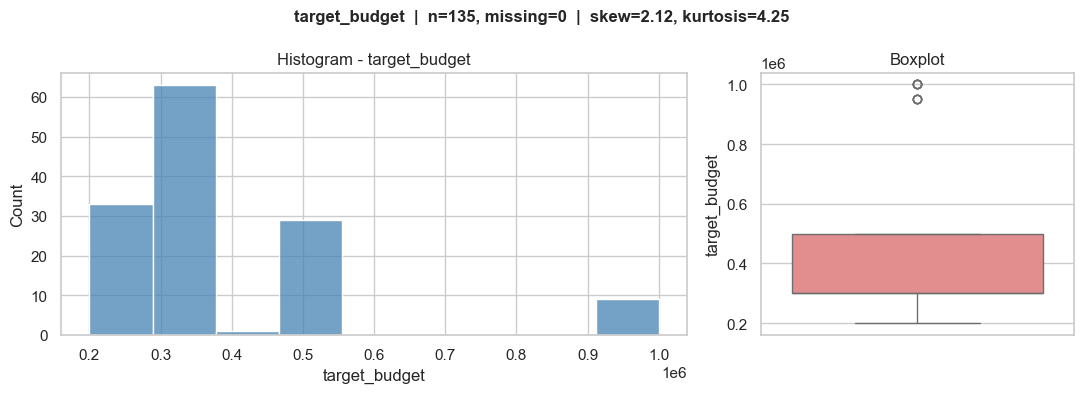

In [12]:
print(f"Missing values in target_budget: {df_clean['target_budget'].isna().sum()}")

target_counts = pd.DataFrame({
    "count": df_clean["target_budget"].value_counts(),
    "share": df_clean["target_budget"].value_counts(normalize=True).round(3),
}).sort_index()
display(target_counts)
display(top_rows("target_budget"))
plot_continuous("target_budget", bins=9)

### 4.4.4 Binary variables

**Cardinality note:** `has_surveys` is near-constant (almost every triangle uses surveys), so it is unlikely to correlate strongly with the target. The table gives the share of "yes" among known values and the number of missing values per flag.

,n_yes,n_no,n_missing,share_yes
has_surveys,113,21,1,0.84
has_external_services,111,24,0,0.82
is_complex_design,94,36,5,0.72
has_interviews,94,40,1,0.70
requires_translation,71,53,11,0.57
is_multidisciplinary,62,49,24,0.56
has_tests,37,96,2,0.28
has_special_equipment,33,102,0,0.24
has_observations,28,105,2,0.21
has_focus_groups,28,105,2,0.21


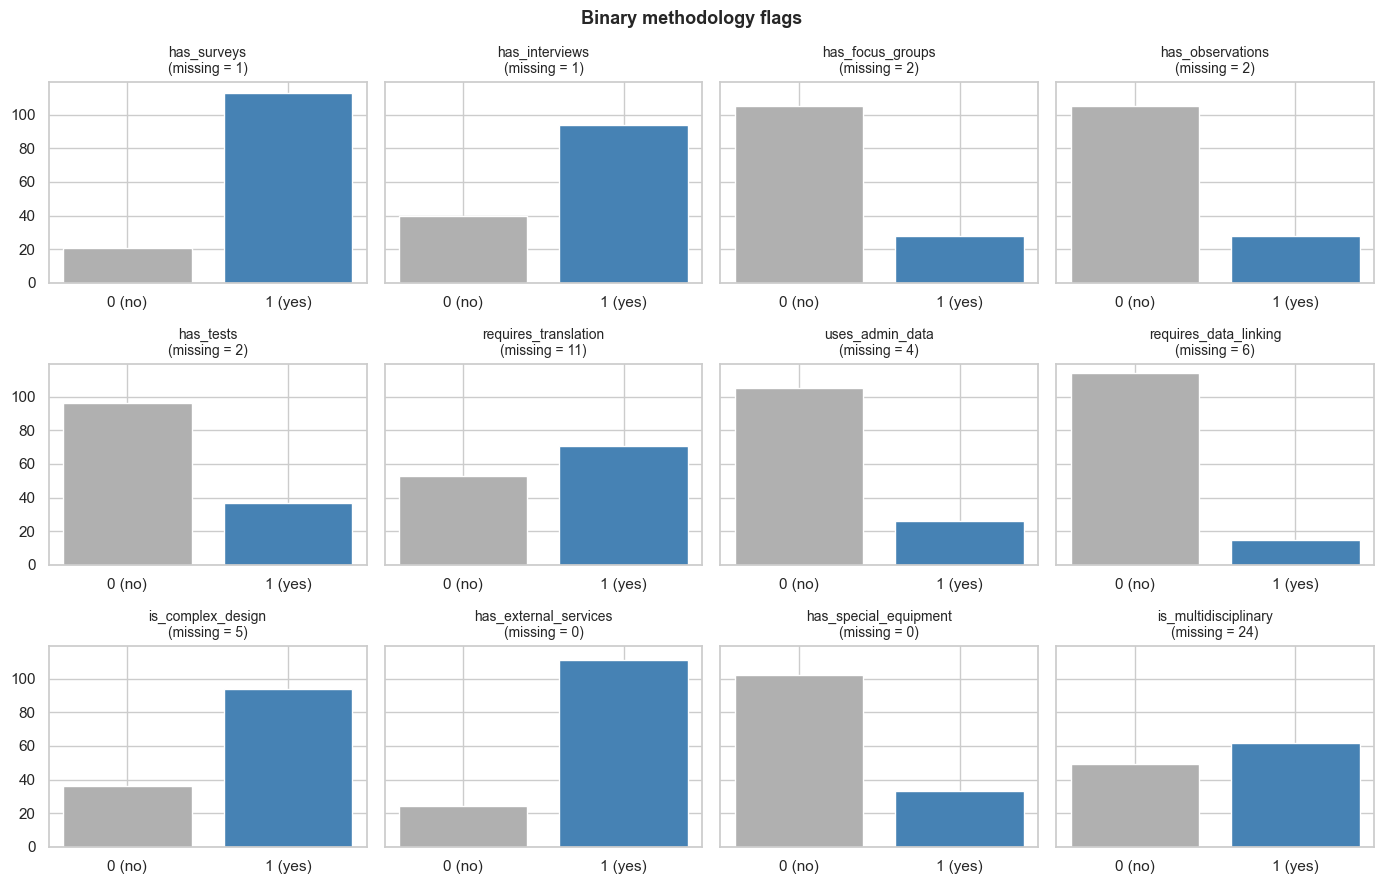

In [13]:
binary_summary = pd.DataFrame({
    "n_yes": df_clean[binary_cols].eq(1).sum(),
    "n_no": df_clean[binary_cols].eq(0).sum(),
    "n_missing": df_clean[binary_cols].isna().sum(),
})
binary_summary["share_yes"] = (binary_summary["n_yes"] / (binary_summary["n_yes"] + binary_summary["n_no"])).round(2)
display(binary_summary.sort_values("share_yes", ascending=False))

fig, axes = plt.subplots(3, 4, figsize=(14, 9), sharey=True)
for ax, col in zip(axes.flat, binary_cols):
    counts = df_clean[col].dropna().astype(int).value_counts().reindex([0, 1], fill_value=0)
    ax.bar(["0 (no)", "1 (yes)"], counts.values, color=["#b0b0b0", "steelblue"])
    ax.set_title(f"{col}\n(missing = {df_clean[col].isna().sum()})", fontsize=10)
fig.suptitle("Binary methodology flags", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.4.5 Categorical variables

Missing values: {'collection_mode': 0, 'tool_development_type': 0, 'deliverables_level': 0}


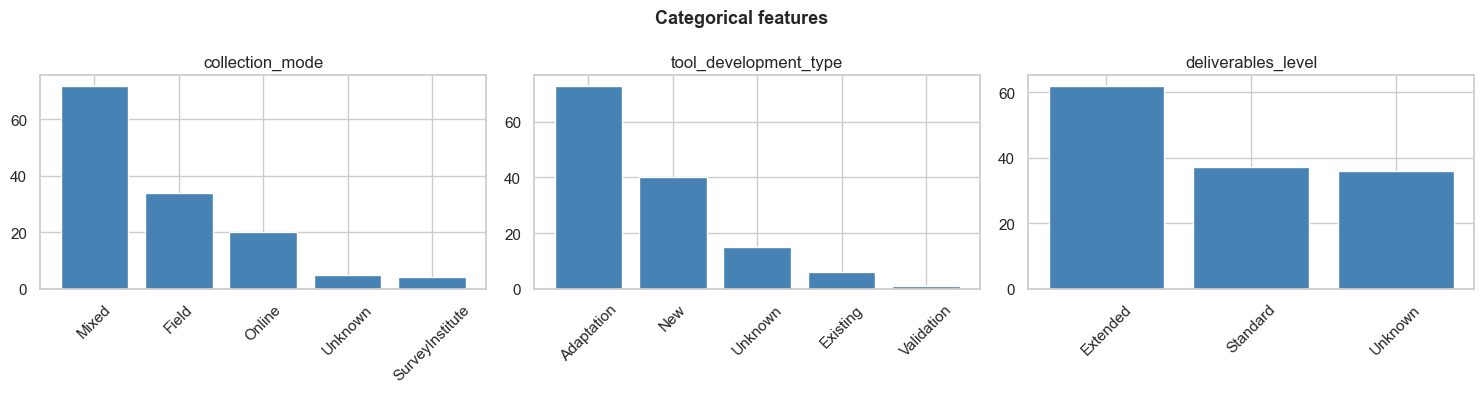

count
collection_mode       Mixed               72
                      Field               34
                      Online              20
                      Unknown              5
                      SurveyInstitute      4
tool_development_type Adaptation          73
                      New                 40
                      Unknown             15
                      Existing             6
                      Validation           1
deliverables_level    Extended            62
                      Standard            37
                      Unknown             36

In [14]:
print("Missing values:", df_clean[categorical_cols].isna().sum().to_dict())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, categorical_cols):
    counts = df_clean[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color="steelblue")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Categorical features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

pd.concat({col: df_clean[col].value_counts() for col in categorical_cols}).to_frame("count")

<a id="eda-correlation"></a>
## 4.5 Correlation analysis (before binning)

**Pearson** measures linear association and **Spearman** measures monotonic association. Both are computed for the continuous features, for the binary flags, and across all numeric columns.

In [15]:
def corr_heatmap(matrix, title):
    """Diverging heatmap of a correlation matrix (red = positive, blue = negative)."""
    long = matrix.reset_index().melt(id_vars="index")
    long.columns = ["feature_1", "feature_2", "correlation"]
    return (
        pln.ggplot(long, pln.aes("feature_1", "feature_2", fill="correlation"))
        + pln.geom_tile()
        + pln.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0, limits=(-1, 1))
        + pln.theme(axis_text_x=pln.element_text(rotation=90, hjust=1), figure_size=(9, 8))
        + pln.labs(title=title)
    )

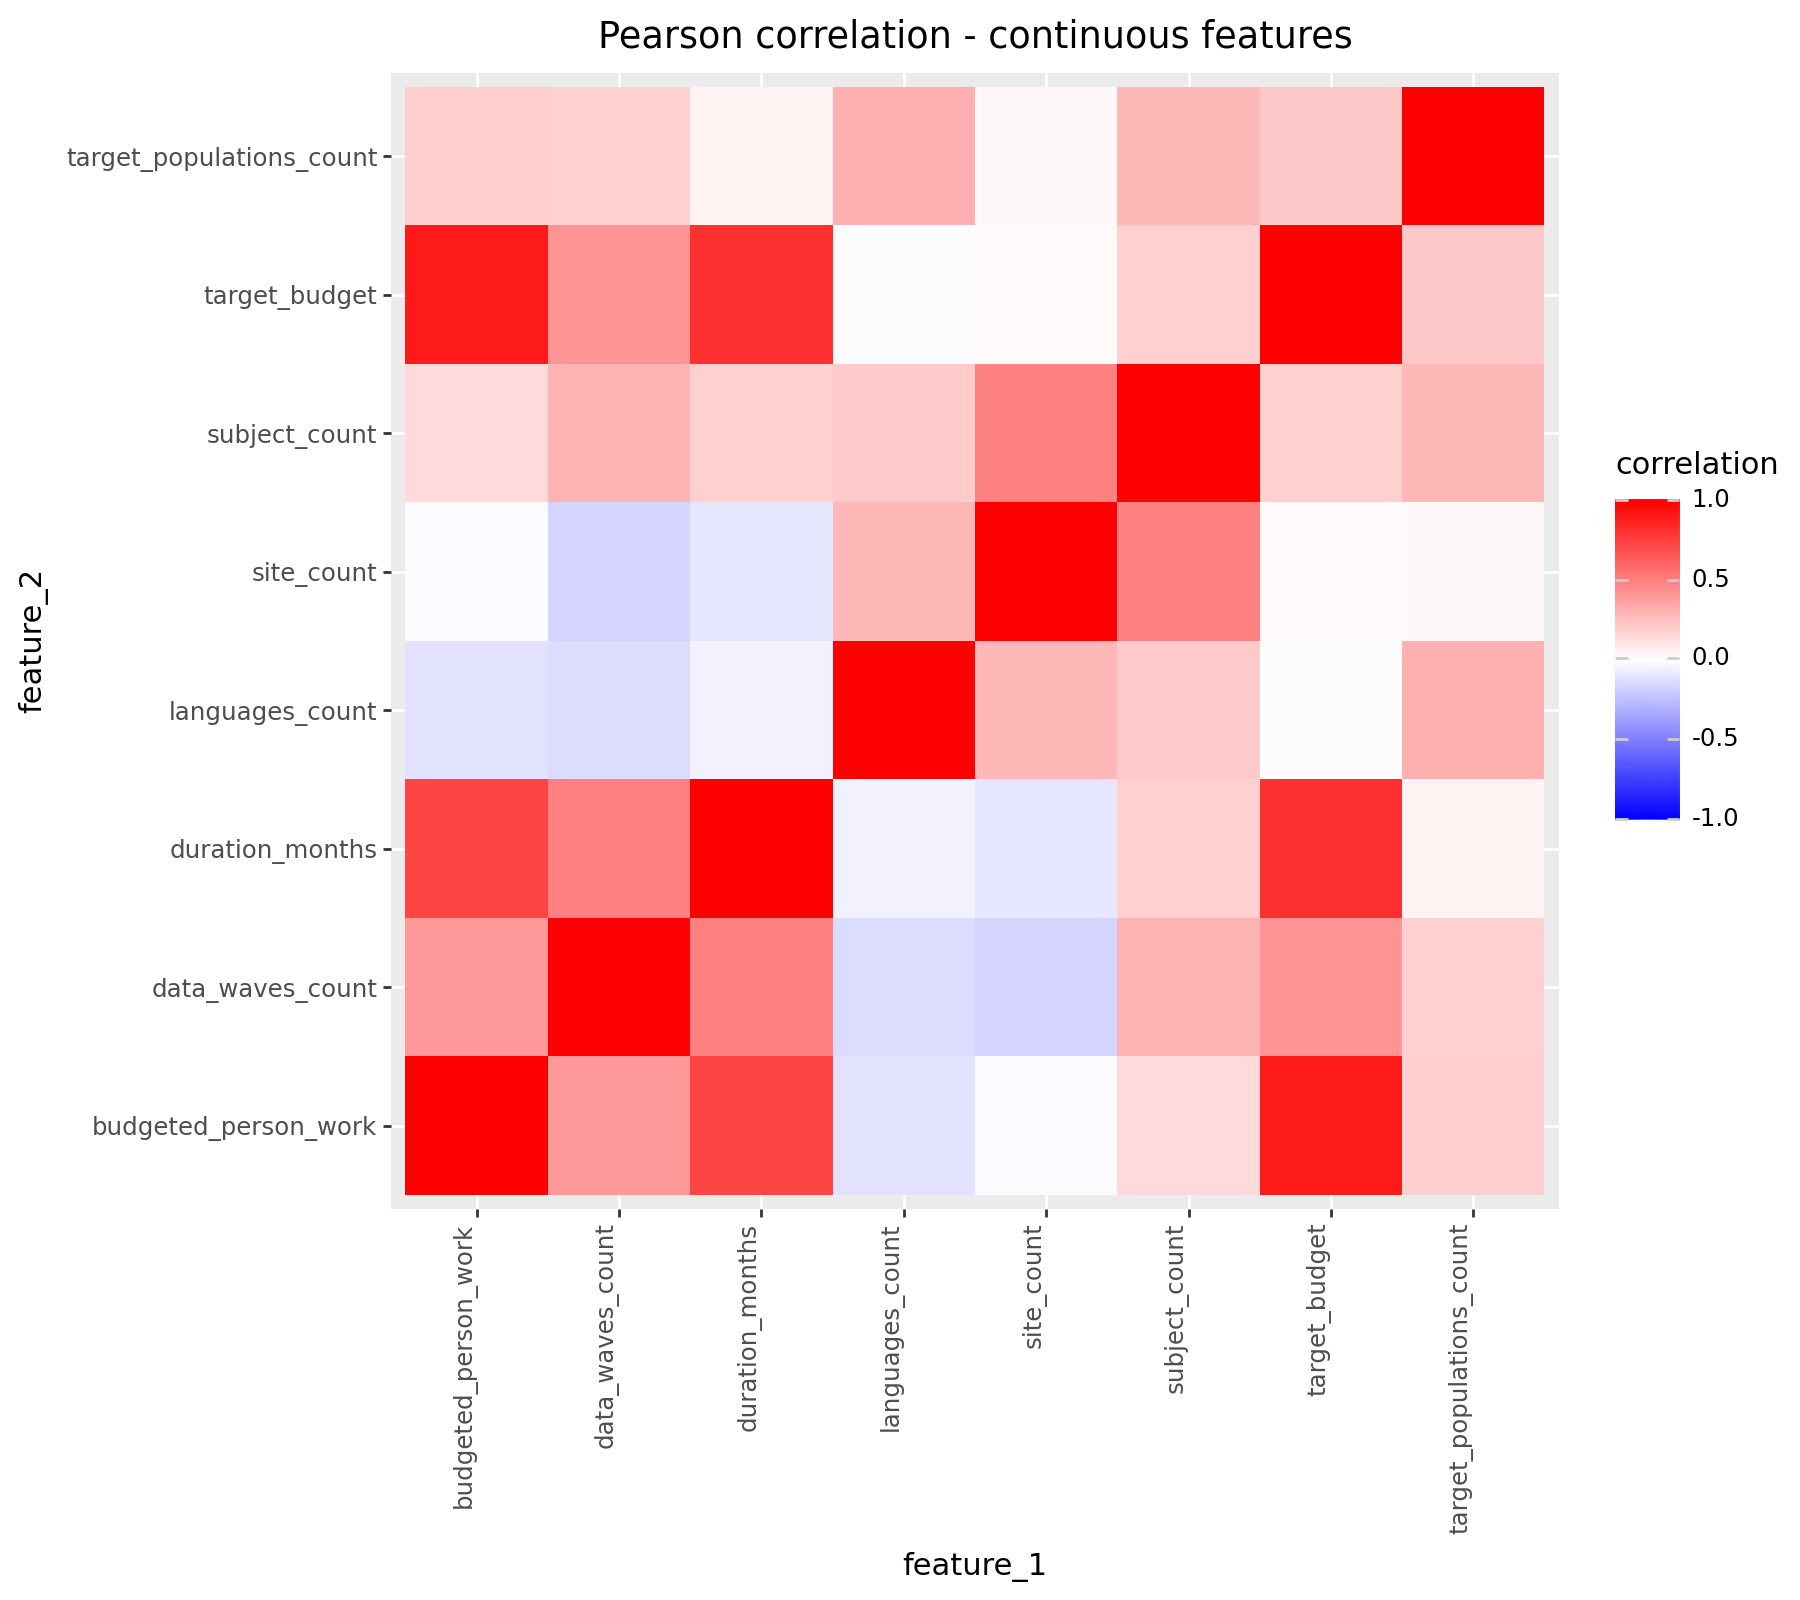

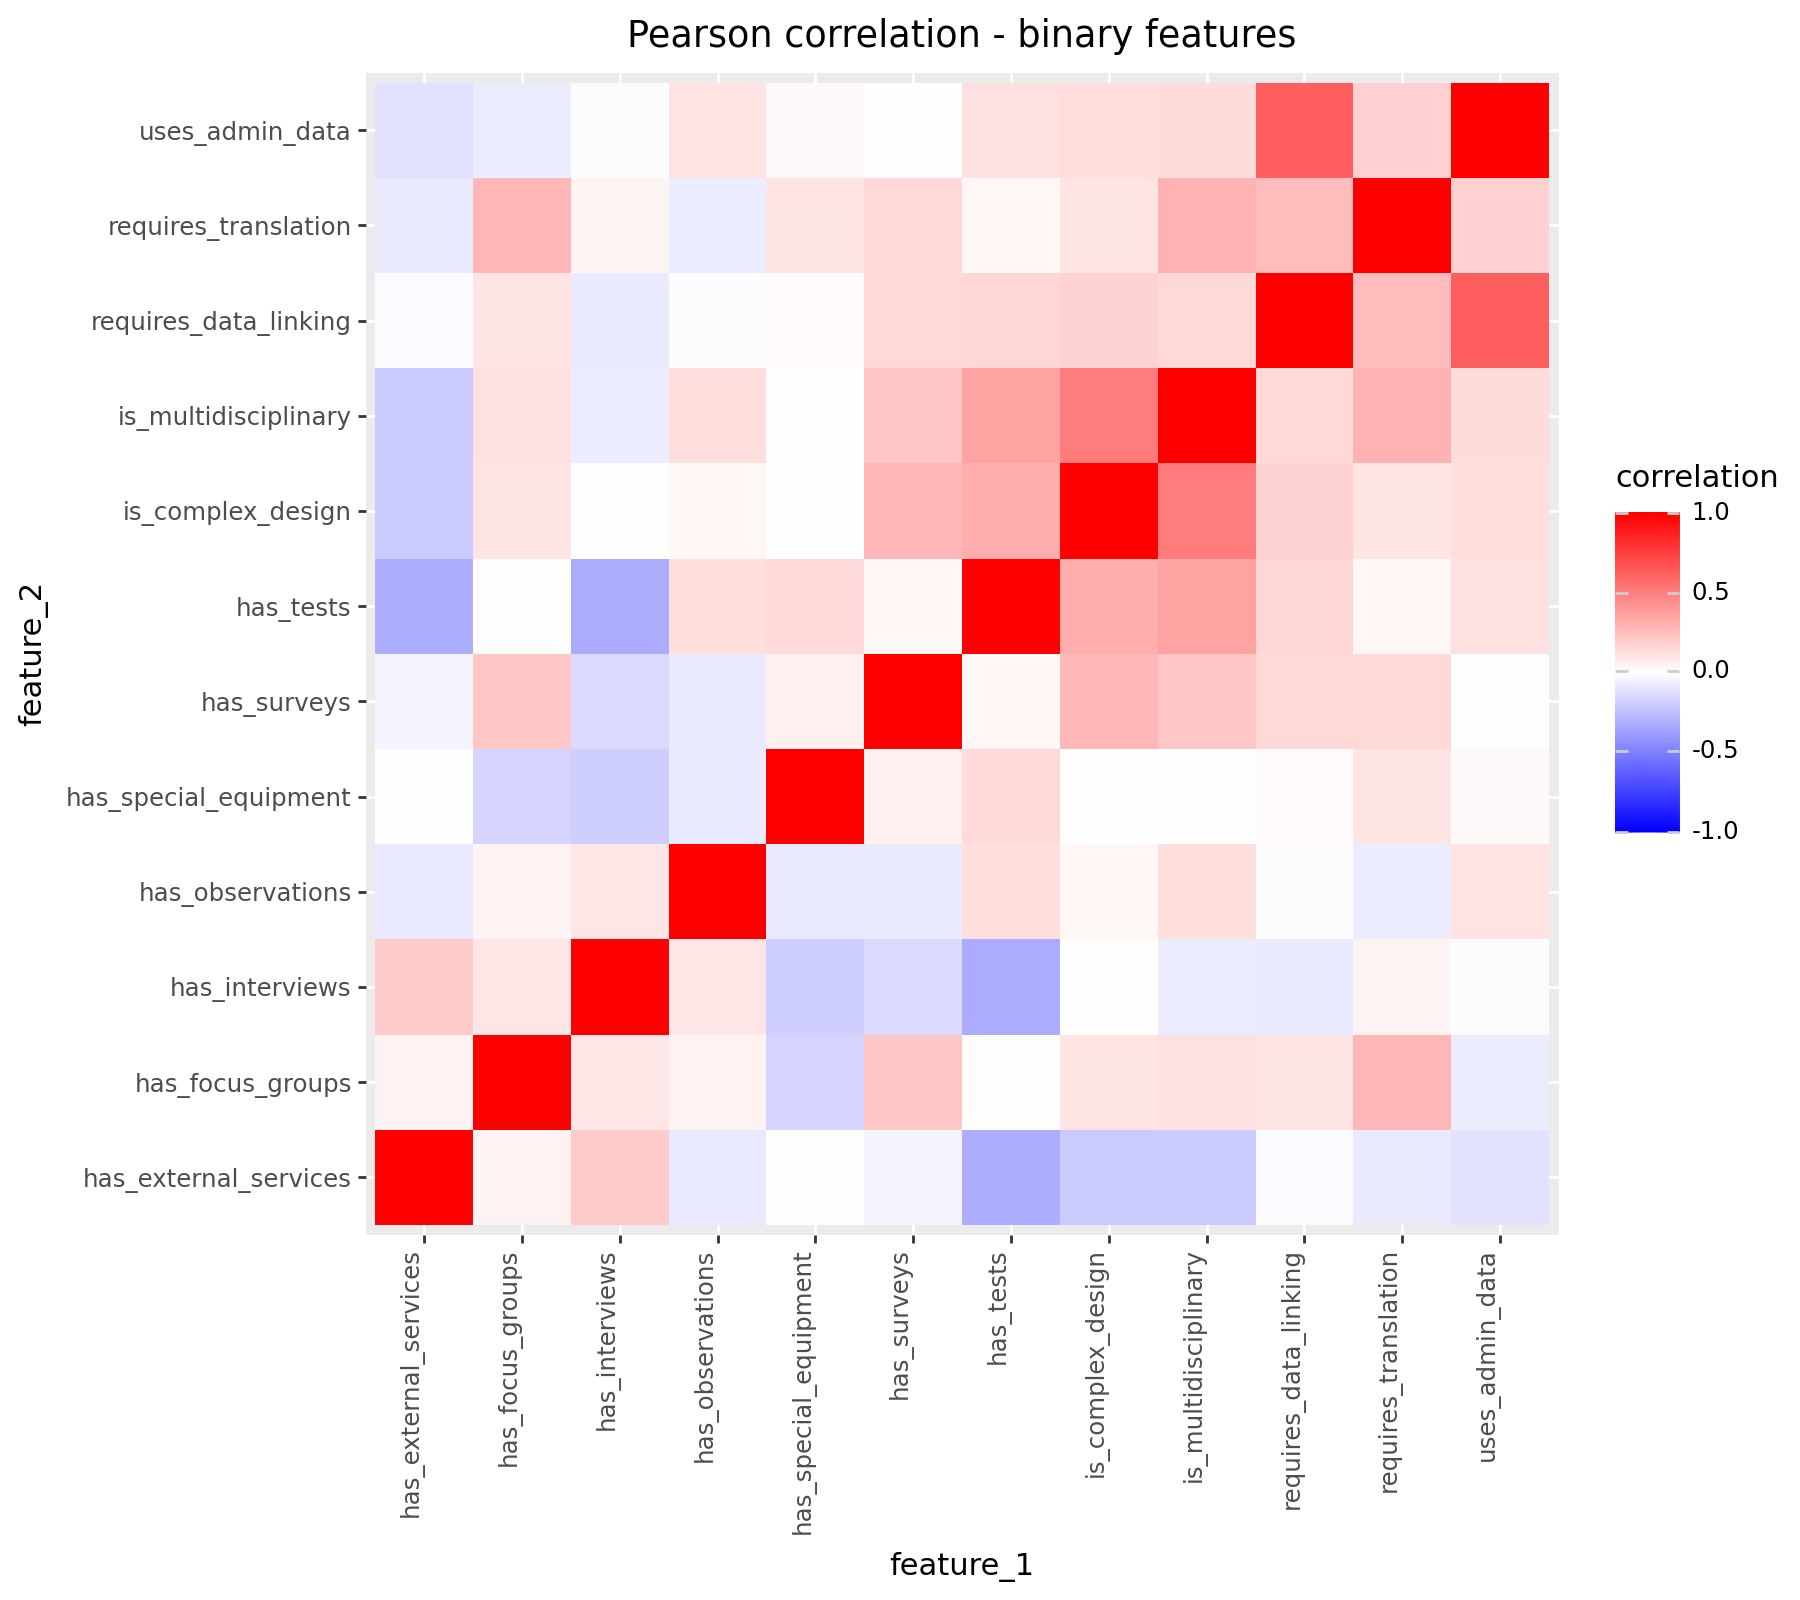

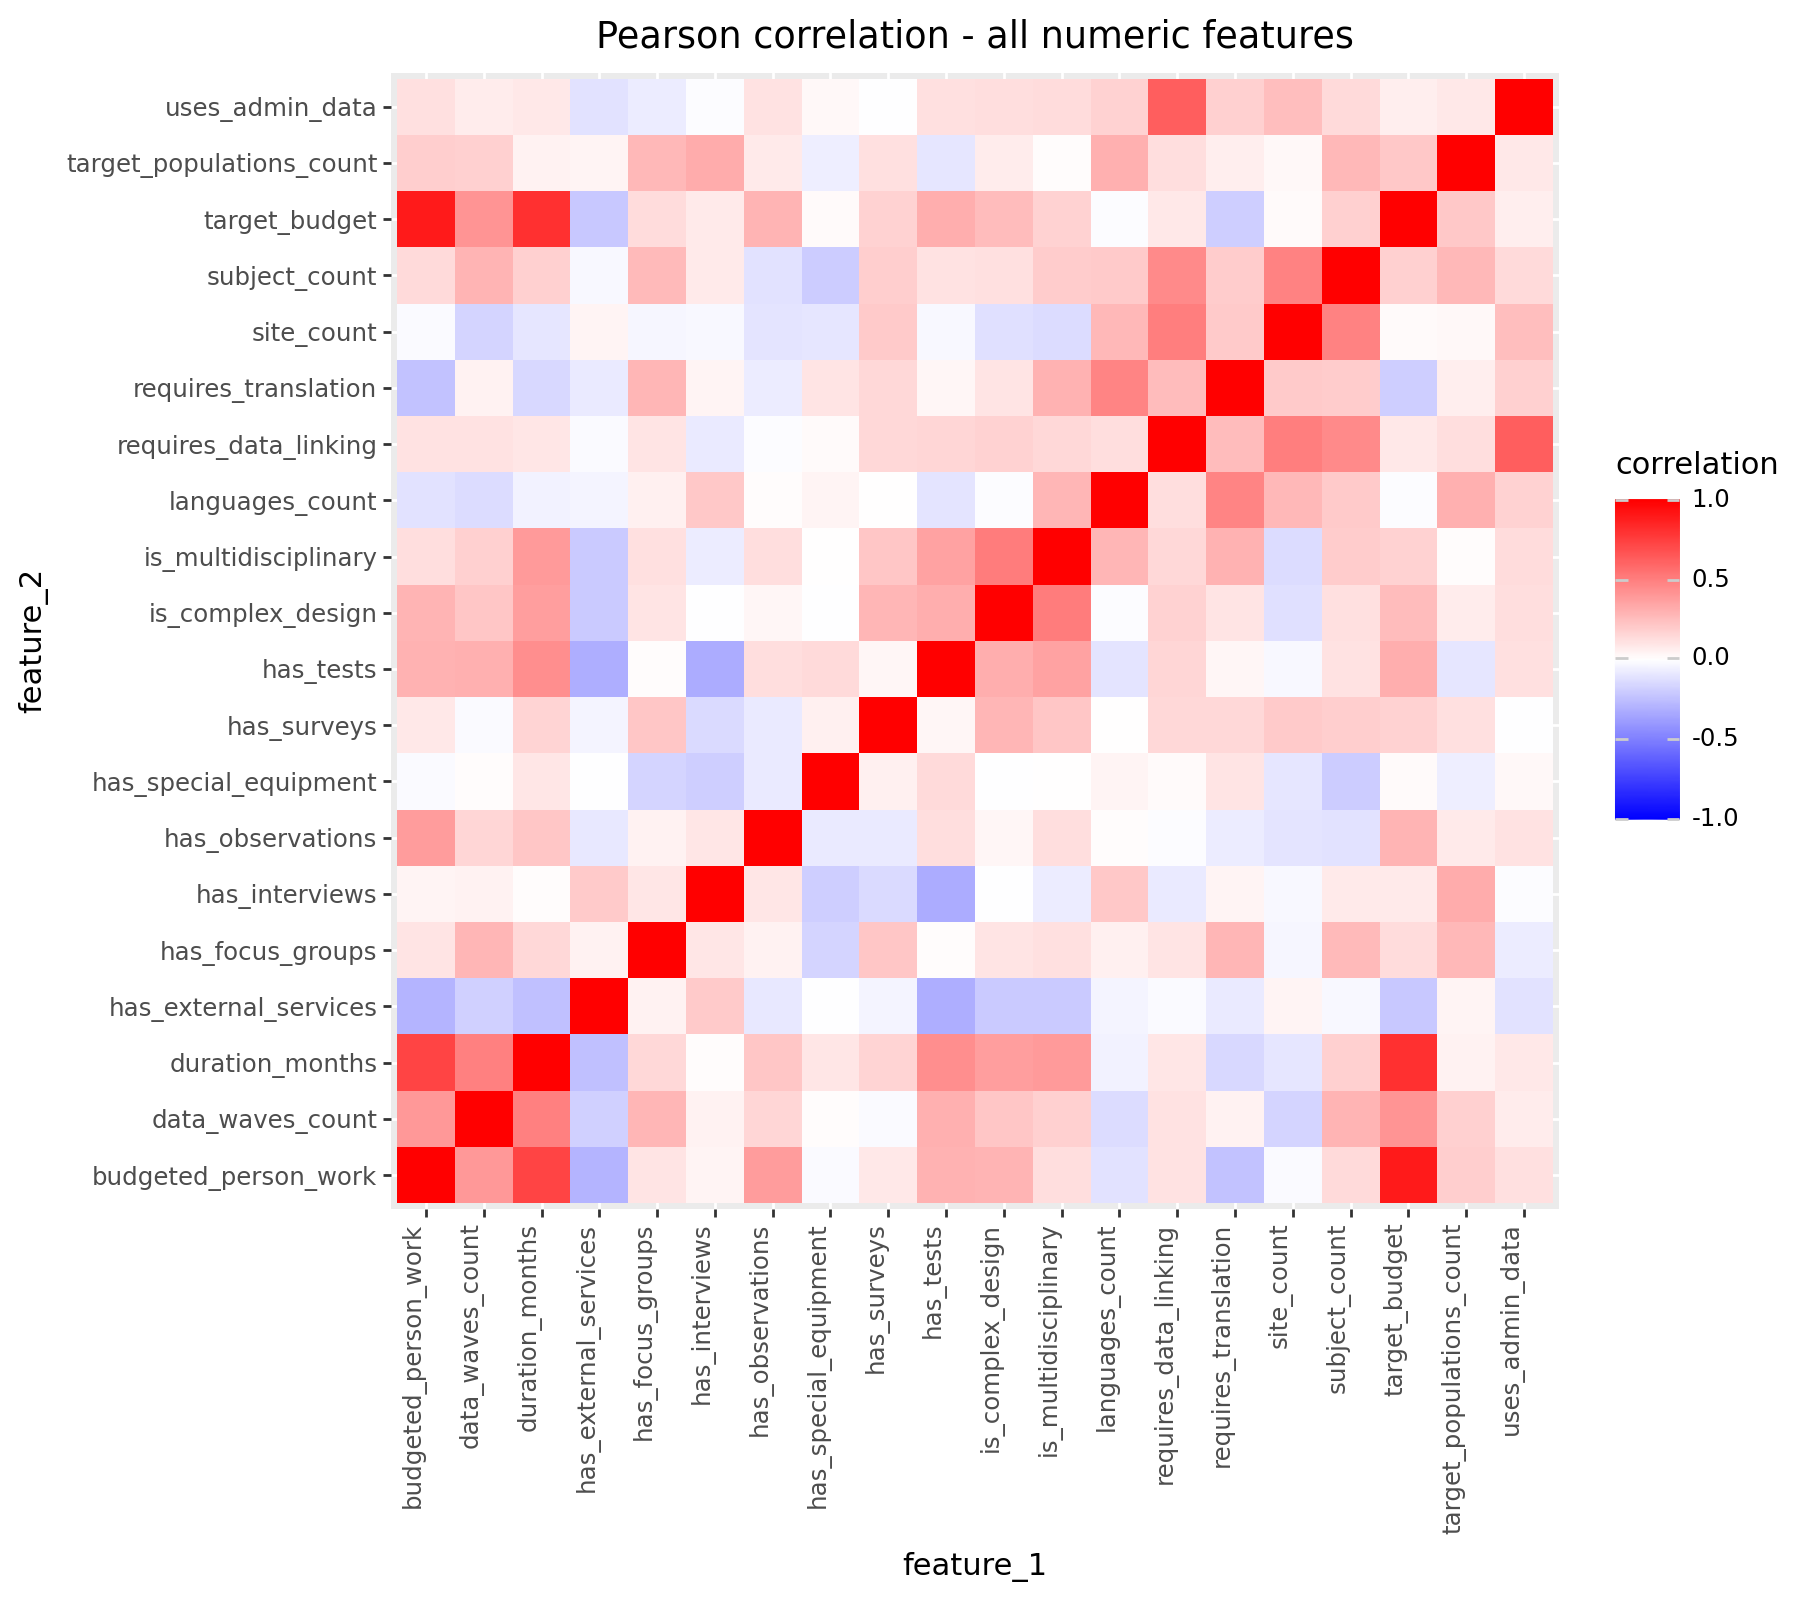

In [16]:
# --- Pearson (linear) ---
linear_corr_continuous = df_clean[continuous_cols].corr(method="pearson")
linear_corr_binary = df_clean[binary_cols].corr(method="pearson")
linear_corr_cross = df_clean[numeric_cols].corr(method="pearson")

display(corr_heatmap(linear_corr_continuous, "Pearson correlation - continuous features"))
display(corr_heatmap(linear_corr_binary, "Pearson correlation - binary features"))
display(corr_heatmap(linear_corr_cross, "Pearson correlation - all numeric features"))

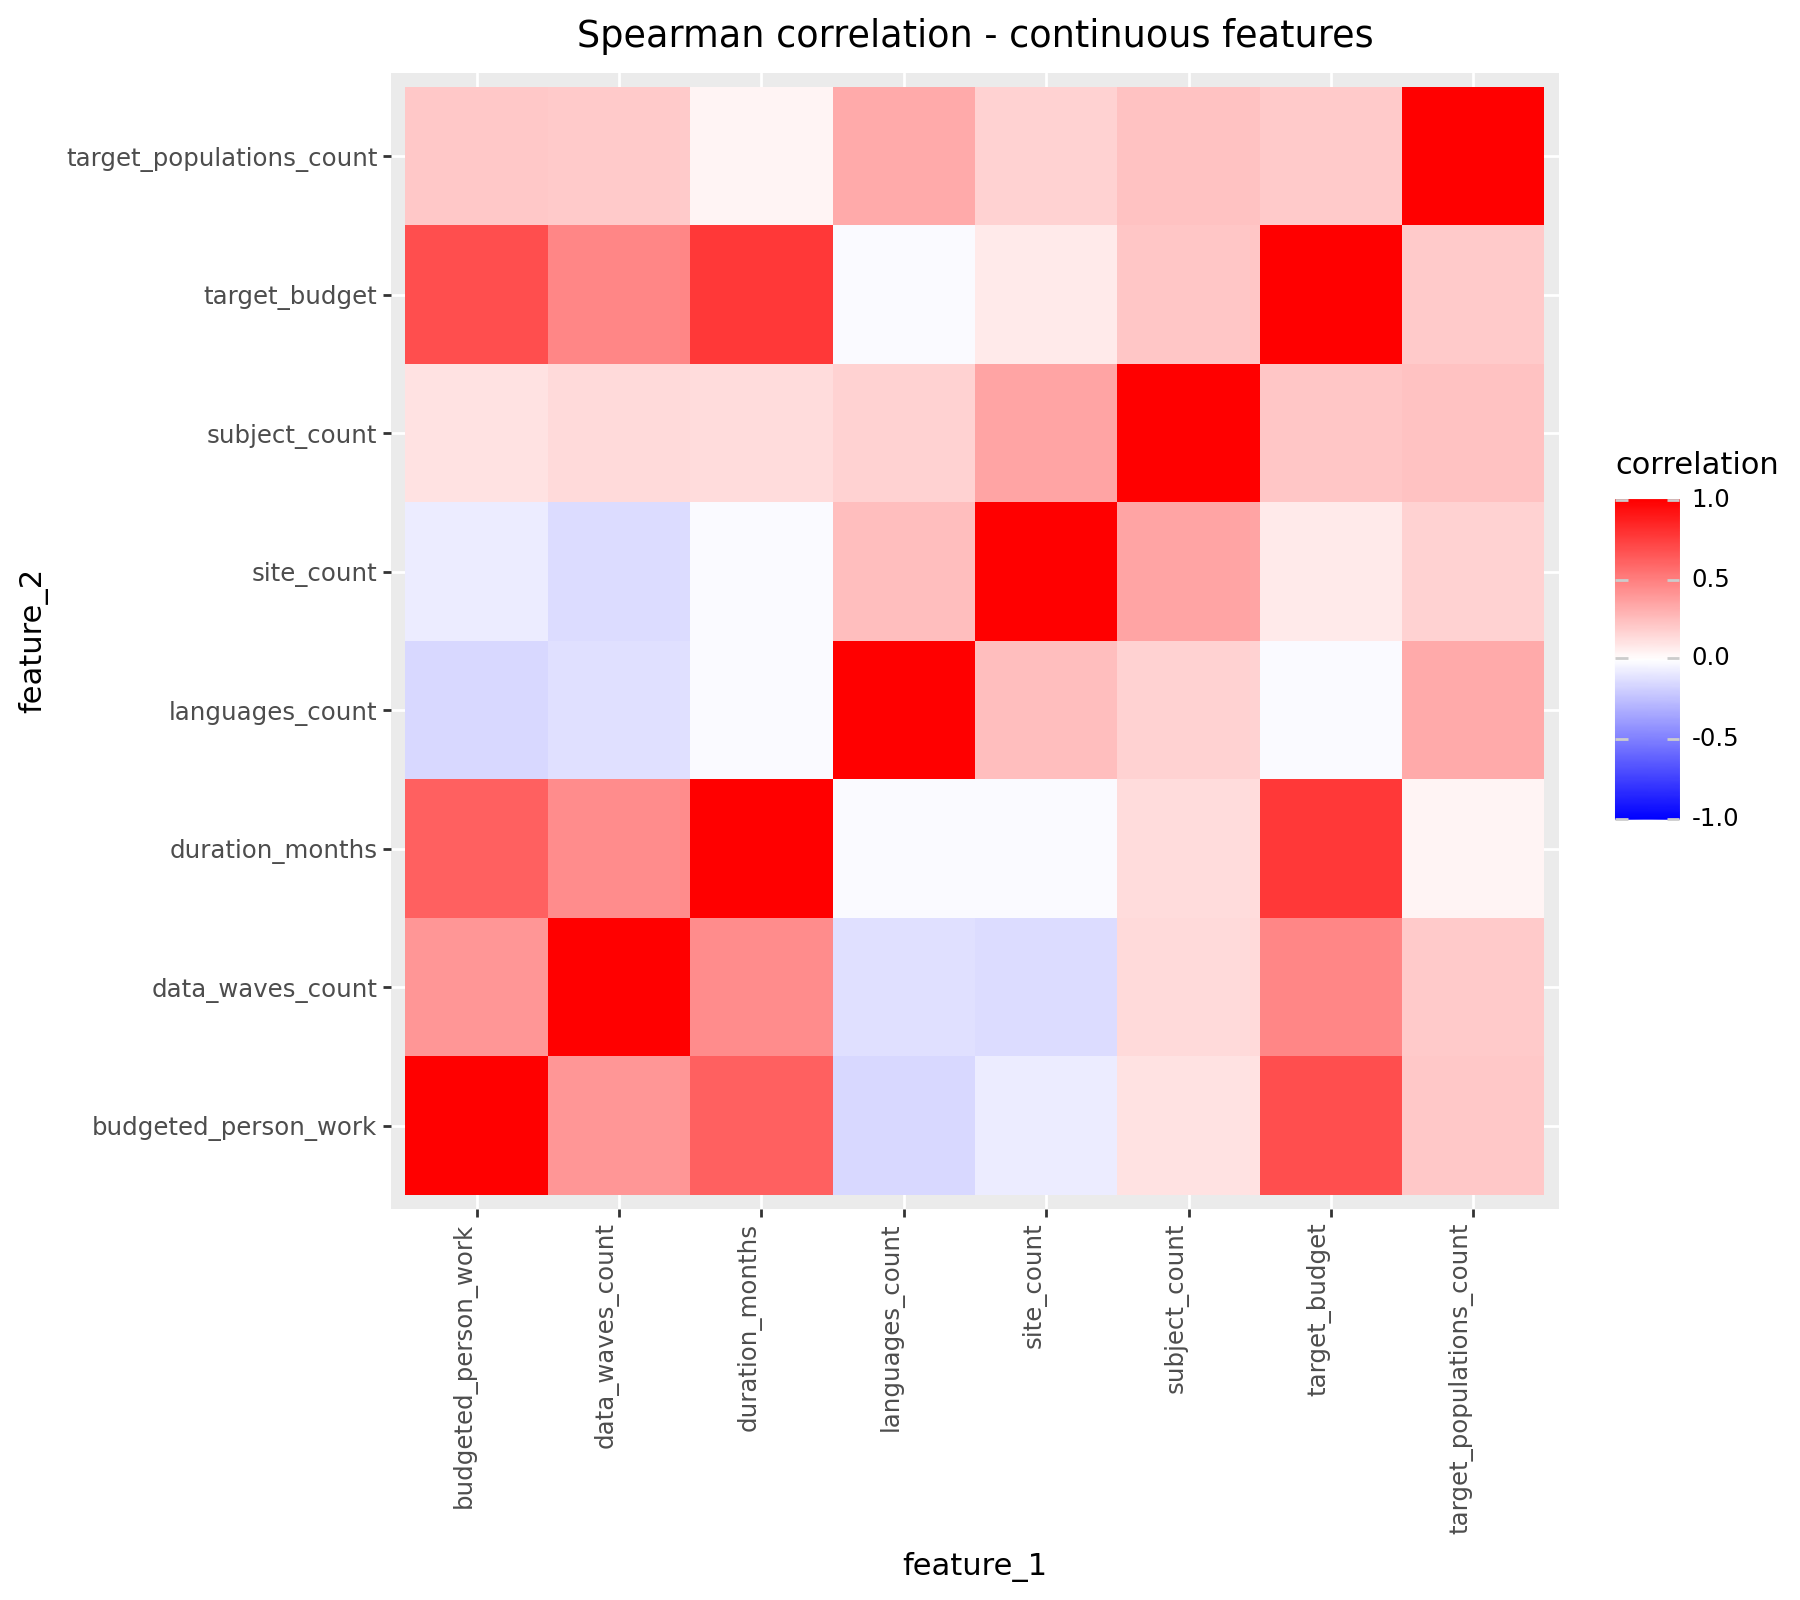

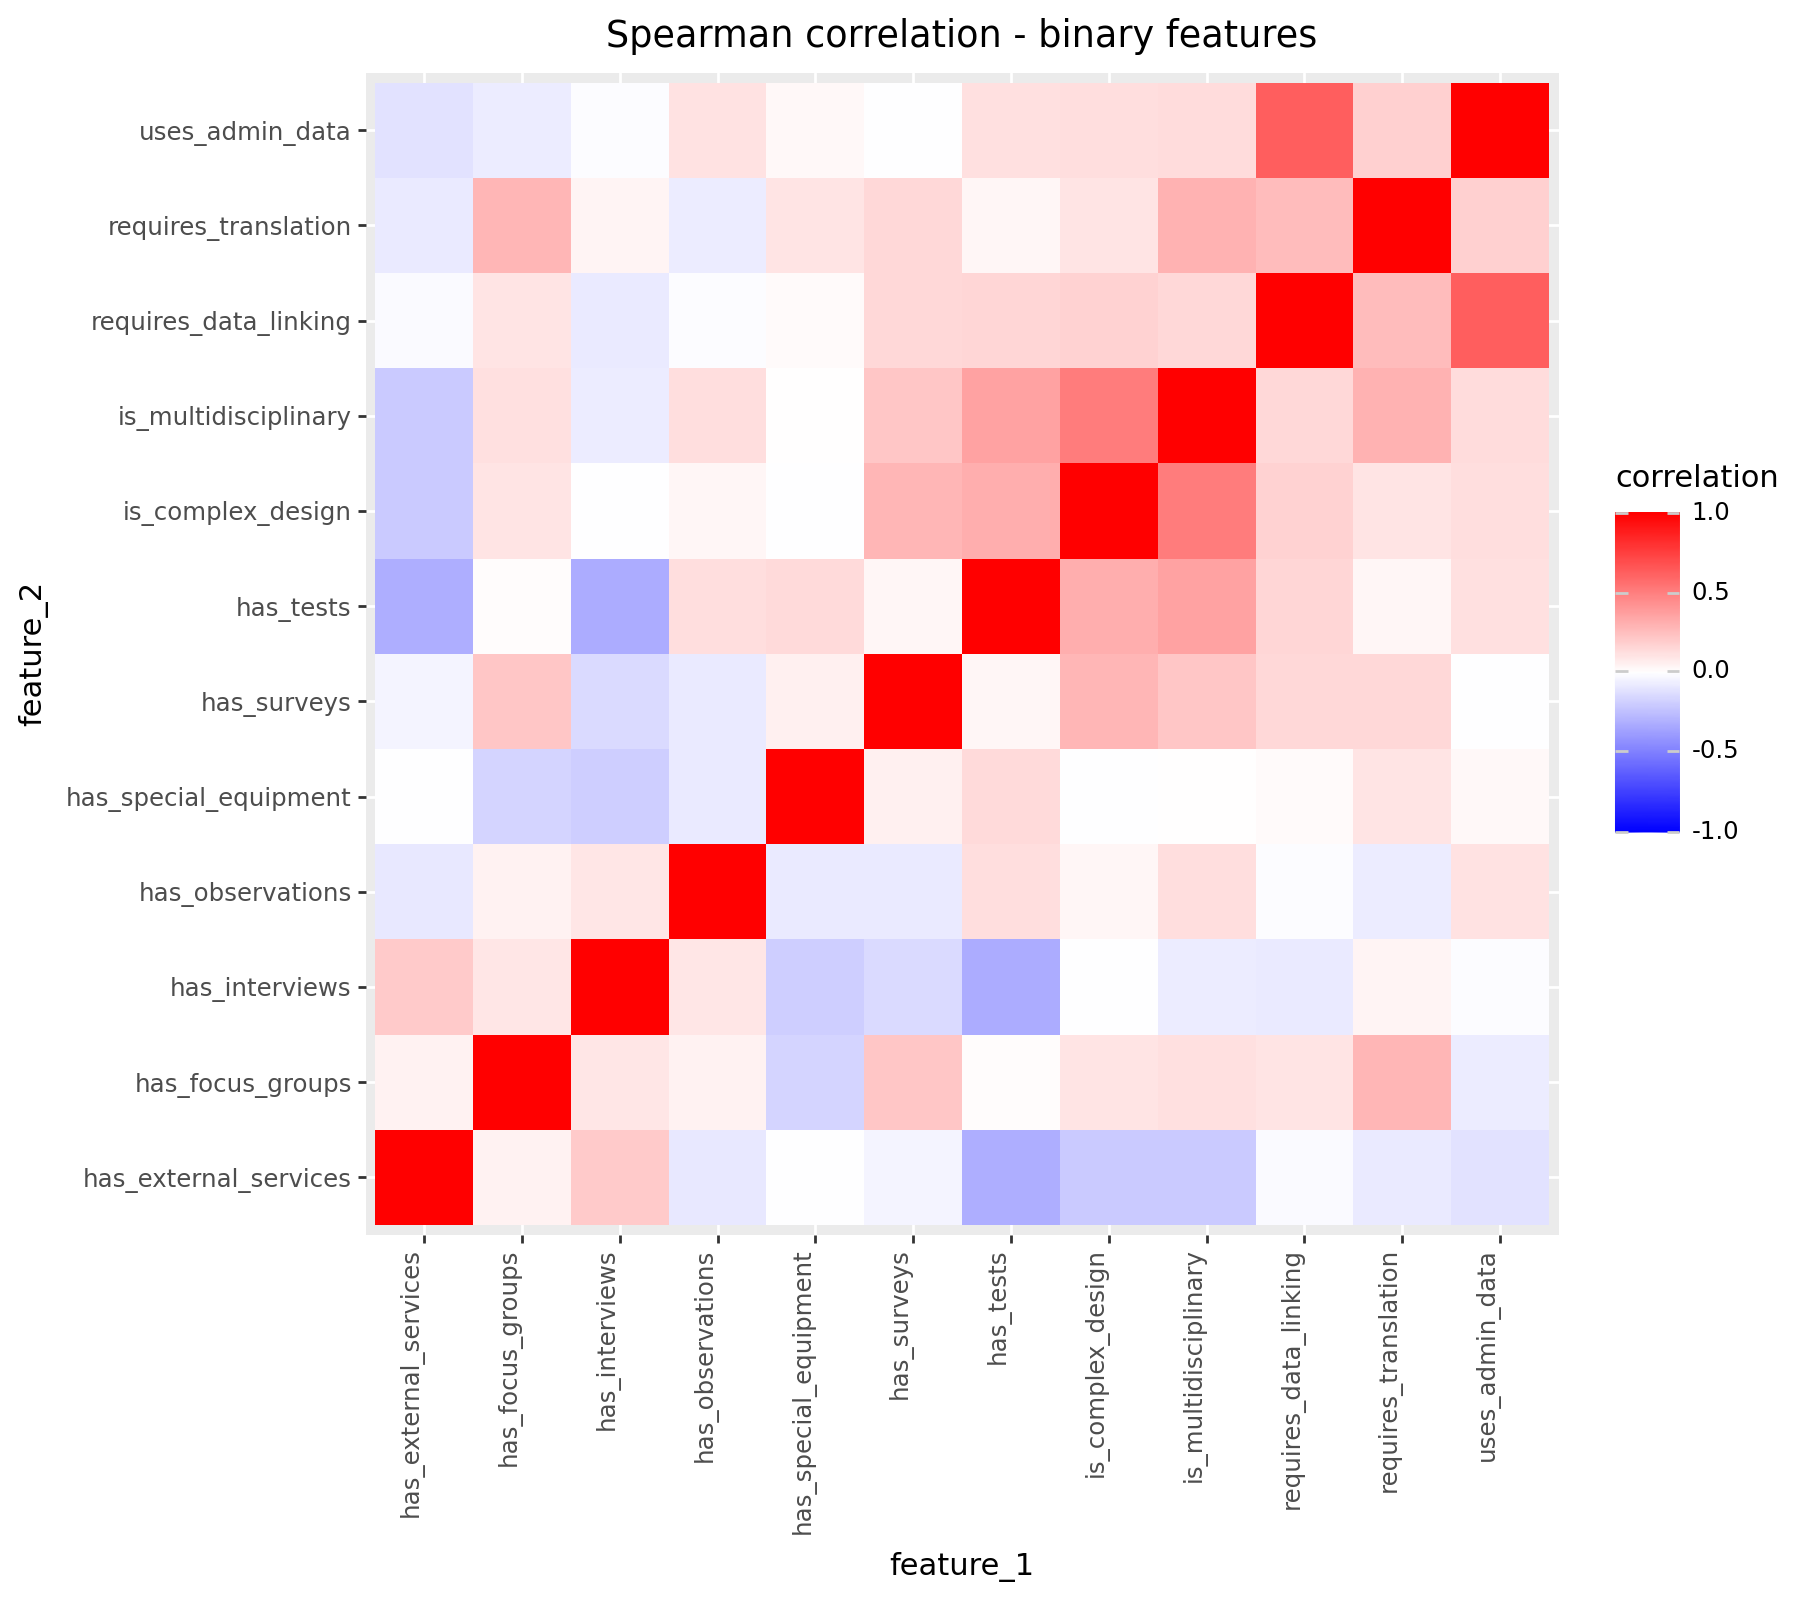

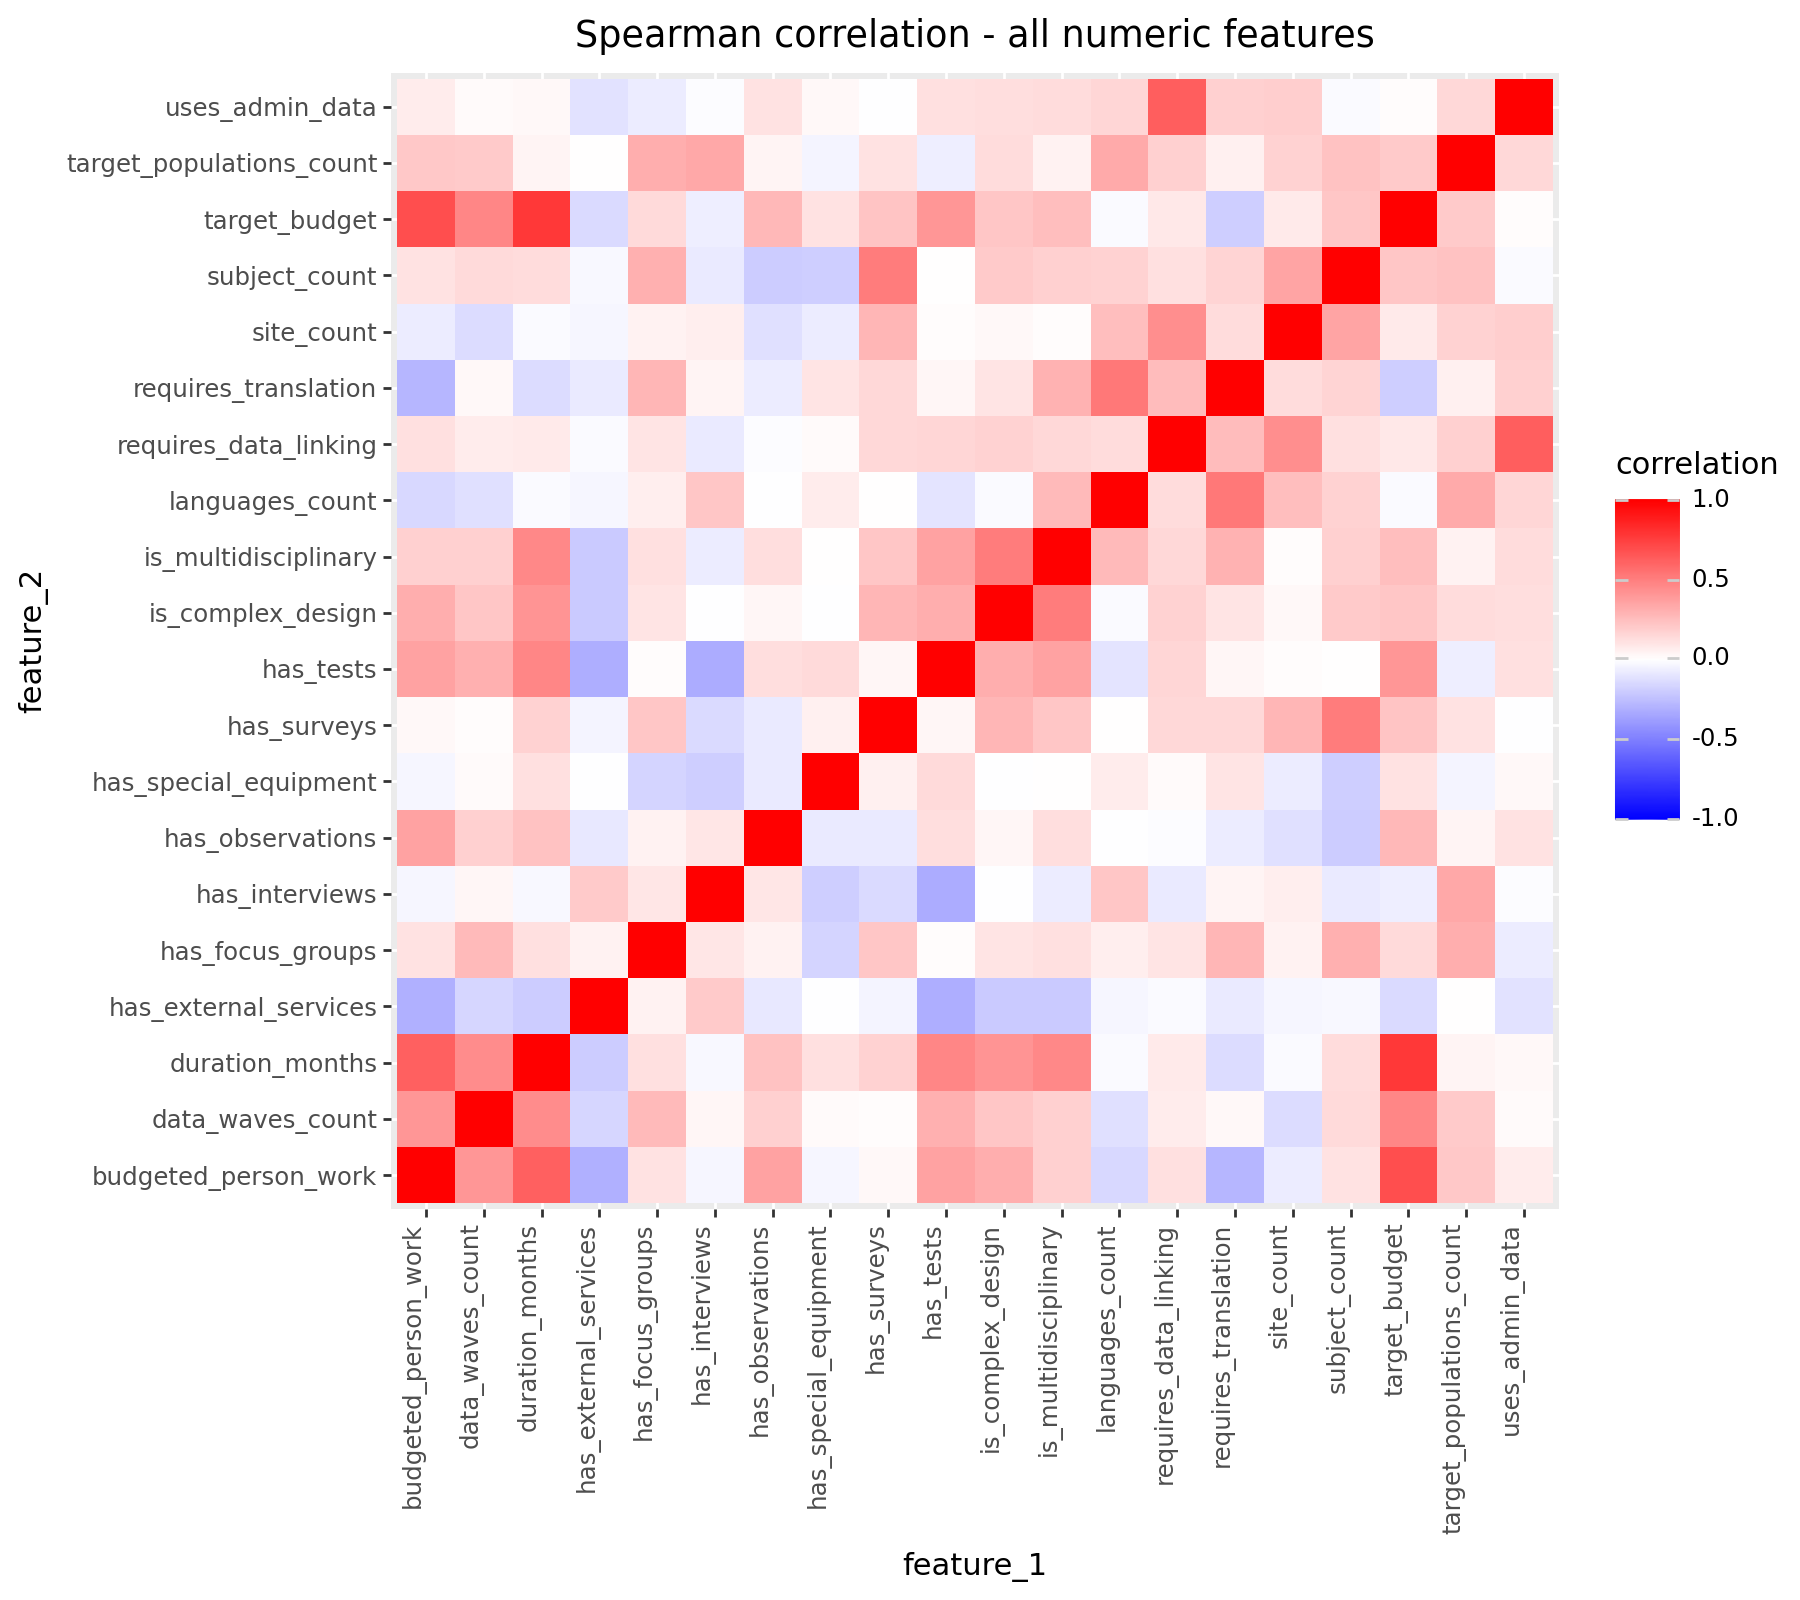

In [17]:
# --- Spearman (monotonic) ---
mono_corr_continuous = df_clean[continuous_cols].corr(method="spearman")
mono_corr_binary = df_clean[binary_cols].corr(method="spearman")
mono_corr_cross = df_clean[numeric_cols].corr(method="spearman")

display(corr_heatmap(mono_corr_continuous, "Spearman correlation - continuous features"))
display(corr_heatmap(mono_corr_binary, "Spearman correlation - binary features"))
display(corr_heatmap(mono_corr_cross, "Spearman correlation - all numeric features"))

In [18]:
def build_correlation_table(frame, cols):
    """One row per unique column pair, keeping whichever of Pearson/Spearman is stronger in absolute value."""
    pearson = frame[cols].corr(method="pearson")
    spearman = frame[cols].corr(method="spearman")

    rows = []
    for i, c1 in enumerate(cols):
        for c2 in cols[i + 1:]:                     # pairs after c1 only: no (A,B)/(B,A) duplicates, no A vs A
            p, s = pearson.loc[c1, c2], spearman.loc[c1, c2]
            if pd.isna(p) and pd.isna(s):
                continue                            # undefined for this pair (e.g. no overlapping data)
            p_abs = abs(p) if pd.notna(p) else -1
            s_abs = abs(s) if pd.notna(s) else -1
            if p_abs >= s_abs:
                relationship, strength = "Linear (Pearson)", p
            else:
                relationship, strength = "Monotonic (Spearman)", s
            rows.append({"var1": c1, "var2": c2, "relationship": relationship, "strength": round(strength, 3)})

    result = pd.DataFrame(rows)
    result = result.reindex(result["strength"].abs().sort_values(ascending=False).index)
    return result.reset_index(drop=True)


full_corr_table = build_correlation_table(df_clean, numeric_cols)

# Table 1: the 20 strongest relationships in the whole dataset
top20_overall = full_corr_table.head(20)

# Table 2: the 10 strongest relationships involving the target (target always shown in var1)
target_col = "target_budget"
target_table = full_corr_table[(full_corr_table["var1"] == target_col) | (full_corr_table["var2"] == target_col)].copy()
swap = target_table["var2"] == target_col
target_table.loc[swap, ["var1", "var2"]] = target_table.loc[swap, ["var2", "var1"]].values
top10_target = target_table.head(10).reset_index(drop=True)

display(top20_overall)
display(top10_target)

,var1,var2,relationship,strength
0,budgeted_person_work,target_budget,Linear (Pearson),0.900
1,duration_months,target_budget,Linear (Pearson),0.810
2,duration_months,budgeted_person_work,Linear (Pearson),0.736
3,uses_admin_data,requires_data_linking,Linear (Pearson),0.634
4,languages_count,requires_translation,Monotonic (Spearman),0.531
5,is_complex_design,is_multidisciplinary,Linear (Pearson),0.516
6,subject_count,has_surveys,Monotonic (Spearman),0.512
7,site_count,requires_data_linking,Linear (Pearson),0.505
8,duration_months,data_waves_count,Linear (Pearson),0.500
9,site_count,subject_count,Linear (Pearson),0.489


,var1,var2,relationship,strength
0,target_budget,budgeted_person_work,Linear (Pearson),0.900
1,target_budget,duration_months,Linear (Pearson),0.810
2,target_budget,data_waves_count,Monotonic (Spearman),0.476
3,target_budget,has_tests,Monotonic (Spearman),0.411
4,target_budget,has_observations,Linear (Pearson),0.292
5,target_budget,is_complex_design,Linear (Pearson),0.264
6,target_budget,is_multidisciplinary,Monotonic (Spearman),0.253
7,target_budget,has_surveys,Monotonic (Spearman),0.228
8,target_budget,subject_count,Monotonic (Spearman),0.226
9,target_budget,target_populations_count,Linear (Pearson),0.214


### Insights

- **`budgeted_person_work`** is the strongest correlate of the target (≈0.9). This is **leakage**: it is a sub-total of the same budget document. It is excluded (see §4.4.2).
- **`duration_months`** is the strongest *legitimate* correlate (≈0.8, linear), far ahead of every other feature. It is the backbone of any model here.
- **`data_waves_count`** and **`has_tests`** follow at a moderate, mostly monotonic level (≈0.4–0.5). Both are themselves correlated with duration, so part of their signal is shared.
- The remaining methodology flags and counts are weak (≈0.2–0.3) when considered alone.
- The computed tables above are authoritative. The feature-exclusion decisions are consolidated after the binned association screening in [§5.2](#fe-cramers).

<a id="feature-engineering"></a>
# 5. Feature Engineering

<a id="fe-binning"></a>
## 5.1 Input-range binning (UX + model robustness)

For the end-user tool, exact continuous values (*"how many subjects exactly?"*) are unrealistic to ask at the ideation stage. The continuous inputs are therefore converted into a small number of **user-friendly ranges**, plus an explicit **"Not yet decided"** bin. Bin edges follow a log / domain scale per feature (given the skew measured in §4.4) rather than equal width, to keep bins populated. **Critical:** the same bin edges used for training must be reused as the UI's selectable ranges, to avoid train/serve mismatch.

| Feature | Distribution | Implemented bins |
|---|---|---|
| `duration_months` | skew 1.32, MAD 0: clusters on conventional lengths (min 16, median 18, max 60) | ≤18 · >18 months |
| `site_count` | skew 3.63, ~53% missing, spans orders of magnitude | 1–10 · 11–50 · >50 sites |
| `subject_count` | skew 4.37 (most skewed), ~25% missing | ≤100 · 101–500 · 501–2,000 · >2,000 |
| `target_populations_count` | small tight range (1–7) | 1 · 2 · 3+ |
| `data_waves_count` | small tight range (1–5), ~37% missing | 1 · 2 · 3+ |
| `languages_count` | narrow range (1–3), ~40% missing | 1 · 2 · 3+ |

Every input feature also gets a **`Not yet decided`** bin (the last category) instead of mean/median imputation. For the three most-missing features (`site_count`, `data_waves_count`, `languages_count`), this bin is what lets them stay in training without imputation bias, *provided* the NotebookLM audit (§4.2) confirms the missingness is genuine.

**Target tiers.** `value_counts()` confirms the target is **fully discrete**: only 8 unique values (200k, 250k, 300k, 350k, 400k, 500k, 950k, 1M), with two dominant tiers (300k: 44%, 500k: 22%) and near-singletons (350k: n=3, 400k: n=1). Tier edges are placed at the **natural gaps** between observed values, in particular the empty gap between 500k and 950k:

| Tier | Underlying values | Rows |
|---|---|---|
| 200,000–250,000 NIS | 200k, 250k | 33 |
| 300,000 NIS | 300k | 60 |
| 350,000–500,000 NIS | 350k, 400k, 500k | 33 |
| 900,000–1,000,000 NIS | 950k, 1M | 9 |

In [19]:
NOT_DECIDED = "Not yet decided"

# Input features: (bin edges, labels). Edges are right-inclusive.
input_binning_config = {
    "duration_months":          ([-np.inf, 18, np.inf], ["≤18 months", ">18 months"]),
    "site_count":               ([-np.inf, 10, 50, np.inf], ["1–10 sites", "11–50 sites", ">50 sites"]),
    "subject_count":            ([-np.inf, 100, 500, 2000, np.inf],
                                 ["≤100 subjects", "101–500 subjects", "501–2,000 subjects", ">2,000 subjects"]),
    "target_populations_count": ([-np.inf, 1, 2, np.inf], ["1 population", "2 populations", "3+ populations"]),
    "data_waves_count":         ([-np.inf, 1, 2, np.inf], ["1 wave", "2 waves", "3+ waves"]),
    "languages_count":          ([-np.inf, 1, 2, np.inf], ["1 language", "2 languages", "3+ languages"]),
}

# Target (EDA scope, <= 1M): edges at the natural gaps between the 8 observed values
target_binning_config_4tier = (
    [-np.inf, 275_000, 325_000, 700_000, np.inf],
    ["200,000–250,000 NIS", "300,000 NIS", "350,000–500,000 NIS", "900,000–1,000,000 NIS"],
)
binning_config = {**input_binning_config, "target_budget": target_binning_config_4tier}


def apply_input_binning(frame, config=input_binning_config):
    """Add an ordered `<feature>_bin` column per input feature; NaN -> explicit 'Not yet decided' (last category)."""
    out = frame.copy()
    for feature, (edges, labels) in config.items():
        binned = pd.cut(out[feature], bins=edges, labels=labels, right=True)
        binned = binned.cat.add_categories([NOT_DECIDED]).fillna(NOT_DECIDED)
        out[f"{feature}_bin"] = binned.cat.reorder_categories(labels + [NOT_DECIDED], ordered=True)
    return out


def apply_target_binning(frame, edges, labels):
    """Add the ordered `target_budget_bin` column; the target must have no missing values."""
    out = frame.copy()
    out["target_budget_bin"] = pd.cut(out["target_budget"], bins=edges, labels=labels, right=True)
    assert out["target_budget_bin"].isna().sum() == 0, "target_budget_bin has missing values: check the scope filter"
    out["target_budget_bin"] = out["target_budget_bin"].cat.reorder_categories(labels, ordered=True)
    return out


df_binned = apply_target_binning(apply_input_binning(df_clean), *target_binning_config_4tier)

In [20]:
# Bin health check: flag bins too small to learn from or to stratify on
MIN_HEALTHY_BIN_SIZE = 5

for feature in binning_config:
    binned_col = f"{feature}_bin"
    counts = df_binned[binned_col].value_counts(sort=False)
    print(f"\n{binned_col}:")
    print(counts.to_string())
    small_bins = counts[counts < MIN_HEALTHY_BIN_SIZE]
    if not small_bins.empty:
        print(f"  ⚠ small/empty bins (<{MIN_HEALTHY_BIN_SIZE} rows): {small_bins.to_dict()}")


duration_months_bin:
duration_months_bin
≤18 months         74
>18 months         60
Not yet decided     1
  ⚠ small/empty bins (<5 rows): {'Not yet decided': 1}

site_count_bin:
site_count_bin
1–10 sites         24
11–50 sites        23
>50 sites          16
Not yet decided    72

subject_count_bin:
subject_count_bin
≤100 subjects         20
101–500 subjects      36
501–2,000 subjects    35
>2,000 subjects       11
Not yet decided       33

target_populations_count_bin:
target_populations_count_bin
1 population       19
2 populations      46
3+ populations     36
Not yet decided    34

data_waves_count_bin:
data_waves_count_bin
1 wave             19
2 waves            41
3+ waves           25
Not yet decided    50

languages_count_bin:
languages_count_bin
1 language         30
2 languages        43
3+ languages        6
Not yet decided    56

target_budget_bin:
target_budget_bin
200,000–250,000 NIS      33
300,000 NIS              60
350,000–500,000 NIS      33
900,000–1,000,000 NIS 

<a id="fe-cramers"></a>
## 5.2 Association screening — Cramér's V on binned features

Cramér's V measures association between two categorical variables (0 = none, 1 = perfect). The **bias-corrected** version (Bergsma, 2013) is used because raw Cramér's V is inflated on small samples.

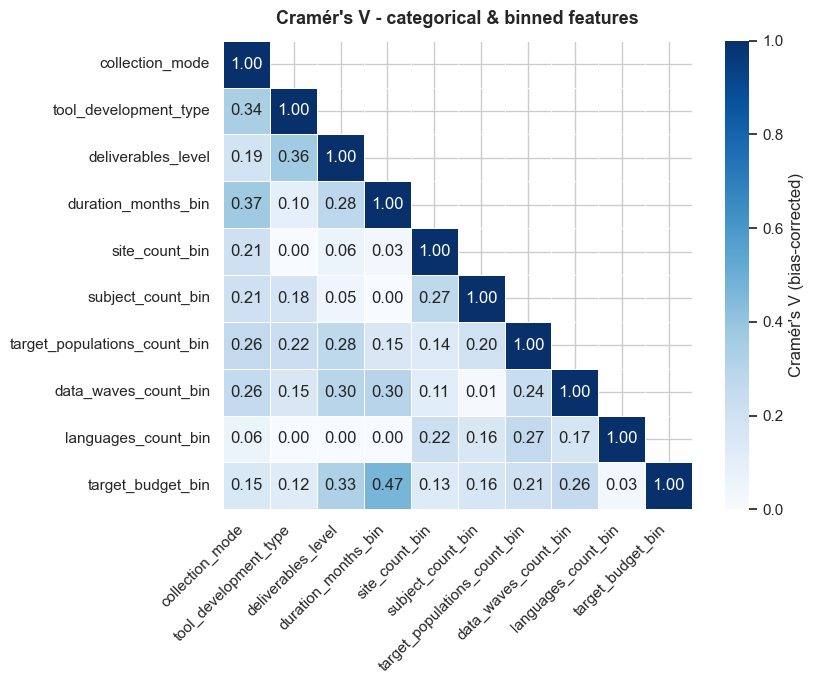

In [21]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramér's V (Bergsma, 2013), in [0, 1]."""
    contingency = pd.crosstab(x, y)
    if contingency.size == 0 or contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(contingency, correction=False)[0]
    n = contingency.sum().sum()
    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = contingency.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else np.nan


original_categorical_features = ["collection_mode", "tool_development_type", "deliverables_level"]
binned_feature_columns = [c for c in df_binned.columns if c.endswith("_bin") and c != "target_budget_bin"]
categorical_features = original_categorical_features + binned_feature_columns
all_categorical_cols = categorical_features + ["target_budget_bin"]

cramers_v_matrix = pd.DataFrame(
    [[1.0 if ci == cj else cramers_v(df_binned[ci], df_binned[cj]) for cj in all_categorical_cols]
     for ci in all_categorical_cols],
    index=all_categorical_cols, columns=all_categorical_cols,
)

# Sequential single hue (magnitude, not polarity); upper triangle masked since the matrix is symmetric
mask = np.triu(np.ones_like(cramers_v_matrix, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cramers_v_matrix, mask=mask, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Cramér's V (bias-corrected)"}, ax=ax)
ax.set_title("Cramér's V - categorical & binned features", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
# Each feature against the (4-tier) target
cramers_v_table = (
    pd.DataFrame([{"feature": f, "cramers_v": cramers_v(df_binned[f], df_binned["target_budget_bin"])}
                  for f in categorical_features])
    .dropna(subset=["cramers_v"])
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)
display(cramers_v_table)

# Strongest feature-vs-feature pairs (redundancy check)
pairs = [
    {"feature_1": c1, "feature_2": c2, "cramers_v": cramers_v_matrix.loc[c1, c2]}
    for i, c1 in enumerate(categorical_features) for c2 in categorical_features[i + 1:]
]
pd.DataFrame(pairs).sort_values("cramers_v", ascending=False).head(10)

,feature,cramers_v
0,duration_months_bin,0.470596
1,deliverables_level,0.326462
2,data_waves_count_bin,0.255868
3,target_populations_count_bin,0.210320
4,subject_count_bin,0.161510
5,collection_mode,0.152259
6,site_count_bin,0.131659
7,tool_development_type,0.121081
8,languages_count_bin,0.029709


,feature_1,feature_2,cramers_v
2,collection_mode,duration_months_bin,0.371193
8,tool_development_type,deliverables_level,0.363472
0,collection_mode,tool_development_type,0.339428
24,duration_months_bin,data_waves_count_bin,0.297131
19,deliverables_level,data_waves_count_bin,0.295393
15,deliverables_level,duration_months_bin,0.278285
18,deliverables_level,target_populations_count_bin,0.275417
26,site_count_bin,subject_count_bin,0.274188
34,target_populations_count_bin,languages_count_bin,0.265239
5,collection_mode,target_populations_count_bin,0.261920


### Insights → options → decision

- **Insight:** `duration_months_bin` (0.47) and `deliverables_level` (0.33) are the two strongest features against the target, well ahead of the rest.
  **Options:** (a) guarantee their inclusion as core features; (b) engineer an interaction; (c) let the model discover it.
  **Decision:** **(a)**. They are a fixed core in every model version. Consider (b) only if baseline performance is weaker than expected.

- **Insight:** four features cluster in a weak range (`subject_count_bin`, `collection_mode`, `site_count_bin`, `tool_development_type`: 0.12–0.16).
  **Options:** (a) drop them; (b) keep them and let **L1 regularization** down-weight whatever does not contribute; (c) filter by redundancy.
  **Decision:** **(b)**. Univariate Cramér's V alone is not reliable enough for manual exclusion; the model decides.

- **Insight:** `languages_count_bin` shows almost no association (0.03) **and** 40% missingness, so both signals point the same way.
  **Decision:** **drop it** from the first training pass, and revisit if more data becomes available.

- **Insight:** ranking reliability is limited. N=135, and the smallest target tier (900k–1M, n=9) produces contingency cells with expected counts below 5.
  **Decision:** narrow the modeling scope to **≤ 500,000 NIS** *before* building the baseline ([§5.3](#fe-scope)).

- **Insight:** `collection_mode` / `tool_development_type` / `deliverables_level` overlap partially (0.34–0.36), and duration/deliverables each overlap with `data_waves_count_bin` (~0.30), but **no pair crosses 0.4**.
  **Decision:** keep everything and let regularization distribute the weight. There is no severe multicollinearity, so early manual removal would only lose information.

### Feature exclusion decisions (consolidated)

| Feature | Issue | Decision |
|---|---|---|
| `budgeted_person_work` | Leakage (same source document, r ≈ 0.9+) **and** not known at prediction time | **Excluded** |
| `languages_count_bin` | Negligible signal (V = 0.03) + highest missingness (40%) | **Excluded** |
| `site_count_bin` | ~53% missing; weak association (V = 0.13) | Retained via "Not yet decided"; weak contributor |
| `data_waves_count_bin` | ~37% missing; moderate association (V = 0.26) | Retained via "Not yet decided" |
| `has_surveys` | Near-constant | **Pending:** not in the current matrix (exclude, or fold into a methodology-complexity score) |

<a id="fe-scope"></a>
## 5.3 Modeling scope — `target_budget ≤ 500,000 NIS`

The project scope (≤ 1,000,000 NIS) leaves a top tier with only **9 rows** (900k–1M), too few to learn from or to evaluate reliably. The modeling scope is narrowed to **`target_budget ≤ 500,000 NIS`**. This leaves **3 ordered target tiers** (33 / 60 / 33 rows). Input bins keep the same edges; only the counts are recomputed on the narrower row set.

In [23]:
print(f"Before scope reduction: N = {len(df_clean)}")
df_scope = df_clean[df_clean["target_budget"] <= MODEL_SCOPE_MAX_BUDGET].reset_index(drop=True)
print(f"After scope reduction:  N = {len(df_scope)}  (rows dropped: {len(df_clean) - len(df_scope)})")

# Same natural-gap logic as the 4-tier version, now with 3 tiers
target_budget_bin_edges = [-np.inf, 275_000, 325_000, np.inf]
target_budget_bin_labels = ["200,000–250,000 NIS", "300,000 NIS", "350,000–500,000 NIS"]

df_scope = apply_input_binning(df_scope)
df_scope = apply_target_binning(df_scope, target_budget_bin_edges, target_budget_bin_labels)

print("\ntarget_budget_bin distribution (modeling scope):")
print(df_scope["target_budget_bin"].value_counts(sort=False).to_string())

Before scope reduction: N = 135
After scope reduction:  N = 126  (rows dropped: 9)

target_budget_bin distribution (modeling scope):
target_budget_bin
200,000–250,000 NIS    33
300,000 NIS            60
350,000–500,000 NIS    33


<a id="fe-call-group"></a>
## 5.4 Call identity — `call_group`

`call_group` is the **grouping key of every cross-validation** in this notebook, so its quality directly determines whether leakage is fully removed (see [§6.3](#meth-leakage)). If two spellings of the same call end up in different groups, their proposals can still land on opposite sides of a train/test split.

Titles of the same call appear in several formats: `27/11.2021`, `27.11/2021`, `2021.11/27`, `27/11/21`, with or without `מס'`, and with different topic wording. The normalization works in two passes:

1. **`normalize_call_title`** parses the call-number stamp (number, month, year) in any of the observed orders and separators, normalizes 2-digit years to 4 digits, and returns a canonical key `NN/M.YYYY`. Titles with digits but no parsable stamp fall back to the sorted digit tokens (the original behaviour). Titles **without any number** fall back to normalized text.
2. **`resolve_unnumbered_calls`** maps each number-less title onto the numbered call whose (normalized) title **contains it verbatim** (minimum 4 words). This catches cases where the topic line was extracted without the call-number prefix.

Anything the two passes cannot resolve is listed for **manual review** and fixed in `CALL_GROUP_OVERRIDES`. After the first full run, two such cases were fixed there: the garbled stamp `25.207/91` (same topic and budget as **19/7.2025**) and the number-less corona title (same topic, year and budget as **26/11.2021**). This leaves **12 calls** in the modeling scope. The mapping is built over **all** rows of the raw data, so that `df`, `df_clean` and `df_scope` share one identical key.

In [24]:
# (number, month, year) stamp formats observed in the data, tried in order
CALL_NUMBER_PATTERNS = [
    # "27/11.2021", "27.11/2021", "27/8.24", "27/11/21"  ->  number, month, year
    (re.compile(r"(?<!\d)(\d{1,2})[/.](\d{1,2})[/.](\d{4}|\d{2})(?!\d)"), ("num", "month", "year")),
    # "2021.11/27", "2025.7/18"                           ->  year, month, number
    (re.compile(r"(?<!\d)(\d{4})[/.](\d{1,2})[/.](\d{1,2})(?!\d)"), ("year", "month", "num")),
]
MIN_WORDS_FOR_TEXT_MATCH = 4
# Manual fixes after reviewing the tables below. Keys: a raw call_title OR a pass-1 key; values: the call_group.
CALL_GROUP_OVERRIDES = {
    # Garbled stamp "25.207/91": same topic ("מחקר מלווה לפיילוט...") and budget (950k) as call 19/7.2025
    "207_25_91": "19/7.2025",
    # Number-less corona title: same topic, year (2021) and budget (300k) as call 26/11.2021
    "קול קורא למחקרים בנושא השפעות הקורונה": "26/11.2021",
}


def parse_call_number(title):
    """Return (number, month, 4-digit year) from the call-number stamp, or None if there is no valid stamp."""
    for pattern, order in CALL_NUMBER_PATTERNS:
        for match in pattern.finditer(title):
            parts = dict(zip(order, match.groups()))
            year = int(parts["year"])
            year = year + 2000 if year < 100 else year
            if YEAR_MIN <= year <= YEAR_MAX and 1 <= int(parts["month"]) <= 12:
                return int(parts["num"]), int(parts["month"]), year
    return None


def clean_title_text(title):
    """Punctuation-free, whitespace-collapsed, lower-cased title text."""
    cleaned = re.sub(r"[^\w\s]", "", title)
    return re.sub(r"\s+", " ", cleaned).strip().lower()


def normalize_call_title(title):
    """Canonical call key: 'NN/M.YYYY' when a stamp is parsable, else sorted digits, else normalized text."""
    parsed = parse_call_number(title)
    if parsed:
        num, month, year = parsed
        return f"{num}/{month}.{year}"
    numbers = re.findall(r"\d+", title)
    if numbers:
        # digits without a parsable stamp: original behaviour (order-insensitive digit key)
        return "_".join(sorted(numbers))
    # no number at all: fall back to normalized text so number-less titles are NOT merged together
    return clean_title_text(title)


def resolve_unnumbered_calls(titles):
    """Map number-less titles onto the unique numbered call whose normalized title contains them."""
    numbered_text_to_key = {
        clean_title_text(t): normalize_call_title(t) for t in titles if parse_call_number(t)
    }
    resolved = {}
    for title in titles:
        if re.search(r"\d", title):
            continue
        text = clean_title_text(title)
        if len(text.split()) < MIN_WORDS_FOR_TEXT_MATCH:
            continue
        matches = {key for full_text, key in numbered_text_to_key.items() if text in full_text}
        if len(matches) == 1:
            resolved[title] = matches.pop()
    return resolved

In [25]:
all_titles = pd.Series(df["call_title"].unique())

call_group_map = {title: normalize_call_title(title) for title in all_titles}   # pass 1
text_resolved = resolve_unnumbered_calls(all_titles)                             # pass 2
call_group_map.update(text_resolved)
call_group_map = {                                                               # manual fixes win
    title: CALL_GROUP_OVERRIDES.get(title, CALL_GROUP_OVERRIDES.get(key, key))
    for title, key in call_group_map.items()
}
applied_overrides = {t: k for t, k in call_group_map.items()
                     if t in CALL_GROUP_OVERRIDES or normalize_call_title(t) in CALL_GROUP_OVERRIDES}

for frame in (df, df_clean, df_binned, df_scope):
    frame["call_group"] = frame["call_title"].map(call_group_map)

print(f"Modeling scope: {len(df_scope)} proposals")
print(f"  distinct raw call_title values            : {df_scope['call_title'].nunique()}")
print(f"  call_group after key normalization only   : {df_scope['call_title'].map(normalize_call_title).nunique()}")
print(f"  final call_group (resolved + overrides)   : {df_scope['call_group'].nunique()}")

if text_resolved:
    print("\nNumber-less titles resolved onto a numbered call:")
    display(pd.Series(text_resolved, name="resolved call_group").rename_axis("number-less call_title").to_frame())
if applied_overrides:
    print("Manual overrides applied (CALL_GROUP_OVERRIDES):")
    display(pd.Series(applied_overrides, name="call_group").rename_axis("call_title").to_frame())

unresolved = [t for t in all_titles
              if not re.search(r"\d", t) and t not in text_resolved and t not in applied_overrides]
if unresolved:
    print("⚠ Number-less titles left as their own group (review manually; fix via CALL_GROUP_OVERRIDES):")
    for t in unresolved:
        print(f"   - {t}")

Modeling scope: 126 proposals
  distinct raw call_title values            : 33
  call_group after key normalization only   : 17
  final call_group (resolved + overrides)   : 12

Number-less titles resolved onto a numbered call:


,resolved call_group
number-less call_title,
מחקר מלווה לפיילוט המבוסס על מודל חדש ללמידת מורים מקצועית,19/7.2025
קבלת החלטות בית ספריות מבוססות נתונים בקרב מנהלי בתי ספר,27/8.2024
"השפעות בינה מלאכותית יוצרת על תלמידים ועובדי הוראה: חקר מגמות, דפוסים והשפעות",24/9.2025
תכניות להכשרה פדגוגית של מחנכים מטפלים במעונות יום לפעוטות,32/9.2023
היבטים חברתיים ורגשיים בשילוב AI במערכת החינוך,25/9.2025
"שיקולים של בוגרי החמ""ד בבחירת קריירה בהוראה, בחירת מוסד הכשרה להוראה ובחירת התמחות והשמה בהוראה.",34/9.2023


Manual overrides applied (CALL_GROUP_OVERRIDES):


,call_group
call_title,
קול קורא למחקרים בנושא השפעות הקורונה,26/11.2021
"קול קורא מס' 25.207/91 למחקר בנושא ""מחקר מלווה לפיילוט המבוסס על מודל חדש ללמידת מורים מקצועית""",19/7.2025


In [26]:
# Review table: one row per call in the modeling scope
group_review = (
    df_scope.groupby("call_group")
    .agg(n_proposals=("call_title", "size"),
         n_title_variants=("call_title", "nunique"),
         n_budget_values=("target_budget", "nunique"),
         target_budget=("target_budget", "first"),
         target_tier=("target_budget_bin", "first"),
         example_title=("call_title", "first"))
    .sort_values("n_proposals", ascending=False)
)
display(group_review)

# The framing assumes the target is a CALL-level attribute: verify it
inconsistent = group_review[group_review["n_budget_values"] > 1]
if inconsistent.empty:
    print("✓ target_budget is constant within every call_group, consistent with a call-level target.")
else:
    print(f"⚠ {len(inconsistent)} call_group(s) carry more than one target_budget value. Check for a merge error "
          "or a genuine per-proposal budget:")
    display(df_scope[df_scope["call_group"].isin(inconsistent.index)]
            [["call_group", "call_title", "source_file", "target_budget"]].sort_values("call_group"))

,n_proposals,n_title_variants,n_budget_values,target_budget,target_tier,example_title
call_group,,,,,,
27/11.2021,24,6,1,300000,"300,000 NIS",קול קורא מס' 2021.11/27 למחקר בנושא החינוך בחב...
15/5.2024,17,5,1,200000,"200,000–250,000 NIS",קול קורא מס' 15/5.2024 למחקר בנושא חינוך בצל מ...
26/11.2021,17,3,1,300000,"300,000 NIS",קול קורא למחקרים בנושא השפעות הקורונה
25/9.2025,15,2,1,300000,"300,000 NIS","קול קורא מס' 25/9.2025 למחקר בנושא ""היבטים חבר..."
24/9.2025,14,3,1,500000,"350,000–500,000 NIS","קול קורא מס' 24/9.2025 בנושא ""השפעות בינה מלאכ..."
14/5.2024,12,2,1,500000,"350,000–500,000 NIS",קול קורא מס' 14/5.2024 למחקר ופיתוח בנושא הורא...
27/8.2024,9,2,1,250000,"200,000–250,000 NIS","קול קורא מס' 27/8.24 למחקר בנושא ""קבלת החלטות ..."
26/8.2024,7,4,1,250000,"200,000–250,000 NIS","קול קורא מס' 26/8.24 למחקר בנושא ""התנדבות תלמי..."
18/7.2025,4,2,1,300000,"300,000 NIS","קול קורא מס' 18/7.2025 למחקר בנושא תוכנית ""בוח..."


✓ target_budget is constant within every call_group, consistent with a call-level target.


<a id="fe-call-year"></a>
## 5.5 Call year — `call_year`

The publication year is extracted **per call**, not per proposal, with a documented cascade. Every call records which source its year came from (`call_year_source`):

1. **Primary (as specified):** a regex for a **4-digit year in the range 2015–2030** in `call_title`.
2. **Fallback 1:** the **2-digit year of the call-number stamp** (e.g. `27/8.24` → 2024), for titles written with a short year.
3. **Fallback 2:** the **2-digit suffix of `source_file`** (e.g. `…_24.txt` → 2024), for titles with no number at all. It is validated below against the title year wherever both exist.

Every row where the primary regex fails is listed, so each fallback is visible and auditable.

In [27]:
YEAR_PATTERN = re.compile(r"(?<!\d)(" + "|".join(map(str, range(YEAR_MIN, YEAR_MAX + 1))) + r")(?!\d)")
FILE_YEAR_PATTERN = re.compile(r"(?<!\d)(\d{2})(?!\d)")


def year_from_title_4digit(title):
    """Unique 4-digit year in [YEAR_MIN, YEAR_MAX] found in the title; NaN if none or ambiguous."""
    years = {int(y) for y in YEAR_PATTERN.findall(title)}
    return years.pop() if len(years) == 1 else np.nan


def year_from_call_number(title):
    parsed = parse_call_number(title)
    return parsed[2] if parsed else np.nan


def year_from_source_file(source_file):
    """First stand-alone 2-digit token in the file stem that maps to a plausible year
    ('name_24.txt', 'name24.txt', 'name_25__2_.txt' -> 2024 / 2024 / 2025)."""
    for token in FILE_YEAR_PATTERN.findall(Path(str(source_file)).stem):
        year = 2000 + int(token)
        if YEAR_MIN <= year <= YEAR_MAX:
            return year
    return np.nan


YEAR_SOURCES = [
    ("year_title_4digit", "title: 4-digit regex"),
    ("year_call_number", "title: 2-digit call-number stamp"),
    ("year_source_file", "source_file suffix"),
]

year_rows = df[["call_group", "call_title", "source_file"]].copy()
year_rows["year_title_4digit"] = year_rows["call_title"].map(year_from_title_4digit)
year_rows["year_call_number"] = year_rows["call_title"].map(year_from_call_number)
year_rows["year_source_file"] = year_rows["source_file"].map(year_from_source_file)


def resolve_call_year(rows):
    """Take the first source in YEAR_SOURCES that yields a year for this call; flag conflicting values."""
    for col, label in YEAR_SOURCES:
        values = rows[col].dropna()
        if values.empty:
            continue
        year = int(values.mode().iloc[0])
        if values.nunique() > 1:
            label = f"{label} (CONFLICT: {sorted(int(v) for v in values.unique())})"
        return pd.Series({"call_year": year, "call_year_source": label})
    return pd.Series({"call_year": np.nan, "call_year_source": "unresolved"})


call_years = year_rows.groupby("call_group")[[c for c, _ in YEAR_SOURCES]].apply(resolve_call_year)

In [28]:
# --- Extraction audit ---
failed_rows = year_rows[year_rows["year_title_4digit"].isna()]
print(f"Rows where the 4-digit regex found no year in call_title: {len(failed_rows)} / {len(year_rows)}")
if not failed_rows.empty:
    display(failed_rows[["call_group", "call_title", "source_file", "year_call_number", "year_source_file"]]
            .sort_values("call_group"))

print("\nYear source per call:")
display(call_years["call_year_source"].value_counts().to_frame("n_calls"))

# Validate the source_file fallback where the title also carries a year
both = year_rows.dropna(subset=["year_title_4digit", "year_source_file"])
if len(both):
    agreement = (both["year_title_4digit"] == both["year_source_file"]).mean()
    print(f"Agreement between title year and source_file year (rows with both): {agreement:.0%} (n={len(both)})")
    disagree = both[both["year_title_4digit"] != both["year_source_file"]]
    if not disagree.empty:
        print("⚠ Disagreeing rows (the source_file suffix may encode the submission year, not the call year):")
        display(disagree[["call_group", "call_title", "source_file", "year_title_4digit", "year_source_file"]])

n_unresolved = call_years["call_year"].isna().sum()
print(f"\nCalls with no resolvable year: {n_unresolved}")

for frame in (df, df_clean, df_scope):
    frame["call_year"] = frame["call_group"].map(call_years["call_year"])

display(call_years.sort_values("call_year"))

Rows where the 4-digit regex found no year in call_title: 33 / 140


,call_group,call_title,source_file,year_call_number,year_source_file
17,19/7.2025,"קול קורא מס' 25.207/91 למחקר בנושא ""מחקר מלווה...",אבידב_אונגר_בלאו_25.txt,NaN,2025
28,19/7.2025,מחקר מלווה לפיילוט המבוסס על מודל חדש ללמידת מ...,דורית_טובין_25.txt,NaN,2025
36,24/9.2025,השפעות בינה מלאכותית יוצרת על תלמידים ועובדי ה...,אסטרחן_גוטנג_ארווץ_25.txt,NaN,2025
61,24/9.2025,השפעות בינה מלאכותית יוצרת על תלמידים ועובדי ה...,עביר_עסלה_25.txt,NaN,2025
72,24/9.2025,השפעות בינה מלאכותית יוצרת על תלמידים ועובדי ה...,מישר_טל_25.txt,NaN,2025
77,24/9.2025,השפעות בינה מלאכותית יוצרת על תלמידים ועובדי ה...,ניצב_דוידוביץ_25.txt,NaN,2025
86,24/9.2025,השפעות בינה מלאכותית יוצרת על תלמידים ועובדי ה...,ראויה_חאיק_25.txt,NaN,2025
97,24/9.2025,השפעות בינה מלאכותית יוצרת על תלמידים ועובדי ה...,ציבולסקי_25.txt,NaN,2025
113,24/9.2025,השפעות בינה מלאכותית יוצרת על תלמידים ועובדי ה...,רול_25.txt,NaN,2025
88,25/9.2025,היבטים חברתיים ורגשיים בשילוב AI במערכת החינוך,ענת_כהן_25.txt,NaN,2025



Year source per call:


,n_calls
call_year_source,
title: 4-digit regex,13
title: 2-digit call-number stamp,3


Agreement between title year and source_file year (rows with both): 100% (n=107)

Calls with no resolvable year: 0


,call_year,call_year_source
call_group,,
26/11.2021,2021,title: 4-digit regex
27/11.2021,2021,title: 4-digit regex
34/9.2023,2023,title: 4-digit regex
33/9.2023,2023,title: 4-digit regex
32/9.2023,2023,title: 4-digit regex
14/5.2024,2024,title: 4-digit regex
15/5.2024,2024,title: 4-digit regex
26/8.2024,2024,title: 2-digit call-number stamp
31/9.2024,2024,title: 2-digit call-number stamp


<a id="fe-year-features"></a>
## 5.6 Year-level context features (leave-one-out)

Two features describe the **Ministry's research activity in the call's publication year**:

- **`num_calls_year_excl_self`**: the number of **other** calls (excluding the current call) published in the same year.
- **`total_budget_year_excl_self`**: the sum of the budgets of those **other** calls. The current call is excluded because the yearly total would otherwise contain the call's own target, which is a direct accounting identity (circularity).

Both are computed **at the call level** (`call_group` after `drop_duplicates`), never at the row level. Otherwise a call with many proposals would be counted, and its budget summed, once per proposal.

**Universe of calls:** all calls in the dataset (including those above the modeling scope, since they are real calls published that year), controlled by `YEAR_CONTEXT_MAX_BUDGET`. Note that "calls in the dataset" means calls with at least one collected proposal, not necessarily every call the Ministry published.

> ⚠ **Leave-one-out is necessary but not sufficient under cross-validation.** If these features are computed once on the full data, the *training* rows of a year contain the budget of the *held-out* call in their sums. This lets a model recover the held-out target. The features are therefore **recomputed inside every CV split** from training-fold calls only; see [§6.4](#meth-year-leakage). The full-data version below is used for description and for the final (deployment) fit only.

In [29]:
# One row per call: drop_duplicates on call_group, never per proposal
calls_source = df if YEAR_CONTEXT_MAX_BUDGET is None else df[df["target_budget"] <= YEAR_CONTEXT_MAX_BUDGET]
calls = calls_source.drop_duplicates(subset="call_group")[["call_group"]].set_index("call_group")
calls["call_budget"] = calls_source.groupby("call_group")["target_budget"].median()   # == the shared value (checked in 5.4)
calls["call_year"] = call_years["call_year"].reindex(calls.index)
calls["n_proposals"] = calls_source.groupby("call_group").size()

YEAR_FEATURES = ["num_calls_year_excl_self", "total_budget_year_excl_self"]


def year_context_features(calls_table, reference_calls=None):
    """Leave-one-out year-level context for every call in `calls_table`.

    For call c published in year y, over the reference set R (default: every call):
        num_calls_year_excl_self    = |{c' in R : year(c') = y, c' != c}|
        total_budget_year_excl_self = sum of budget(c') over the same set
    Inside CV, pass the training-fold calls as `reference_calls`, so that no held-out budget enters any feature.
    """
    ref = calls_table if reference_calls is None else calls_table.loc[calls_table.index.intersection(reference_calls)]
    per_year = ref.dropna(subset=["call_year"]).groupby("call_year")["call_budget"].agg(["size", "sum"])

    n_same_year = calls_table["call_year"].map(per_year["size"]).fillna(0)
    sum_same_year = calls_table["call_year"].map(per_year["sum"]).fillna(0)
    self_in_ref = calls_table.index.isin(ref.index)

    out = pd.DataFrame(index=calls_table.index)
    out["num_calls_year_excl_self"] = n_same_year - self_in_ref.astype(int)
    out["total_budget_year_excl_self"] = sum_same_year - np.where(self_in_ref, calls_table["call_budget"], 0)
    out.loc[calls_table["call_year"].isna(), YEAR_FEATURES] = np.nan   # unknown year -> unknown context
    return out


def attach_call_features(frame, call_features):
    """Broadcast call-level features onto proposal rows (aligned to frame.index)."""
    return call_features.reindex(frame["call_group"].to_numpy()).set_axis(frame.index)


call_year_features = year_context_features(calls)                     # full-data version (description / deployment)
df_scope[YEAR_FEATURES] = attach_call_features(df_scope, call_year_features)

display(calls.join(call_year_features).sort_values(["call_year", "call_budget"]))
print("Missing values in the year features (modeling scope):", df_scope[YEAR_FEATURES].isna().sum().to_dict())

,call_budget,call_year,n_proposals,num_calls_year_excl_self,total_budget_year_excl_self
call_group,,,,,
27/11.2021,300000.0,2021,24,1.0,300000.0
26/11.2021,300000.0,2021,17,1.0,300000.0
34/9.2023,350000.0,2023,3,2.0,1500000.0
33/9.2023,500000.0,2023,3,2.0,1350000.0
32/9.2023,1000000.0,2023,3,2.0,850000.0
15/5.2024,200000.0,2024,17,4.0,2000000.0
27/8.2024,250000.0,2024,9,4.0,1950000.0
26/8.2024,250000.0,2024,7,4.0,1950000.0
14/5.2024,500000.0,2024,12,4.0,1700000.0


Missing values in the year features (modeling scope): {'num_calls_year_excl_self': 0, 'total_budget_year_excl_self': 0}


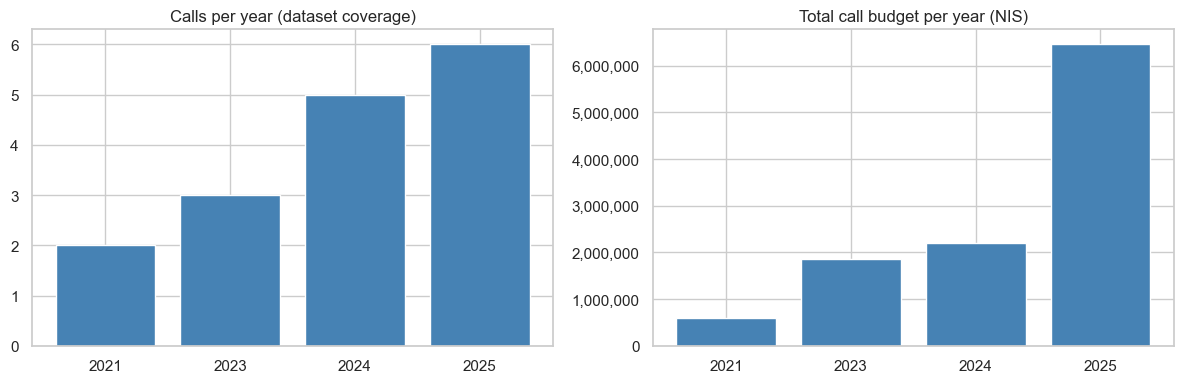

,"within_year_spearman(total_excl_self, own_budget)"
call_year,
2021,NaN
2023,-1.0
2024,-1.0
2025,-1.0


In [30]:
# Year-level activity, plus the residual circularity of the leave-one-out total
per_year = calls.groupby("call_year").agg(n_calls=("call_budget", "size"), total_budget=("call_budget", "sum"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(per_year.index.astype(int).astype(str), per_year["n_calls"], color="steelblue")
axes[0].set_title("Calls per year (dataset coverage)")
axes[1].bar(per_year.index.astype(int).astype(str), per_year["total_budget"], color="steelblue")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
axes[1].set_title("Total call budget per year (NIS)")
plt.tight_layout()
plt.show()

# Within a year, total_budget_year_excl_self = T_year - own budget, i.e. a perfect negative function of the
# target. The within-year Spearman correlation makes this visible (-1 wherever budgets vary inside a year).
diag = calls.join(call_year_features).dropna(subset=["call_year"])
within_year_rho = (
    diag.groupby("call_year")
    .apply(lambda g: g["total_budget_year_excl_self"].corr(g["call_budget"], method="spearman")
           if len(g) >= 3 and g["call_budget"].nunique() > 1 else np.nan)   # NaN when budgets are constant
    .rename("within_year_spearman(total_excl_self, own_budget)")
)
display(within_year_rho.to_frame())

<a id="fe-matrix"></a>
## 5.7 Model matrix — `df_baseline`

| Feature | Status | Reason | Encoding |
|---|---|---|---|
| `duration_months_bin` | Included (core) | Strongest predictor (V = 0.47) | Ordinal (`.cat.codes`) |
| `deliverables_level` | Included (core) | Second-strongest predictor (V = 0.33) | Ordinal: `Standard < Extended < Unknown` |
| `data_waves_count_bin` | Included | Moderate signal (V = 0.26) | Ordinal |
| `target_populations_count_bin` | Included | Moderate signal (V = 0.21) | Ordinal |
| `subject_count_bin` | Included | Weak alone; L1 decides | Ordinal |
| `site_count_bin` | Included | Weak alone; L1 decides | Ordinal |
| `collection_mode` | Included | Weak alone; L1 decides | One-Hot |
| `tool_development_type` | Included | Weak alone; L1 decides | One-Hot |
| `languages_count_bin` | **Excluded** | Negligible signal + highest missingness | — |
| `budgeted_person_work` | **Excluded** | Leakage + unknown at prediction time | — |
| `has_surveys` | **Pending** | Near-constant; disposition open | — |
| `call_title`, `pi_name`, `proposal_title`, `source_file` | **Excluded** | Free text / identifiers | — |
| `num_calls_year_excl_self`, `total_budget_year_excl_self` | Added in §7.3 | Year-level context (fold-safe in CV) | Numeric, standardized |
| `target_budget_bin` | **Target** | — | Ordinal codes (label, not a feature) |

For ordinal bins, "Not yet decided" is the last category and therefore receives the highest code.

In [31]:
df_baseline = pd.DataFrame(index=df_scope.index)

# --- Ordinal features (ordered categoricals -> integer codes) ---
ordinal_features = [
    "duration_months_bin",
    "subject_count_bin",
    "site_count_bin",
    "data_waves_count_bin",
    "target_populations_count_bin",
]
for col in ordinal_features:
    df_baseline[col] = df_scope[col].cat.codes

# deliverables_level: explicit semantic order (not alphabetical)
deliverables_level_order = ["Standard", "Extended", "Unknown"]
df_scope["deliverables_level"] = pd.Categorical(df_scope["deliverables_level"],
                                                categories=deliverables_level_order, ordered=True)
df_baseline["deliverables_level"] = df_scope["deliverables_level"].cat.codes

# --- Nominal features (no natural order -> One-Hot) ---
nominal_features = ["collection_mode", "tool_development_type"]
df_baseline = pd.concat(
    [df_baseline, pd.get_dummies(df_scope[nominal_features], prefix=nominal_features, drop_first=False)], axis=1
)

# --- Target (kept separate from the feature matrix) ---
y_baseline = df_scope["target_budget_bin"].cat.codes
target_labels = df_scope["target_budget_bin"].cat.categories.tolist()

# --- Sanity checks ---
assert df_baseline.isna().sum().sum() == 0, "df_baseline contains missing values"
assert (df_baseline["deliverables_level"] >= 0).all(), "unexpected deliverables_level category (code -1)"
print(f"df_baseline shape: {df_baseline.shape}")
print(f"Features: {list(df_baseline.columns)}")
print(f"\ny_baseline distribution: {y_baseline.value_counts(sort=False).sort_index().to_dict()}")
print(f"target_labels (class-code order): {target_labels}")
df_baseline.head()

df_baseline shape: (126, 16)
Features: ['duration_months_bin', 'subject_count_bin', 'site_count_bin', 'data_waves_count_bin', 'target_populations_count_bin', 'deliverables_level', 'collection_mode_Field', 'collection_mode_Mixed', 'collection_mode_Online', 'collection_mode_SurveyInstitute', 'collection_mode_Unknown', 'tool_development_type_Adaptation', 'tool_development_type_Existing', 'tool_development_type_New', 'tool_development_type_Unknown', 'tool_development_type_Validation']

y_baseline distribution: {0: 33, 1: 60, 2: 33}
target_labels (class-code order): ['200,000–250,000 NIS', '300,000 NIS', '350,000–500,000 NIS']


,duration_months_bin,subject_count_bin,site_count_bin,data_waves_count_bin,target_populations_count_bin,deliverables_level,collection_mode_Field,collection_mode_Mixed,collection_mode_Online,collection_mode_SurveyInstitute,collection_mode_Unknown,tool_development_type_Adaptation,tool_development_type_Existing,tool_development_type_New,tool_development_type_Unknown,tool_development_type_Validation
0,0,0,2,3,3,2,False,False,True,False,False,False,False,False,True,False
1,0,0,0,0,1,1,False,True,False,False,False,False,False,True,False,False
2,0,0,1,3,2,2,True,False,False,False,False,False,False,False,True,False
3,0,1,1,1,0,0,False,True,False,False,False,False,False,True,False,False
4,0,2,3,1,1,1,False,False,True,False,False,True,False,False,False,False


<a id="methodology"></a>
# 6. Methodology & Statistical Validity

This section explains why the modeling approach is statistically valid, what it does **not** claim, and how performance is measured honestly. The code at the end of the section sets up the single evaluation protocol that every model in §7 uses.

<a id="meth-unit"></a>
## 6.1 Unit of observation vs. unit of target

- **Rows are proposals** (126 in the modeling scope), but **the target is a property of the call**: the Ministry fixes it before publication, and every proposal submitted to a call carries the same value (verified in §5.4).
- **Consequence 1: what the model learns.** The inputs (duration, waves, collection mode, …) vary *between proposals of the same call*, while the target does not. The model learns how the *range of methodologies researchers propose* co-varies with the *budget of the call they answered*.
- **Consequence 2: independent evidence about the target.** There are only as many independent target values as there are **calls**: **12** in the modeling scope, split **3 / 4 / 5** across the three tiers. The proposals add evidence about the methodology side, but every statement about price is anchored on 12 independently priced calls. This is why grouping by call is mandatory (§6.3), and why every uncertainty estimate in this notebook resamples **calls**, not proposals.

<a id="meth-validity"></a>
## 6.2 Why the approach is valid — and what it does not claim

**Using every proposal is valid.** The model is not asked "which proposal will win?" but *"given a budget X, what methodology do researchers propose?"*, read in reverse as a benchmark: *"calls that attracted methodologies like this one were historically priced at X"*. A losing proposal is just as informative about that pattern as a winning one. **Reducing the data to one winning proposal per call is therefore neither needed nor desirable**, since it would discard valid observations.

**The relationship is associative, not causal.** Historical budgets were set *before* any methodology existed, so the learned pattern may partly reflect the **reverse process**: a fixed budget → researchers sizing their methodology to fit it. The model does not show that a given methodology *costs* a given amount. Its correct use is as an **associative benchmark**: a data-driven reference for how comparable calls were priced. Every report built on it should say so explicitly, for example: *"Calls with a comparable expected methodology were historically priced in tier X"*, not *"this methodology costs X"*.

<a id="meth-leakage"></a>
## 6.3 Leakage and grouped cross-validation

**The problem.** With a plain `StratifiedKFold`, proposals from the same call ("siblings") are split across train and test. Siblings share the exact same target and, since they answer the same brief, similar methodology. The model can then score well by effectively **recognizing the call** from its siblings in the training fold, rather than by generalizing to a call it has never seen. §6.6 measures the resulting inflation on the current data.

**The fix.** **`StratifiedGroupKFold`** with `groups = call_group`: every proposal of a call lands in the same fold, and class proportions are kept as balanced as the grouping allows. Each test fold now simulates the real use case, which is **pricing a new call** that was not seen in training. The fix only works if the group key is correct, which is why §5.4 resolves every spelling of a call into one `call_group`. Grouping by the raw title (33 variants) was still partially leaky (§6.6).

**Why no additional data collection is needed.** The inflation was not caused by the sample size. It was caused by the **measurement method**: how performance is estimated, not how much data there is. Correcting the CV scheme yields an **honest, reliable estimate on the same existing data**, without collecting more researchers or calls.

*What more data would and would not change:* additional calls would **narrow** the uncertainty around that honest estimate (narrower confidence intervals). They are **not** required to make the estimate unbiased; the grouped CV already does that. Collecting more data is therefore a separate, optional decision about precision, not a prerequisite for validity.

<a id="meth-year-leakage"></a>
## 6.4 Leakage risk in the year-level features

The two year features (§5.6) are leave-one-out **at the call level**, which removes the direct identity "yearly total contains my own budget". Under cross-validation, however, a second-order leak remains if the features are computed once on the full data:

> Suppose year *Y* has calls **A, B, C** and **C** is held out. On the full data, `total_excl_self(A) = B + C` and `total_excl_self(B) = A + C`, so **the training rows contain C's budget**. A model that has learned "own budget = yearly total − feature" (easy when `num_calls_year_excl_self` acts as a year identifier) can then compute C's budget from `total_excl_self(C) = A + B`.

**Fold-safe computation.** In every CV split, the features are recomputed from the **training-fold calls only**, plus calls outside the modeling scope, which are never predicted. Training rows get "other training calls in the same year" and test rows get "training calls in the same year". No held-out budget enters any feature. This is the only version used for evaluation. The full-data version is also evaluated once, labelled **[LEAKY REF]**, only to show how much a naive computation would change the score.

**Residual caveat, even when fold-safe.** Within a year, `total_budget_year_excl_self` equals the yearly total minus the call's own budget, so on the training fold it is still (negatively) tied to the target (the within-year Spearman of −1 in §5.6). `num_calls_year_excl_self` carries no budget information at all, so it is evaluated alone as an **ablation**.

<a id="meth-protocol"></a>
## 6.5 Evaluation protocol

The first full run exposed two problems with a "repeated 5-fold, average the fold scores" protocol on 12 calls. The protocol below fixes both.

1. **Repeats were not distinct.** Each call belongs to a single tier, so `StratifiedGroupKFold` has very little freedom. Across hundreds of seeds it produces only **2 distinct partitions** of the calls, so "10 repeats" were really 2 partitions counted 5 times each. **Fix:** seeds are scanned and **only distinct partitions are kept**.
2. **Per-fold macro-F1 is biased with 2–3 calls per fold.** A test fold often contains only two tiers. Any prediction of the third tier then gives that tier F1 = 0, which drags down the fold's macro-F1 even though those are ordinary errors. For the same model, the per-fold average was ≈0.33 while the pooled report gave ≈0.49. **Fix:** out-of-fold predictions are **pooled over the whole partition**, and every metric is computed **once on all 126 predictions** (Forman & Scholz, 2010). This is the standard remedy for tiny or unbalanced folds.

**Resulting protocol**

- **Primary scheme:** `StratifiedGroupKFold(n_splits=5)` with `groups = call_group`, using its distinct partitions. Metrics are pooled per partition, then averaged over the partitions.
- **Robustness check: Leave-One-Call-Out** (`LeaveOneGroupOut`, 12 folds). Each call is priced by a model trained on the other 11, which mirrors deployment exactly. A conclusion is trusted only if both schemes agree on its direction.
- **Uncertainty: call-level bootstrap.** The 12 calls are resampled with replacement (2,000 times), and the metric is recomputed from the fixed out-of-fold predictions. This gives a 95% CI per model. For **paired** comparisons, both models use the same resampled calls, giving a CI for the difference. A difference is called *significant* only when its 95% CI excludes zero. The CIs reflect uncertainty over which calls happened to be observed; they do not include refitting variance.
- **Metrics:** macro-F1 (primary; every tier weighted equally), accuracy, weighted-F1, **MAE in tiers** (mean |true − predicted| tier index, the natural ordinal error) and **extreme jumps** (lowest ↔ highest tier, skipping the middle).
- **Grouping everywhere:** every `cross_validate`, `cross_val_predict` and `GridSearchCV.fit` call passes `groups=groups`.

In [32]:
# ---------------------------------------------------------------
# Single source of truth for grouping and splitting
# ---------------------------------------------------------------
groups = df_scope["call_group"]        # grouping key for EVERY cross-validation below
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def make_grouped_cv(seed):
    return StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)


def partition_key(splitter):
    """The partition of CALLS into test folds produced by a splitter (order-free)."""
    return frozenset(frozenset(groups.iloc[test_idx]) for _, test_idx in splitter.split(df_baseline, y_baseline, groups))


# Keep only seeds that yield a DISTINCT partition of the calls (the first seed is always RANDOM_STATE)
CV_SEEDS, _seen_partitions = [], set()
for seed in range(RANDOM_STATE, RANDOM_STATE + N_CANDIDATE_SEEDS):
    key = partition_key(make_grouped_cv(seed))
    if key not in _seen_partitions:
        _seen_partitions.add(key)
        CV_SEEDS.append(seed)

SCHEMES = {
    "SGKF": [make_grouped_cv(seed) for seed in CV_SEEDS],   # primary: distinct StratifiedGroupKFold partitions
    "LOCO": [LeaveOneGroupOut()],                           # robustness: leave-one-call-out
}

print(f"Proposals: {len(df_scope)} | independent calls (groups): {groups.nunique()} | tiers: {len(target_labels)}")
print(f"StratifiedGroupKFold: {len(CV_SEEDS)} distinct partition(s) over {N_CANDIDATE_SEEDS} seeds -> seeds {CV_SEEDS}")

# Class balance at the call level: the number that actually limits the evaluation
call_level_counts = (df_scope.drop_duplicates("call_group")["target_budget_bin"]
                     .value_counts(sort=False).rename("n_calls"))
display(call_level_counts.to_frame().join(df_scope["target_budget_bin"].value_counts(sort=False).rename("n_proposals")))

Proposals: 126 | independent calls (groups): 12 | tiers: 3
StratifiedGroupKFold: 2 distinct partition(s) over 200 seeds -> seeds [42, 43]


,n_calls,n_proposals
target_budget_bin,,
"200,000–250,000 NIS",3,33
"300,000 NIS",4,60
"350,000–500,000 NIS",5,33


In [33]:
# ---------------------------------------------------------------
# Fold audit for every split of every scheme:
#   (1) no call appears on both sides of a split
#   (2) every training fold contains every tier (the ordinal model needs all classes)
# ---------------------------------------------------------------
fold_audit = []
for scheme, splitters in SCHEMES.items():
    for p, splitter in enumerate(splitters):
        for fold, (train_idx, test_idx) in enumerate(splitter.split(df_baseline, y_baseline, groups)):
            train_calls, test_calls = set(groups.iloc[train_idx]), set(groups.iloc[test_idx])
            assert train_calls.isdisjoint(test_calls), f"call leakage in {scheme}, partition={p}, fold={fold}"
            fold_audit.append({
                "scheme": scheme, "partition": p, "fold": fold,
                "test_calls": len(test_calls), "test_rows": len(test_idx),
                "train_tiers": y_baseline.iloc[train_idx].nunique(),
                "test_tiers": y_baseline.iloc[test_idx].nunique(),
            })
fold_audit = pd.DataFrame(fold_audit)

print(f"✓ No call shared between train and test in any of {len(fold_audit)} splits.")
print(f"Training folds missing a tier: {(fold_audit['train_tiers'] < len(target_labels)).sum()} / {len(fold_audit)}")
fold_audit[fold_audit["scheme"] == "SGKF"]

✓ No call shared between train and test in any of 22 splits.
Training folds missing a tier: 0 / 22


,scheme,partition,fold,test_calls,test_rows,train_tiers,test_tiers
0,SGKF,0,0,2,27,3,2
1,SGKF,0,1,3,24,3,3
2,SGKF,0,2,3,25,3,3
3,SGKF,0,3,2,27,3,2
4,SGKF,0,4,2,23,3,2
5,SGKF,1,0,2,27,3,2
6,SGKF,1,1,3,24,3,3
7,SGKF,1,2,3,25,3,3
8,SGKF,1,3,2,27,3,2
9,SGKF,1,4,2,23,3,2


In [34]:
# ---------------------------------------------------------------
# Model factories
# ---------------------------------------------------------------
def make_l1_logreg():
    """Multinomial logistic regression with a pure L1 (Lasso) penalty.
    scikit-learn >= 1.8 sets the penalty through `l1_ratio` (`penalty` is deprecated there);
    older versions need penalty="l1", otherwise `l1_ratio` is ignored and an L2 model is fitted."""
    major, minor = (int(p) for p in sklearn.__version__.split(".")[:2])
    if (major, minor) >= (1, 8):
        return LogisticRegression(l1_ratio=1, solver="saga", max_iter=5000, random_state=RANDOM_STATE)
    return LogisticRegression(penalty="l1", solver="saga", max_iter=5000, random_state=RANDOM_STATE)


def make_multinomial_pipeline(impute=False):
    # Scaling matters: L1 penalizes coefficient magnitude, so ordinal codes and 0/1 dummies must share a scale
    steps = [("scaler", StandardScaler()), ("model", make_l1_logreg())]
    if impute:
        steps.insert(0, ("imputer", SimpleImputer(strategy="median")))   # only for year features of unknown-year calls
    return Pipeline(steps)


def make_ordinal_pipeline(alpha=1.0, impute=False):
    steps = [("scaler", StandardScaler()), ("model", mord.LogisticAT(alpha=alpha))]
    if impute:
        steps.insert(0, ("imputer", SimpleImputer(strategy="median")))
    return Pipeline(steps)


# ---------------------------------------------------------------
# Metrics on POOLED out-of-fold predictions
# ---------------------------------------------------------------
METRICS = ["f1_macro", "accuracy", "f1_weighted", "mae_tiers"]
LOWER_IS_BETTER = {"mae_tiers"}


def pooled_metrics(y_true, y_pred):
    """All metrics from one confusion matrix. Macro-F1 averages over the tiers present in y_true."""
    y_true, y_pred = np.asarray(y_true, dtype=int), np.asarray(y_pred, dtype=int)
    k = len(target_labels)
    cm = np.bincount(k * y_true + y_pred, minlength=k * k).reshape(k, k)
    tp, support, predicted = np.diag(cm).astype(float), cm.sum(axis=1), cm.sum(axis=0)
    denom = support + predicted
    f1 = np.divide(2 * tp, denom, out=np.zeros(k), where=denom > 0)     # F1 = 2TP / (2TP + FP + FN)
    return {
        "f1_macro": f1[support > 0].mean(),
        "accuracy": tp.sum() / len(y_true),
        "f1_weighted": (f1 * support).sum() / support.sum(),
        "mae_tiers": np.abs(y_true - y_pred).mean(),
        "extreme_jumps": float(cm[0, -1] + cm[-1, 0]),
    }


# Call-level bootstrap samples, shared by all models -> paired comparisons
_call_ids = groups.to_numpy()
_unique_calls = np.unique(_call_ids)
_rows_by_call = {c: np.flatnonzero(_call_ids == c) for c in _unique_calls}
_rng = np.random.default_rng(RANDOM_STATE)
BOOT_SAMPLES = [
    np.concatenate([_rows_by_call[c] for c in _rng.choice(_unique_calls, size=len(_unique_calls), replace=True)])
    for _ in range(N_BOOT)
]


# ---------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------
RESULTS = {}      # model name -> evaluation record; feeds the comparison table in section 8


def oof_predict(estimator, X, y, groups, splitter, fold_feature_fn=None):
    """Out-of-fold predictions for one partition. fold_feature_fn(train_idx, test_idx) -> (extra_train, extra_test)
    adds features that must be recomputed inside each split from training data only (year-level context)."""
    if fold_feature_fn is None:
        return np.asarray(cross_val_predict(estimator, X, y, cv=splitter, groups=groups)), X.shape[1]
    y_oof, n_features = np.empty(len(y), dtype=int), X.shape[1]
    for train_idx, test_idx in splitter.split(X, y, groups):
        extra_train, extra_test = fold_feature_fn(train_idx, test_idx)
        X_train = pd.concat([X.iloc[train_idx], extra_train], axis=1)
        X_test = pd.concat([X.iloc[test_idx], extra_test], axis=1)
        n_features = X_train.shape[1]
        y_oof[test_idx] = clone(estimator).fit(X_train, y.iloc[train_idx]).predict(X_test)
    return y_oof, n_features


def evaluate_model(name, estimator, X, y, groups, fold_feature_fn=None, note="", verbose=True, register=True):
    """Pooled out-of-fold evaluation under both grouped schemes + call-level bootstrap."""
    y_arr = np.asarray(y, dtype=int)
    k = len(target_labels)
    record = {"model": name, "note": note, "oof": {}}
    for scheme, splitters in SCHEMES.items():
        oofs = []
        for splitter in splitters:
            y_oof, n_features = oof_predict(estimator, X, y, groups, splitter, fold_feature_fn)
            oofs.append(y_oof)
        record["oof"][scheme] = oofs
        per_partition = [pooled_metrics(y_arr, o) for o in oofs]
        for m in per_partition[0]:
            record[f"{scheme}_{m}"] = float(np.mean([p[m] for p in per_partition]))
        record[f"cm_{scheme}"] = np.mean([confusion_matrix(y_arr, o, labels=range(k)) for o in oofs], axis=0)
    record["n_features"] = n_features

    # bootstrap distribution of every metric (primary scheme, averaged over its partitions)
    oofs = record["oof"]["SGKF"]
    boot = [[pooled_metrics(y_arr[s], o[s]) for o in oofs] for s in BOOT_SAMPLES]
    record["boot"] = {m: np.array([np.mean([p[m] for p in b]) for b in boot]) for m in METRICS}
    record["f1_macro_ci"] = np.percentile(record["boot"]["f1_macro"], [2.5, 97.5])

    if register:
        RESULTS[name] = record
    if verbose:
        show_evaluation(record, y_arr)
    return None if register else record


def show_evaluation(record, y_arr):
    lo, hi = record["f1_macro_ci"]
    print(f"{record['model']}  [{record['n_features']} features]")
    print(f"  pooled out-of-fold    StratifiedGroupKFold ({len(CV_SEEDS)} partition(s)) | Leave-One-Call-Out")
    for m in METRICS:
        print(f"  {m:12s}:        {record[f'SGKF_{m}']:.3f}                       | {record[f'LOCO_{m}']:.3f}")
    print(f"  macro-F1 95% call-bootstrap CI: [{lo:.3f}, {hi:.3f}]")
    print(f"  extreme jumps (lowest <-> highest tier): {record['SGKF_extreme_jumps']:.1f} | {record['LOCO_extreme_jumps']:.0f}")
    print(f"\nOut-of-fold confusion matrix, primary partition (seed={RANDOM_STATE}); rows = true, columns = predicted:")
    cm_primary = confusion_matrix(y_arr, record["oof"]["SGKF"][0], labels=range(len(target_labels)))
    display(pd.DataFrame(cm_primary, index=target_labels, columns=target_labels))
    print(classification_report(y_arr, record["oof"]["SGKF"][0], target_names=target_labels, zero_division=0))


def paired_comparison(name_a, name_b, metric="f1_macro"):
    """A minus B: paired call-level bootstrap on the primary scheme; Leave-One-Call-Out delta as a direction check."""
    ra, rb = RESULTS[name_a], RESULTS[name_b]
    diff = ra["boot"][metric] - rb["boot"][metric]
    lo, hi = np.percentile(diff, [2.5, 97.5])
    a_better = diff < 0 if metric in LOWER_IS_BETTER else diff > 0
    return {"model A": name_a, "model B": name_b, "metric": metric,
            "delta": ra[f"SGKF_{metric}"] - rb[f"SGKF_{metric}"], "ci_low": lo, "ci_high": hi,
            "P(A better)": float(a_better.mean()), "significant": bool(lo > 0 or hi < 0),
            "delta_LOCO": ra[f"LOCO_{metric}"] - rb[f"LOCO_{metric}"]}


def describe_comparison(name_a, name_b, metric="f1_macro"):
    c = paired_comparison(name_a, name_b, metric)
    a_better = c["delta"] < 0 if metric in LOWER_IS_BETTER else c["delta"] > 0
    if c["significant"]:
        verdict = "**significantly better than**" if a_better else "**significantly worse than**"
    else:
        verdict = "**not distinguishable from**"
    same_direction = np.sign(c["delta_LOCO"]) == np.sign(c["delta"])
    return (f"*{name_a}* is {verdict} *{name_b}* on {metric}: Δ = {c['delta']:+.3f} "
            f"(95% call-bootstrap CI [{c['ci_low']:+.3f}, {c['ci_high']:+.3f}], P(A better) = {c['P(A better)']:.0%}); "
            f"Leave-One-Call-Out Δ = {c['delta_LOCO']:+.3f} ({'same direction' if same_direction else 'opposite direction'}).")

<a id="leakage-demo"></a>
## 6.6 Leakage demonstration

The same baseline pipeline is scored under four splitting schemes, all with pooled out-of-fold metrics. **Only the last two are valid.** The first two are shown on purpose, to quantify the inflation described in §6.3.

In [35]:
def pooled_scores(make_splitter, grouping, seeds):
    """Average pooled out-of-fold metrics of the baseline pipeline over the given seeds."""
    per_seed = []
    for seed in seeds:
        y_oof = cross_val_predict(make_multinomial_pipeline(), df_baseline, y_baseline,
                                  cv=make_splitter(seed), groups=grouping)
        per_seed.append(pooled_metrics(y_baseline, y_oof))
    return {m: np.mean([p[m] for p in per_seed]) for m in per_seed[0]}


LEAKY_SEEDS = range(RANDOM_STATE, RANDOM_STATE + 10)
schemes_demo = [
    ("StratifiedKFold, no grouping  ⚠ leaky",
     lambda s: StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=s), None, LEAKY_SEEDS),
    ("StratifiedGroupKFold by raw call_title  ⚠ partially leaky", make_grouped_cv, df_scope["call_title"], LEAKY_SEEDS),
    ("StratifiedGroupKFold by call_group  ✓ valid", make_grouped_cv, groups, CV_SEEDS),
    ("Leave-One-Call-Out by call_group  ✓ valid", lambda s: LeaveOneGroupOut(), groups, [RANDOM_STATE]),
]

leakage_table = pd.DataFrame([
    {"CV scheme": label, "n_groups": "none" if grouping is None else grouping.nunique(),
     **{m: round(v, 3) for m, v in pooled_scores(make_splitter, grouping, seeds).items()}}
    for label, make_splitter, grouping, seeds in schemes_demo
]).set_index("CV scheme")
display(leakage_table)

inflation = leakage_table["f1_macro"].iloc[0] - leakage_table["f1_macro"].iloc[2]
print(f"Inflation of pooled macro-F1 from ignoring the call structure: {inflation * 100:+.1f} percentage points")

,n_groups,f1_macro,accuracy,f1_weighted,mae_tiers,extreme_jumps
CV scheme,,,,,,
"StratifiedKFold, no grouping ⚠ leaky",none,0.679,0.676,0.676,0.331,0.9
StratifiedGroupKFold by raw call_title ⚠ partially leaky,33,0.597,0.591,0.590,0.417,1.0
StratifiedGroupKFold by call_group ✓ valid,12,0.511,0.512,0.510,0.508,2.5
Leave-One-Call-Out by call_group ✓ valid,12,0.409,0.421,0.410,0.579,0.0


Inflation of pooled macro-F1 from ignoring the call structure: +16.8 percentage points


<a id="modeling"></a>
# 7. Modeling

The sequence is **baseline → feature reduction → year-level features → ordinal model → hyperparameter tuning**. Every model is registered in `RESULTS` and compared in one table in [§8](#results).

### Glossary: key terms used in this section

**Accuracy:** the share of proposals classified correctly. It is simple, but can mislead: always guessing the most common tier already scores well.

**F1-score:** for one class, combines *precision* ("of everything labeled this tier, how much was right?") and *recall* ("of everything truly in this tier, how much was caught?"):

$$P_k = \frac{TP_k}{TP_k + FP_k} \qquad R_k = \frac{TP_k}{TP_k + FN_k} \qquad F1_k = 2 \cdot \frac{P_k \cdot R_k}{P_k + R_k}$$

**Macro-F1 vs. weighted-F1:** both average $F1_k$ over the $K$ tiers. **Macro** weights every tier equally, which exposes a poorly handled small tier. **Weighted** weights by support $n_k$, so large tiers dominate.

$$F1_{macro} = \frac{1}{K}\sum_{k=1}^{K} F1_k \qquad\qquad F1_{weighted} = \sum_{k=1}^{K} \frac{n_k}{N} \cdot F1_k$$

**MAE in tiers:** the mean absolute distance, in tiers, between the true and the predicted tier. 0 is perfect; an error to a neighboring tier costs 1 and an extreme jump costs 2. This is the natural error measure for an ordered target.

**Confusion matrix:** rows = true tier, columns = predicted tier. Off-diagonal mass between **neighboring** tiers is a far better sign than mass between **far-apart** tiers. Mistaking 200k for 350–500k (skipping the middle) is much more serious than mistaking it for 300k.

**Grouped cross-validation:** every proposal of a call stays in the same fold, so the model is always tested on **calls it has never seen** (§6.3). *StratifiedGroupKFold* also keeps each tier's share similar across folds. *Leave-One-Call-Out* holds out one call at a time.

**Pooled out-of-fold metrics:** every proposal is predicted exactly once, by the model that did not see its call, and the metric is computed once over all these predictions. This is used instead of averaging per-fold scores, which is biased when a fold holds only 2–3 calls (§6.5).

**Call-level bootstrap CI:** the 12 calls are resampled with replacement and the metric is recomputed. The 2.5–97.5 percentile range is the 95% confidence interval. A wide CI is the honest consequence of having 12 independently priced calls.

**Regularization, L1 (Lasso) vs. L2 (Ridge):** both add a penalty to the loss to shrink coefficients and reduce overfitting.

$$\text{L1: } \text{LogLoss} + \lambda \sum_j |w_j| \qquad\qquad \text{L2: } \text{LogLoss} + \lambda \sum_j w_j^2$$

| | L1 (Lasso) | L2 (Ridge) |
|---|---|---|
| Penalty | \|w\| | w² |
| Zeroes out coefficients | Yes (automatic feature selection) | No (keeps all features, dampened) |
| Best when | Only a subset of features matters | Most features carry some correlated signal |
| In `LogisticRegression` | `l1_ratio=1` (sklearn ≥ 1.8) | `l1_ratio=0` |

**Ordinal:** categories with a natural order (e.g. budget tiers), as opposed to **nominal** categories without one (e.g. `collection_mode`). `mord.LogisticAT` uses an L2 penalty whose strength is `alpha`.

<a id="model-baseline"></a>
## 7.1 Baseline — multinomial logistic regression (L1)

A multinomial logistic regression with an **L1 penalty** lets the model down-weight weak or overlapping features by itself, instead of excluding them by hand (the policy decided in §5.2). It is compared against a **naive majority-class** classifier.

In [36]:
X = df_baseline
y = y_baseline
pipeline = make_multinomial_pipeline()

dummy = DummyClassifier(strategy="most_frequent")
evaluate_model("Naive majority class", dummy, X, y, groups, verbose=False)
print(f"Naive majority class: pooled macro-F1 {RESULTS['Naive majority class']['SGKF_f1_macro']:.3f}, "
      f"accuracy {RESULTS['Naive majority class']['SGKF_accuracy']:.3f}\n")

evaluate_model("Multinomial LR (L1): full features", pipeline, X, y, groups)
display(Markdown("**Baseline vs. naive:** " + describe_comparison(
    "Multinomial LR (L1): full features", "Naive majority class")))

Naive majority class: pooled macro-F1 0.215, accuracy 0.476

Multinomial LR (L1): full features  [16 features]
  pooled out-of-fold    StratifiedGroupKFold (2 partition(s)) | Leave-One-Call-Out
  f1_macro    :        0.511                       | 0.409
  accuracy    :        0.512                       | 0.421
  f1_weighted :        0.510                       | 0.410
  mae_tiers   :        0.508                       | 0.579
  macro-F1 95% call-bootstrap CI: [0.350, 0.624]
  extreme jumps (lowest <-> highest tier): 2.5 | 0

Out-of-fold confusion matrix, primary partition (seed=42); rows = true, columns = predicted:


,"200,000–250,000 NIS","300,000 NIS","350,000–500,000 NIS"
"200,000–250,000 NIS",21,11,1
"300,000 NIS",14,31,15
"350,000–500,000 NIS",2,18,13


                     precision    recall  f1-score   support

200,000–250,000 NIS       0.57      0.64      0.60        33
        300,000 NIS       0.52      0.52      0.52        60
350,000–500,000 NIS       0.45      0.39      0.42        33

           accuracy                           0.52       126
          macro avg       0.51      0.52      0.51       126
       weighted avg       0.51      0.52      0.51       126



**Baseline vs. naive:** *Multinomial LR (L1): full features* is **significantly better than** *Naive majority class* on f1_macro: Δ = +0.296 (95% call-bootstrap CI [+0.060, +0.455], P(A better) = 99%); Leave-One-Call-Out Δ = +0.194 (same direction).

**Stage summary: baseline.** On new calls, the full-feature multinomial model reaches a pooled macro-F1 of **≈0.49** (first full run), against **≈0.2** for the majority-class classifier. It learns a real pattern, but a weak one: almost half of the proposals are misclassified, mostly on the 300k ↔ 350–500k boundary. The older "≈0.66" reference came from ungrouped CV and is **inflated** (§6.6); it is no longer the number to beat.

**Lesson kept from development:** encoding decisions follow the meaning of the data (e.g. the semantic order of `deliverables_level`), never whichever variant scores higher on one run.

<a id="model-reduction"></a>
## 7.2 Coefficient stability & feature reduction

The multinomial model fits **one coefficient vector per tier**. The model is refit on every training fold of both grouped schemes (the distinct StratifiedGroupKFold partitions plus the 12 leave-one-call-out folds). Each coefficient is then summarized by its mean, std and **selection rate** (the share of fits in which L1 kept it non-zero). A feature that is almost never selected in *any* tier contributes nothing and can be dropped.

In [37]:
# Per-tier L1 coefficients across every grouped-CV training fold (both schemes)
coef_runs = {label: [] for label in target_labels}
for splitter in SCHEMES["SGKF"] + SCHEMES["LOCO"]:
    res = cross_validate(pipeline, X, y, cv=splitter, groups=groups, scoring="accuracy", return_estimator=True)
    for est in res["estimator"]:
        for i, label in enumerate(target_labels):     # multinomial -> coef_ shape (n_classes, n_features)
            coef_runs[label].append(est.named_steps["model"].coef_[i])

N_FITS = len(coef_runs[target_labels[0]])
feature_names = X.columns
coef_per_class = {}
for label, runs in coef_runs.items():
    coefs = pd.DataFrame(runs, columns=feature_names)
    coef_per_class[label] = pd.DataFrame({
        "mean_coef": coefs.mean(),
        "std_coef": coefs.std(),
        "times_nonzero": (coefs != 0).sum(),
    }).sort_values("mean_coef", key=abs, ascending=False)

for label, table in coef_per_class.items():
    print(f"\n--- Tier: {label}  (selection counted over {N_FITS} fits) ---")
    display(table.round(3))


--- Tier: 200,000–250,000 NIS  (selection counted over 22 fits) ---


,mean_coef,std_coef,times_nonzero
duration_months_bin,-2.077,0.528,22
data_waves_count_bin,-0.901,0.306,22
deliverables_level,-0.738,0.233,22
target_populations_count_bin,-0.422,0.385,19
subject_count_bin,-0.395,0.184,22
tool_development_type_New,0.271,0.212,17
collection_mode_Mixed,0.170,0.184,13
collection_mode_Online,-0.158,0.177,16
tool_development_type_Unknown,-0.086,0.135,9
tool_development_type_Existing,0.066,0.133,7



--- Tier: 300,000 NIS  (selection counted over 22 fits) ---


,mean_coef,std_coef,times_nonzero
collection_mode_SurveyInstitute,0.294,0.163,20
tool_development_type_Unknown,0.292,0.224,19
tool_development_type_Existing,-0.201,0.147,19
collection_mode_Unknown,0.164,0.079,22
subject_count_bin,0.160,0.133,18
collection_mode_Online,0.155,0.177,15
deliverables_level,0.086,0.143,12
collection_mode_Mixed,-0.086,0.124,13
site_count_bin,0.025,0.056,4
collection_mode_Field,-0.024,0.050,6



--- Tier: 350,000–500,000 NIS  (selection counted over 22 fits) ---


,mean_coef,std_coef,times_nonzero
duration_months_bin,1.497,0.330,22
data_waves_count_bin,0.398,0.196,22
target_populations_count_bin,0.380,0.208,20
site_count_bin,-0.312,0.097,22
collection_mode_Online,0.041,0.099,4
collection_mode_Field,-0.016,0.123,7
tool_development_type_New,-0.014,0.037,4
subject_count_bin,0.006,0.020,2
deliverables_level,0.005,0.022,1
tool_development_type_Unknown,0.003,0.014,1


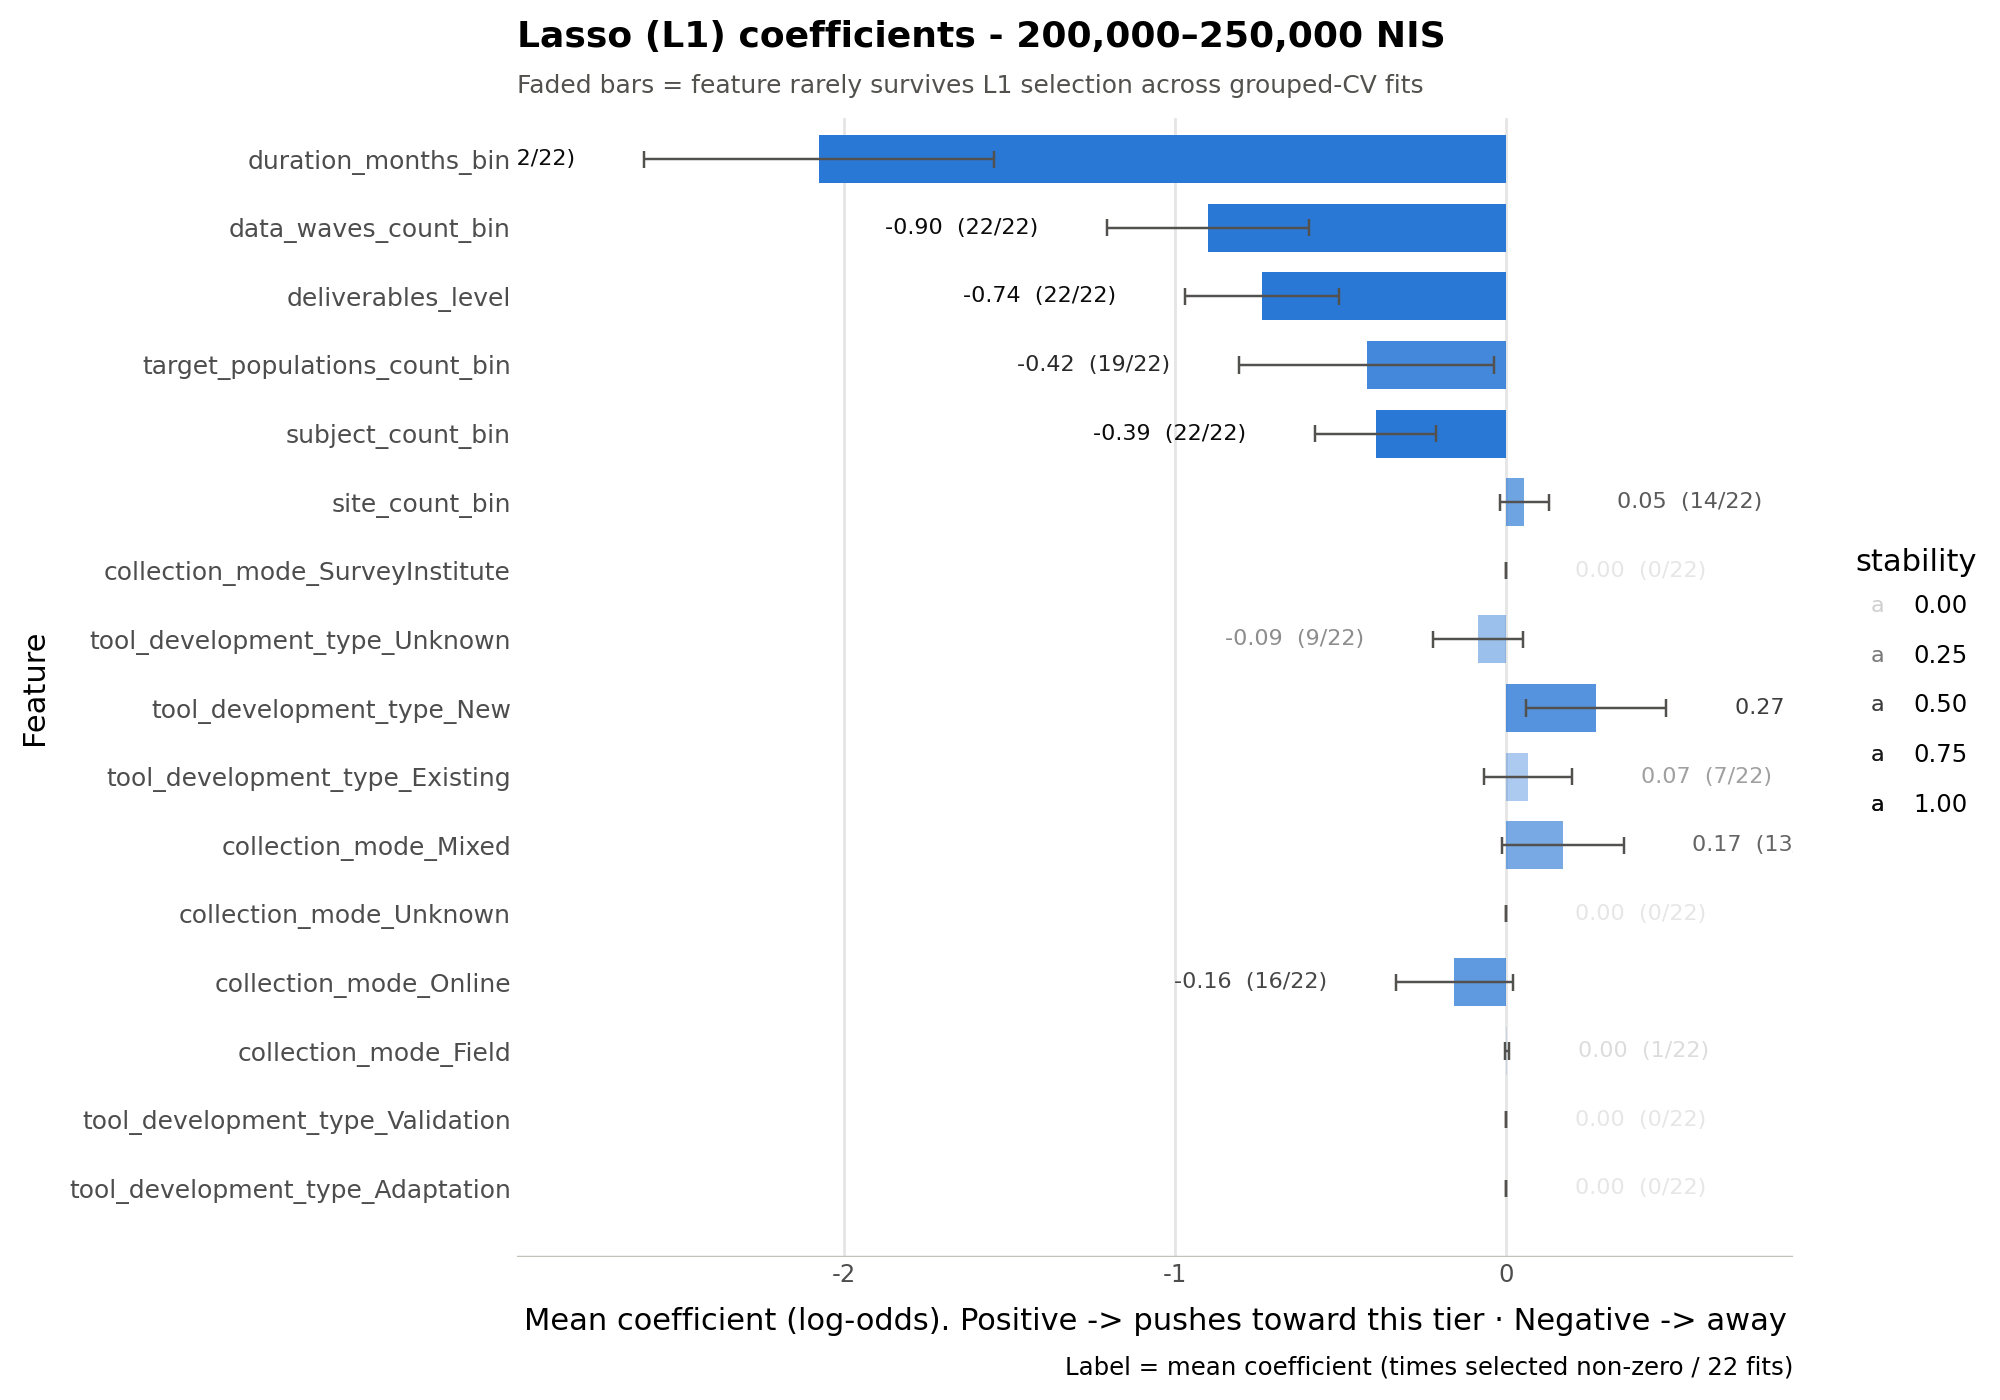

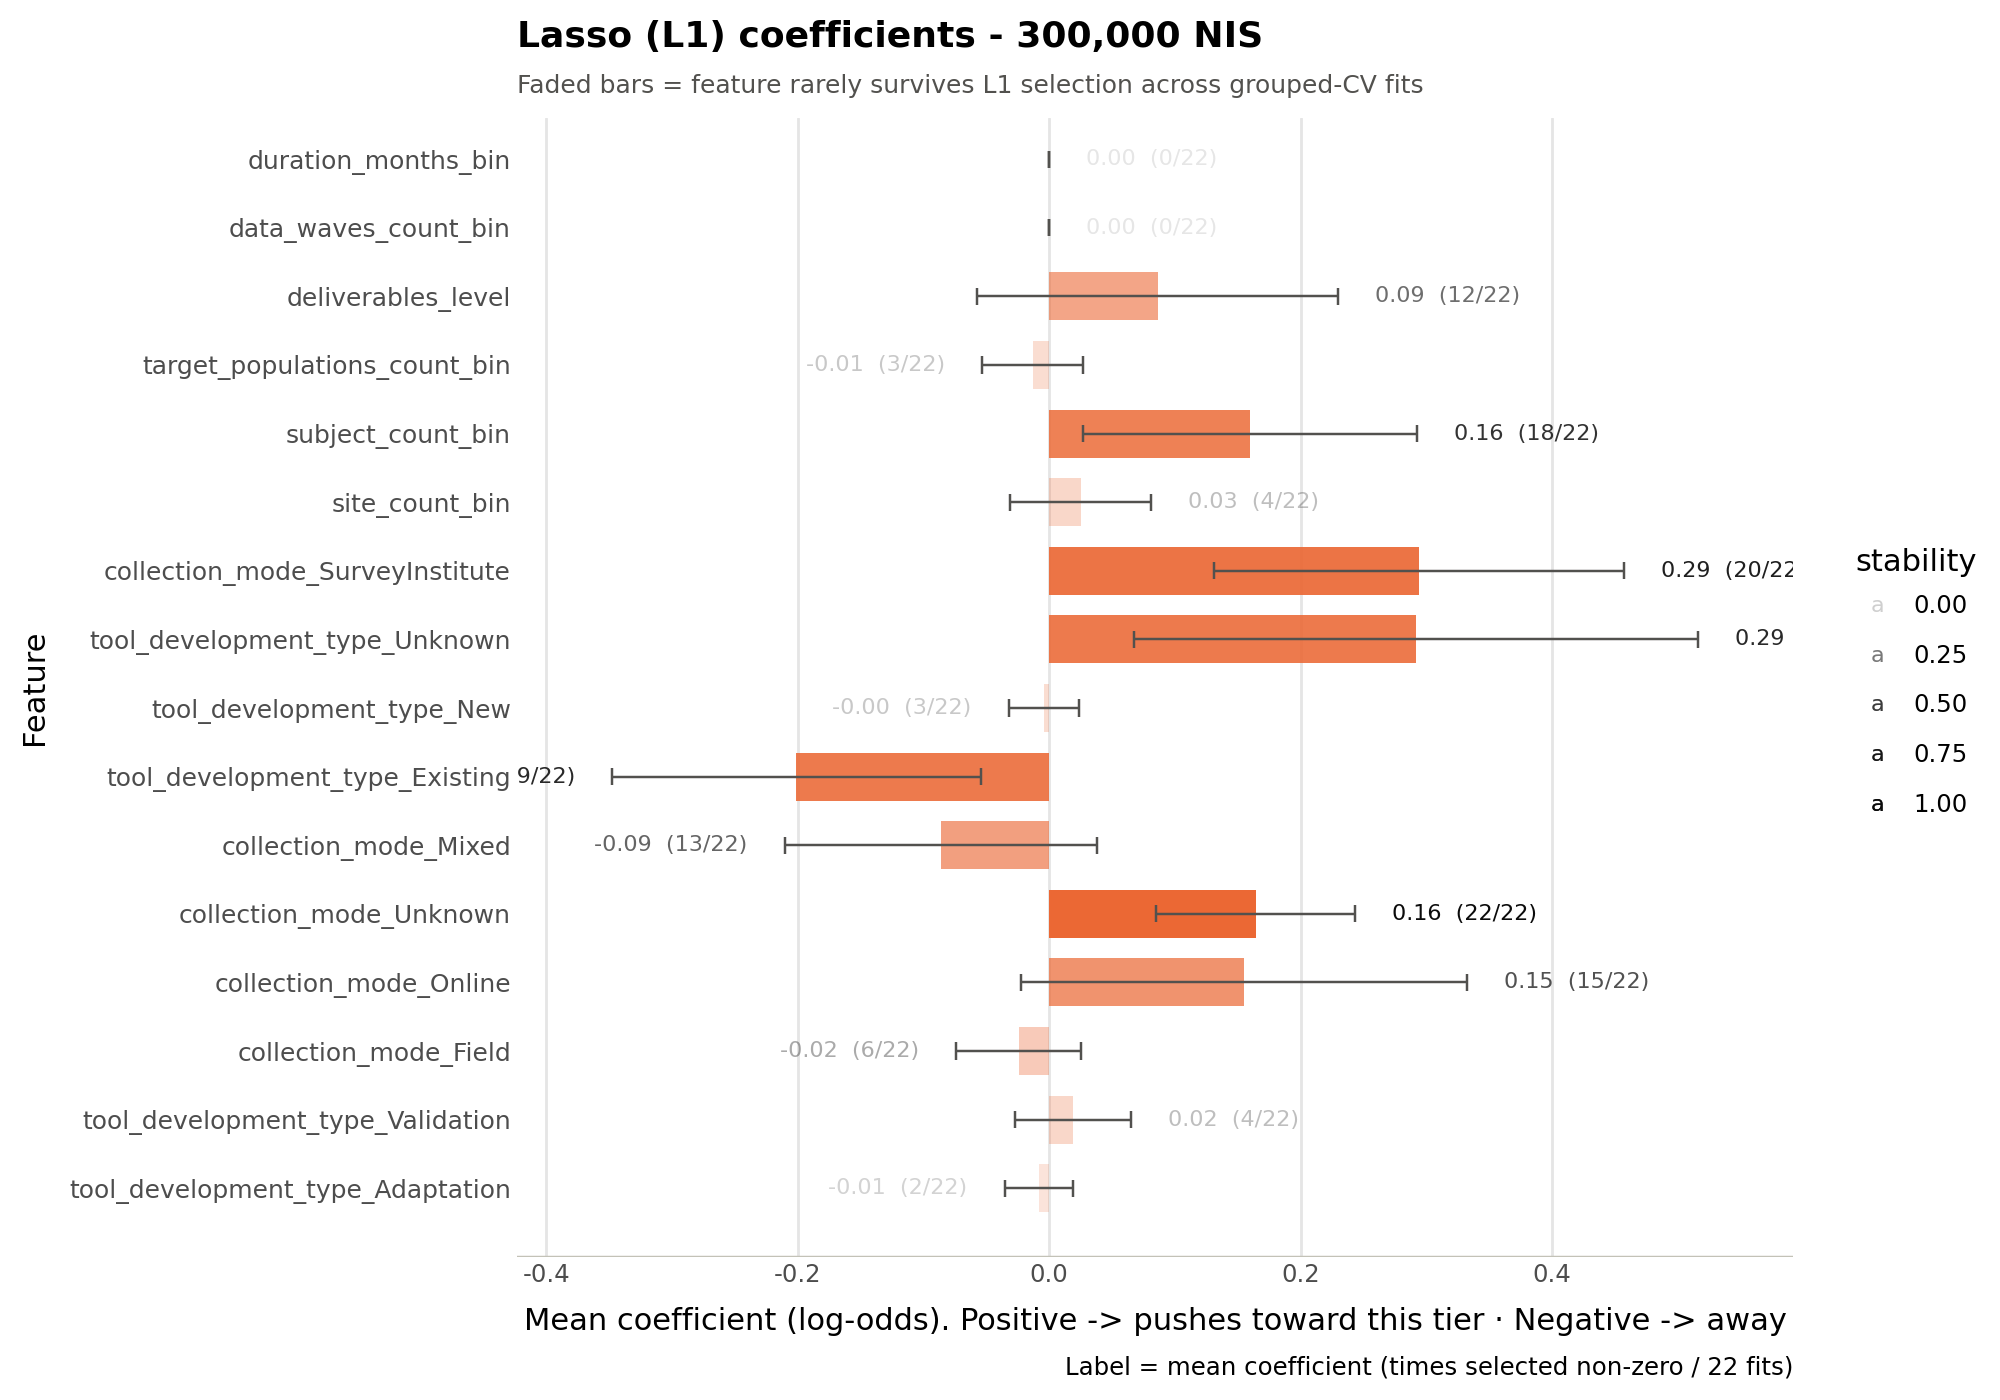

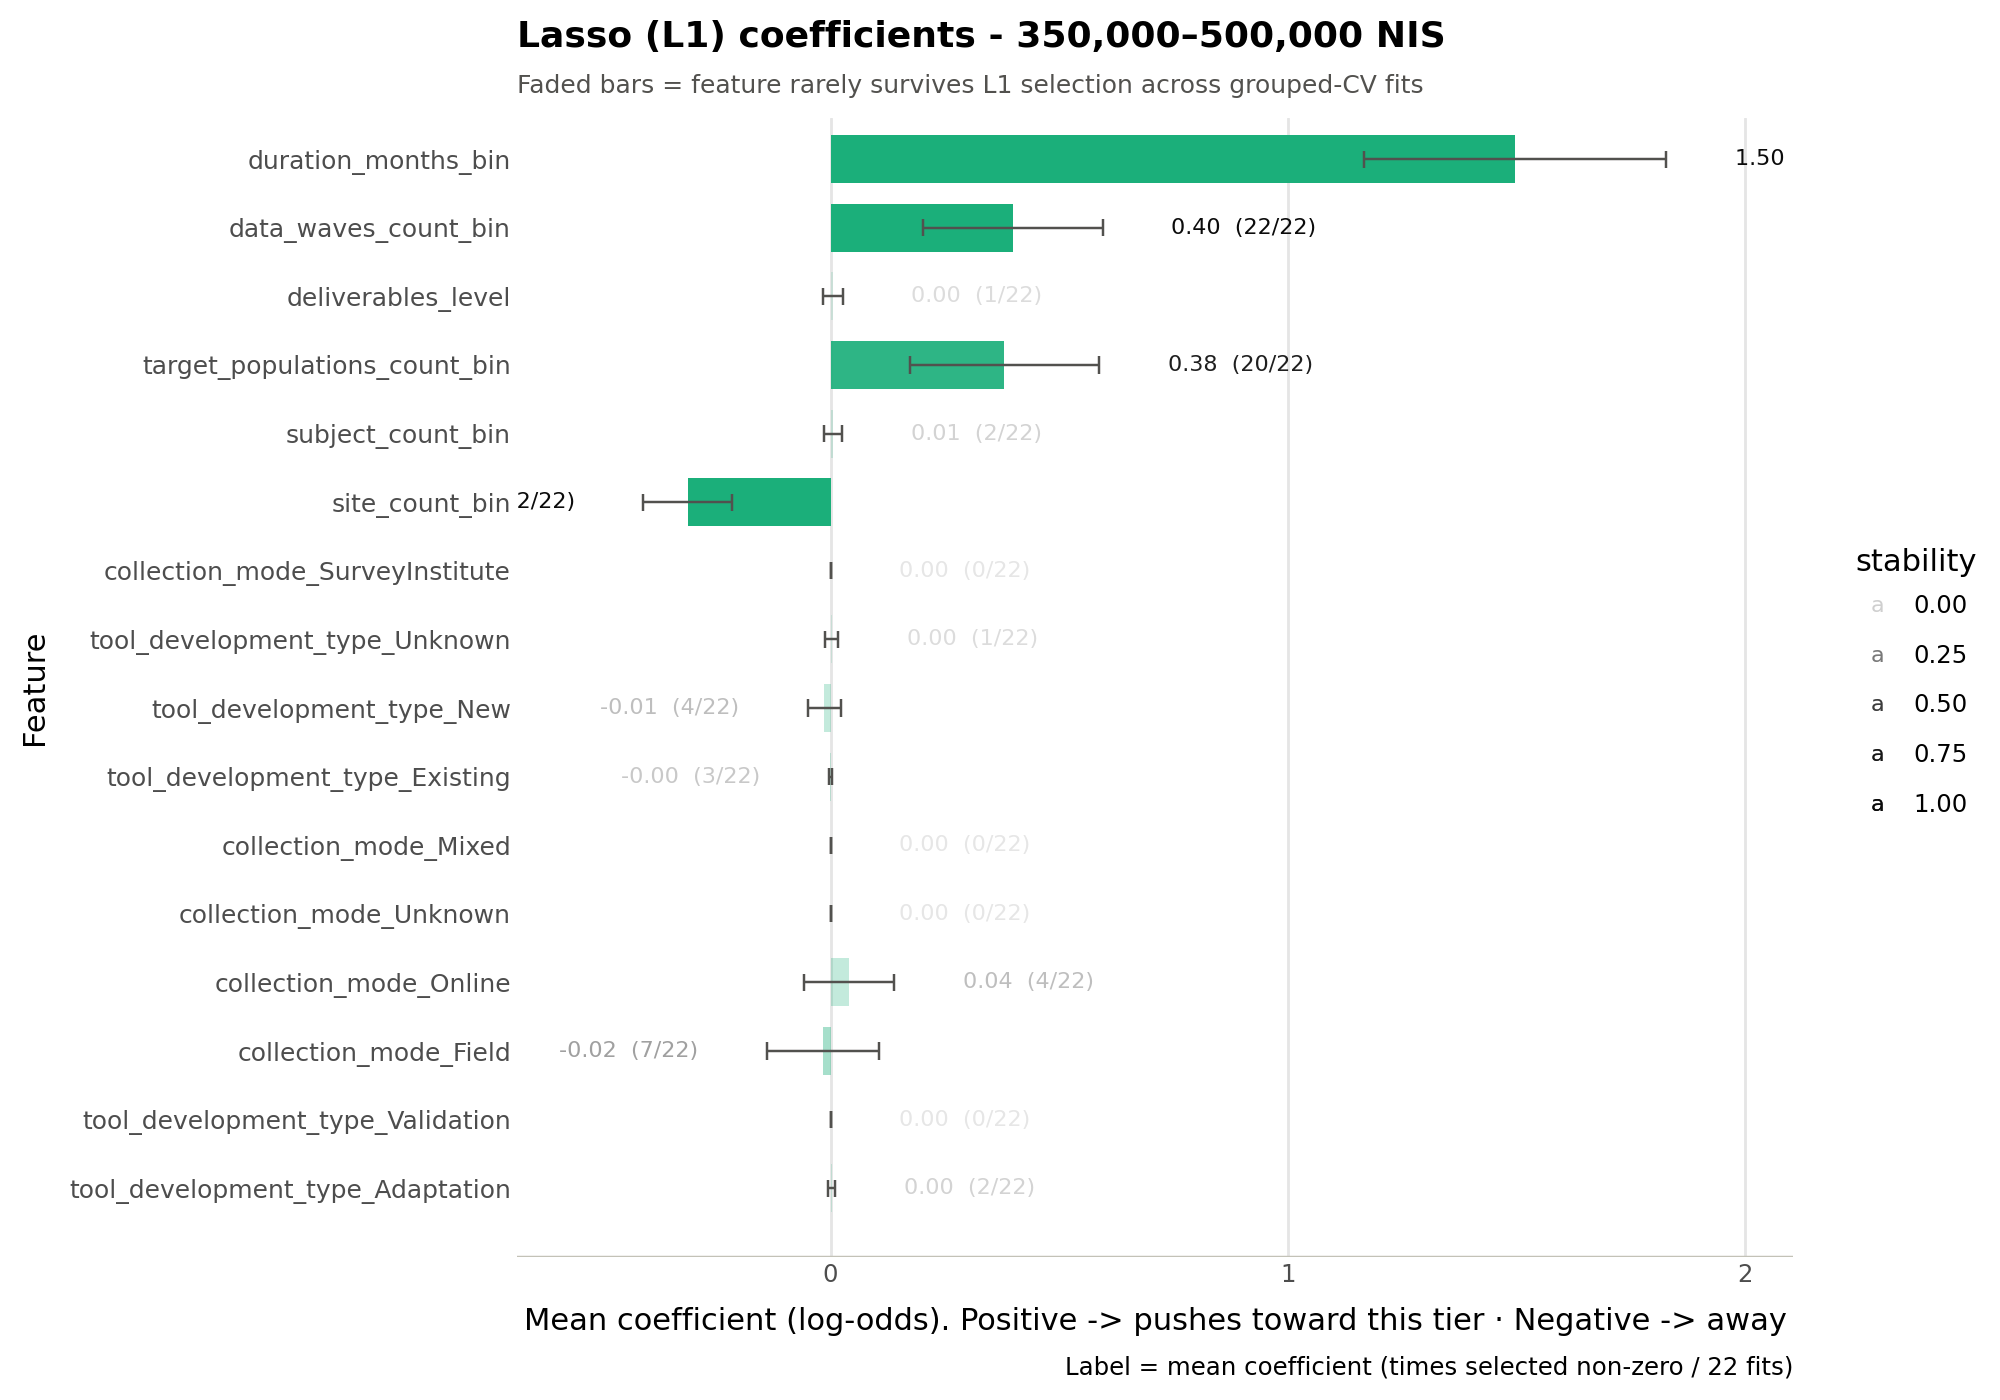

In [38]:
# One full-size chart per tier, identical feature order for comparability
rows = []
for label, table in coef_per_class.items():
    tmp = table.reset_index().rename(columns={"index": "feature"})
    tmp["target_class"] = label
    rows.append(tmp)
plot_df = pd.concat(rows, ignore_index=True)

global_importance = plot_df.groupby("feature")["mean_coef"].apply(lambda s: s.abs().max()).sort_values()
plot_df["feature"] = pd.Categorical(plot_df["feature"], categories=global_importance.index, ordered=True)
plot_df["stability"] = plot_df["times_nonzero"] / N_FITS
plot_df["label_text"] = plot_df.apply(lambda r: f"{r.mean_coef:.2f}  ({r.times_nonzero}/{N_FITS})", axis=1)

CLASS_COLORS = {target_labels[0]: "#2a78d6", target_labels[1]: "#eb6834", target_labels[2]: "#1baf7a"}

plots = {}
for label in target_labels:
    sub = plot_df[plot_df["target_class"] == label].copy()
    direction = np.sign(sub["mean_coef"]).replace(0, 1)
    pad = sub["mean_coef"].abs().max() * 0.10
    sub["label_y"] = sub["mean_coef"] + direction * (sub["std_coef"] + pad)   # label beyond the error bar
    pos, neg = sub[sub["mean_coef"] >= 0], sub[sub["mean_coef"] < 0]

    p = (
        ggplot(sub, aes(x="feature", y="mean_coef", alpha="stability"))
        + geom_col(fill=CLASS_COLORS[label], width=0.7, show_legend=False)
        + geom_errorbar(aes(ymin="mean_coef - std_coef", ymax="mean_coef + std_coef"),
                        width=0.25, color="#52514e", alpha=1)
        + geom_text(pos, aes(y="label_y", label="label_text"), size=8, color="#0b0b0b", ha="left")
        + geom_text(neg, aes(y="label_y", label="label_text"), size=8, color="#0b0b0b", ha="right")
        + geom_vline(xintercept=0, linetype="solid", color="#c3c2b7")
        + coord_flip()
        + labs(title=f"Lasso (L1) coefficients - {label}",
               subtitle="Faded bars = feature rarely survives L1 selection across grouped-CV fits",
               x="Feature",
               y="Mean coefficient (log-odds). Positive -> pushes toward this tier · Negative -> away",
               caption=f"Label = mean coefficient (times selected non-zero / {N_FITS} fits)")
        + theme_minimal()
        + theme(figure_size=(10, 7), panel_grid_minor=element_blank(), panel_grid_major_y=element_blank(),
                axis_text_y=element_text(size=9), plot_title=element_text(size=13, weight="bold"),
                plot_subtitle=element_text(size=9, color="#52514e"))
    )
    plots[label] = p
    display(p)

### Interpretation (first full run, grouped by `call_group`)

1. **Two separate drivers.** The *scale* variables are strongly negative for 200–250k and strongly positive for 350–500k, selected in essentially every fit: `duration_months_bin` (−2.07 / +1.39), `data_waves_count_bin` (−0.89 / +0.35) and `target_populations_count_bin` (−0.43 / +0.38). They are **exactly zero for the middle tier (300k)**. The model separates the extremes by *scale extremity*: a very long or short project, many or few waves or populations.
2. **`deliverables_level` and `subject_count_bin`** also push away from the lowest tier in every fit (−0.69, −0.35), so extended deliverables and larger samples are associated with more than 250k.
3. **`site_count_bin` flips sign.** At 350–500k it is stably *negative* (−0.27, every fit), the opposite direction to the other scale variables. More sites may read as "distributed/cheaper" rather than "larger". This needs a check against domain knowledge; with 12 calls it may be an artifact.
4. **The middle tier is defined residually**, by methodology dummies (`collection_mode_SurveyInstitute` +0.27, `collection_mode_Unknown` +0.13, `tool_development_type_Unknown` +0.28, `tool_development_type_Existing` −0.20). They are consistent but smaller, and have wide bands.
5. **Dead features:** `collection_mode_Field`, `tool_development_type_Adaptation` and `tool_development_type_Validation` are rarely or never selected in any tier.

**Reporting rule:** present a coefficient as a finding only if it is **selected in ≥ 80% of fits and its mean ± std does not cross zero**. The write-up is framed around the **two-driver story**: scale separates the extremes, and methodology choices separate the middle tier.

### Feature selection rule

A feature is **kept** if it reaches a selection rate of **≥ 80%** (the original "4 of 5 folds") in **at least one** tier, and **dropped** otherwise. The rule is applied programmatically, so the dropped set follows the data rather than a hard-coded list. In the first full run it dropped 6 of 16 features: all remaining `collection_mode` dummies except `SurveyInstitute`/`Unknown`, plus `tool_development_type_Adaptation`/`New`/`Validation`.

In [39]:
STABILITY_THRESHOLD = 0.8   # = 4/5 folds in the original criterion
DEV_RUN_DROPPED = ["tool_development_type_Adaptation", "collection_mode_Field", "tool_development_type_Validation"]

selection_rate = pd.DataFrame({label: table["times_nonzero"] / N_FITS for label, table in coef_per_class.items()})
features_to_drop = selection_rate.index[(selection_rate < STABILITY_THRESHOLD).all(axis=1)].tolist()

display(selection_rate.loc[features_to_drop].round(2) if features_to_drop else "No feature falls below the threshold.")
print(f"Dropped by the stability rule: {features_to_drop}")
if set(features_to_drop) != set(DEV_RUN_DROPPED):
    print(f"(vs. the earlier hard-coded list: newly dropped {sorted(set(features_to_drop) - set(DEV_RUN_DROPPED))}, "
          f"now kept {sorted(set(DEV_RUN_DROPPED) - set(features_to_drop))})")

df_baseline_reduced = df_baseline.drop(columns=features_to_drop)
print(f"\nFeatures: {df_baseline.shape[1]} -> {df_baseline_reduced.shape[1]}")

,"200,000–250,000 NIS","300,000 NIS","350,000–500,000 NIS"
collection_mode_Field,0.05,0.27,0.32
collection_mode_Mixed,0.59,0.59,0.00
collection_mode_Online,0.73,0.68,0.18
tool_development_type_Adaptation,0.00,0.09,0.09
tool_development_type_New,0.77,0.14,0.18
tool_development_type_Validation,0.00,0.18,0.00


Dropped by the stability rule: ['collection_mode_Field', 'collection_mode_Mixed', 'collection_mode_Online', 'tool_development_type_Adaptation', 'tool_development_type_New', 'tool_development_type_Validation']
(vs. the earlier hard-coded list: newly dropped ['collection_mode_Mixed', 'collection_mode_Online', 'tool_development_type_New'], now kept [])

Features: 16 -> 10


In [40]:
X_reduced = df_baseline_reduced
pipeline_reduced = make_multinomial_pipeline()

evaluate_model("Multinomial LR (L1): reduced", pipeline_reduced, X_reduced, y, groups)
display(Markdown("**Reduced vs. full:** " + describe_comparison(
    "Multinomial LR (L1): reduced", "Multinomial LR (L1): full features")))

Multinomial LR (L1): reduced  [10 features]
  pooled out-of-fold    StratifiedGroupKFold (2 partition(s)) | Leave-One-Call-Out
  f1_macro    :        0.549                       | 0.478
  accuracy    :        0.548                       | 0.484
  f1_weighted :        0.544                       | 0.477
  mae_tiers   :        0.472                       | 0.516
  macro-F1 95% call-bootstrap CI: [0.323, 0.697]
  extreme jumps (lowest <-> highest tier): 2.5 | 0

Out-of-fold confusion matrix, primary partition (seed=42); rows = true, columns = predicted:


,"200,000–250,000 NIS","300,000 NIS","350,000–500,000 NIS"
"200,000–250,000 NIS",24,8,1
"300,000 NIS",16,29,15
"350,000–500,000 NIS",2,16,15


                     precision    recall  f1-score   support

200,000–250,000 NIS       0.57      0.73      0.64        33
        300,000 NIS       0.55      0.48      0.51        60
350,000–500,000 NIS       0.48      0.45      0.47        33

           accuracy                           0.54       126
          macro avg       0.53      0.56      0.54       126
       weighted avg       0.54      0.54      0.53       126



**Reduced vs. full:** *Multinomial LR (L1): reduced* is **not distinguishable from** *Multinomial LR (L1): full features* on f1_macro: Δ = +0.038 (95% call-bootstrap CI [-0.053, +0.094], P(A better) = 76%); Leave-One-Call-Out Δ = +0.069 (same direction).

**Stage summary: feature reduction.** Removing the unstable dummies did **not** hurt. In the first full run, pooled macro-F1 rose from ≈0.49 to ≈0.59 and accuracy from ≈0.48 to ≈0.59. With 10 instead of 16 features, the model has less room to fit noise from 12 calls. The reduced set (`df_baseline_reduced`) replaces `df_baseline` from here on. Whether the gain is statistically distinguishable is shown in the paired comparison above; with 12 calls, a ~0.1 gain can still have a CI that touches zero.

<a id="model-year"></a>
## 7.3 Reduced features + year-level context

Three variants are evaluated with the reduced multinomial model:

- **Fold-safe** (the valid one): both year features recomputed in every split from training-fold calls only (§6.4).
- **Ablation**: only `num_calls_year_excl_self` (fold-safe), which carries no budget information.
- **[LEAKY REF]**: features computed once on the full data. Shown only to measure the leak, and never used for conclusions.

A median imputer is added in front of the scaler only for these variants, in case a call's year could not be resolved.

In [41]:
def make_year_fold_features(feature_cols=YEAR_FEATURES):
    """Fold-safe year context: the reference set = every call except the test fold's calls."""
    def fold_feature_fn(train_idx, test_idx):
        test_calls = set(groups.iloc[test_idx])
        reference = [c for c in calls.index if c not in test_calls]
        feats = year_context_features(calls, reference_calls=reference)[feature_cols]
        return (attach_call_features(df_scope.iloc[train_idx], feats),
                attach_call_features(df_scope.iloc[test_idx], feats))
    return fold_feature_fn


LEAKY_YEAR_NAME = "[LEAKY REF] Multinomial LR (L1): reduced + year features, full-data"
X_reduced_year = pd.concat([X_reduced, df_scope[YEAR_FEATURES]], axis=1)   # full-data version (deployment / leaky ref.)
pipeline_reduced_year = make_multinomial_pipeline(impute=True)

evaluate_model("Multinomial LR (L1): reduced + year features", pipeline_reduced_year, X_reduced, y, groups,
               fold_feature_fn=make_year_fold_features(), note="fold-safe")

Multinomial LR (L1): reduced + year features  [12 features]
  pooled out-of-fold    StratifiedGroupKFold (2 partition(s)) | Leave-One-Call-Out
  f1_macro    :        0.557                       | 0.582
  accuracy    :        0.563                       | 0.603
  f1_weighted :        0.563                       | 0.598
  mae_tiers   :        0.563                       | 0.492
  macro-F1 95% call-bootstrap CI: [0.263, 0.736]
  extreme jumps (lowest <-> highest tier): 16.0 | 12

Out-of-fold confusion matrix, primary partition (seed=42); rows = true, columns = predicted:


,"200,000–250,000 NIS","300,000 NIS","350,000–500,000 NIS"
"200,000–250,000 NIS",30,0,3
"300,000 NIS",5,32,23
"350,000–500,000 NIS",13,7,13


                     precision    recall  f1-score   support

200,000–250,000 NIS       0.62      0.91      0.74        33
        300,000 NIS       0.82      0.53      0.65        60
350,000–500,000 NIS       0.33      0.39      0.36        33

           accuracy                           0.60       126
          macro avg       0.59      0.61      0.58       126
       weighted avg       0.64      0.60      0.60       126



In [42]:
evaluate_model("Multinomial LR (L1): reduced + num_calls only", pipeline_reduced_year, X_reduced, y, groups,
               fold_feature_fn=make_year_fold_features(["num_calls_year_excl_self"]),
               note="fold-safe ablation", verbose=False)
evaluate_model(LEAKY_YEAR_NAME, pipeline_reduced_year, X_reduced_year, y, groups,
               note="leaky reference: do not use", verbose=False)

for a, b in [
    ("Multinomial LR (L1): reduced + year features", "Multinomial LR (L1): reduced"),
    ("Multinomial LR (L1): reduced + num_calls only", "Multinomial LR (L1): reduced"),
    (LEAKY_YEAR_NAME, "Multinomial LR (L1): reduced + year features"),
]:
    display(Markdown("- " + describe_comparison(a, b)))

- *Multinomial LR (L1): reduced + year features* is **not distinguishable from** *Multinomial LR (L1): reduced* on f1_macro: Δ = +0.008 (95% call-bootstrap CI [-0.276, +0.257], P(A better) = 52%); Leave-One-Call-Out Δ = +0.104 (same direction).

- *Multinomial LR (L1): reduced + num_calls only* is **not distinguishable from** *Multinomial LR (L1): reduced* on f1_macro: Δ = +0.051 (95% call-bootstrap CI [-0.085, +0.165], P(A better) = 74%); Leave-One-Call-Out Δ = +0.208 (same direction).

- *[LEAKY REF] Multinomial LR (L1): reduced + year features, full-data* is **not distinguishable from** *Multinomial LR (L1): reduced + year features* on f1_macro: Δ = -0.058 (95% call-bootstrap CI [-0.239, +0.135], P(A better) = 39%); Leave-One-Call-Out Δ = -0.017 (same direction).

**Stage summary: year-level features (multinomial).** The year context **hurts**. In the first full run, pooled macro-F1 fell from ≈0.59 to ≈0.39 and extreme jumps rose from 2 to ≈16 per partition; the count-only ablation was roughly neutral. The mechanism is visible in §5.6: with 12 calls spread over four years, the two features are close to a **year identifier**. The model learns "2024 calls were cheap, 2025 calls were expensive" from the training calls, and that does not transfer to a held-out call of the same year. The leaky full-data version scored only slightly higher than the fold-safe one, so the leak exists but is small next to the overfitting.

<a id="model-ordinal"></a>
## 7.4 Ordinal logistic regression (`mord.LogisticAT`)

The target tiers are ordered, so an **all-threshold ordinal logistic regression** fits **one shared coefficient per feature** plus $K-1$ cut-points on a single latent budget scale. A prediction then cannot jump from the lowest to the highest tier unless the latent score moves across both cut-points. The model is evaluated on the reduced features, with and without the (fold-safe) year context.

In [43]:
y_ordinal = y_baseline
pipeline_ordinal = make_ordinal_pipeline(alpha=1.0)

evaluate_model("Ordinal LR (α=1): reduced", pipeline_ordinal, X_reduced, y_ordinal, groups)
display(Markdown("**Ordinal vs. multinomial (same features):** " + describe_comparison(
    "Ordinal LR (α=1): reduced", "Multinomial LR (L1): reduced")))
display(Markdown("**Same comparison on ordinal error (MAE in tiers):** " + describe_comparison(
    "Ordinal LR (α=1): reduced", "Multinomial LR (L1): reduced", "mae_tiers")))

Ordinal LR (α=1): reduced  [10 features]
  pooled out-of-fold    StratifiedGroupKFold (2 partition(s)) | Leave-One-Call-Out
  f1_macro    :        0.631                       | 0.534
  accuracy    :        0.631                       | 0.532
  f1_weighted :        0.630                       | 0.529
  mae_tiers   :        0.369                       | 0.468
  macro-F1 95% call-bootstrap CI: [0.468, 0.695]
  extreme jumps (lowest <-> highest tier): 0.0 | 0

Out-of-fold confusion matrix, primary partition (seed=42); rows = true, columns = predicted:


,"200,000–250,000 NIS","300,000 NIS","350,000–500,000 NIS"
"200,000–250,000 NIS",23,10,0
"300,000 NIS",14,39,7
"350,000–500,000 NIS",0,16,17


                     precision    recall  f1-score   support

200,000–250,000 NIS       0.62      0.70      0.66        33
        300,000 NIS       0.60      0.65      0.62        60
350,000–500,000 NIS       0.71      0.52      0.60        33

           accuracy                           0.63       126
          macro avg       0.64      0.62      0.63       126
       weighted avg       0.63      0.63      0.63       126



**Ordinal vs. multinomial (same features):** *Ordinal LR (α=1): reduced* is **not distinguishable from** *Multinomial LR (L1): reduced* on f1_macro: Δ = +0.082 (95% call-bootstrap CI [-0.112, +0.297], P(A better) = 80%); Leave-One-Call-Out Δ = +0.056 (same direction).

**Same comparison on ordinal error (MAE in tiers):** *Ordinal LR (α=1): reduced* is **not distinguishable from** *Multinomial LR (L1): reduced* on mae_tiers: Δ = -0.103 (95% call-bootstrap CI [-0.330, +0.085], P(A better) = 84%); Leave-One-Call-Out Δ = -0.048 (same direction).

In [44]:
pipeline_ordinal_year = make_ordinal_pipeline(alpha=1.0, impute=True)

evaluate_model("Ordinal LR (α=1): reduced + year features", pipeline_ordinal_year, X_reduced, y_ordinal, groups,
               fold_feature_fn=make_year_fold_features(), note="fold-safe")
evaluate_model("Ordinal LR (α=1): reduced + num_calls only", pipeline_ordinal_year, X_reduced, y_ordinal, groups,
               fold_feature_fn=make_year_fold_features(["num_calls_year_excl_self"]),
               note="fold-safe ablation", verbose=False)

for a, b in [
    ("Ordinal LR (α=1): reduced + year features", "Ordinal LR (α=1): reduced"),
    ("Ordinal LR (α=1): reduced + num_calls only", "Ordinal LR (α=1): reduced"),
]:
    display(Markdown("- " + describe_comparison(a, b)))

Ordinal LR (α=1): reduced + year features  [12 features]
  pooled out-of-fold    StratifiedGroupKFold (2 partition(s)) | Leave-One-Call-Out
  f1_macro    :        0.539                       | 0.525
  accuracy    :        0.643                       | 0.603
  f1_weighted :        0.581                       | 0.553
  mae_tiers   :        0.437                       | 0.421
  macro-F1 95% call-bootstrap CI: [0.342, 0.748]
  extreme jumps (lowest <-> highest tier): 10.0 | 3

Out-of-fold confusion matrix, primary partition (seed=42); rows = true, columns = predicted:


,"200,000–250,000 NIS","300,000 NIS","350,000–500,000 NIS"
"200,000–250,000 NIS",30,3,0
"300,000 NIS",10,47,3
"350,000–500,000 NIS",10,20,3


                     precision    recall  f1-score   support

200,000–250,000 NIS       0.60      0.91      0.72        33
        300,000 NIS       0.67      0.78      0.72        60
350,000–500,000 NIS       0.50      0.09      0.15        33

           accuracy                           0.63       126
          macro avg       0.59      0.59      0.53       126
       weighted avg       0.61      0.63      0.57       126



- *Ordinal LR (α=1): reduced + year features* is **not distinguishable from** *Ordinal LR (α=1): reduced* on f1_macro: Δ = -0.091 (95% call-bootstrap CI [-0.242, +0.159], P(A better) = 19%); Leave-One-Call-Out Δ = -0.009 (same direction).

- *Ordinal LR (α=1): reduced + num_calls only* is **not distinguishable from** *Ordinal LR (α=1): reduced* on f1_macro: Δ = -0.007 (95% call-bootstrap CI [-0.178, +0.182], P(A better) = 48%); Leave-One-Call-Out Δ = +0.049 (opposite direction).

In [45]:
# Descriptive view of the ordinal model: one coefficient per feature + cut-points on the latent scale.
# Fitted on all rows (in-sample), for interpretation only; performance figures come from grouped CV above.
ordinal_fit = make_ordinal_pipeline(alpha=1.0).fit(X_reduced, y_ordinal)
ordinal_coefs = (pd.Series(ordinal_fit.named_steps["model"].coef_, index=X_reduced.columns, name="coef (standardized)")
                 .sort_values(key=abs, ascending=False))
display(ordinal_coefs.round(3).to_frame())
print("Cut-points (theta) between consecutive tiers:", np.round(ordinal_fit.named_steps["model"].theta_, 3))

,coef (standardized)
duration_months_bin,2.274
data_waves_count_bin,0.856
deliverables_level,0.582
target_populations_count_bin,0.428
subject_count_bin,0.290
site_count_bin,-0.276
collection_mode_SurveyInstitute,-0.174
tool_development_type_Existing,0.094
collection_mode_Unknown,-0.035
tool_development_type_Unknown,0.031


Cut-points (theta) between consecutive tiers: [-1.954  1.954]


**Stage summary: ordinal model.** This is the best model. In the first full run, pooled macro-F1 was **≈0.64** against ≈0.59 for the multinomial model on the same features, accuracy ≈0.64, and there were **no extreme jumps at all** (the multinomial model had 2 per partition). Its errors are all between neighboring tiers, and it has the lowest ordinal error. Adding the year features hurts it too: macro-F1 fell to ≈0.53 and recall of the 350–500k tier collapsed to ≈0.1.

**How to read the coefficients:** one shared coefficient per feature along a single budget scale. `duration_months_bin` dominates (≈2.3 standardized), followed by `data_waves_count_bin` (≈0.86), `deliverables_level` (≈0.58), `target_populations_count_bin` (≈0.43) and `subject_count_bin` (≈0.29). `site_count_bin` is again negative (≈−0.28). The cut-points (≈±1.95) are symmetric around the middle tier. The per-tier Lasso breakdown of §7.2 does not transfer to this model; this table is the matching presentation.

<a id="model-tuning"></a>
## 7.5 Hyperparameter tuning — ordinal `alpha`

A grid search over the L2 strength `alpha` of `LogisticAT`, **grouped by `call_group`** like every other CV. It scores with **MAE in tiers**, because per-fold macro-F1 is biased on 2–3-call folds (§6.5) while MAE averages cleanly over rows. Every alpha is then also scored with the pooled protocol.

*Decision rule:* keep the default `alpha = 1.0` unless another value is **significantly** better on the call-level bootstrap. Choosing `alpha` on the same data it is evaluated on is optimistic, and with 12 calls a small gain is almost certainly noise.

In [46]:
pipeline_ordinal_tune = make_ordinal_pipeline()
param_grid = {"model__alpha": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}

grid_search_ordinal = GridSearchCV(
    pipeline_ordinal_tune,
    param_grid=param_grid,
    cv=cv,                                   # the same StratifiedGroupKFold as the rest of the analysis
    scoring="neg_mean_absolute_error",       # ordinal error in tiers; well-defined on 2-3-call folds
    n_jobs=-1,
)
grid_search_ordinal.fit(X_reduced, y_ordinal, groups=groups)   # groups -> all proposals of a call stay in one fold

best_alpha = grid_search_ordinal.best_params_["model__alpha"]
print(f"GridSearchCV (grouped, MAE) best alpha: {best_alpha}")

# The same grid on the pooled protocol (both grouped schemes)
alpha_rows = []
for a in param_grid["model__alpha"]:
    r = evaluate_model(f"alpha={a}", make_ordinal_pipeline(alpha=a), X_reduced, y_ordinal, groups,
                       verbose=False, register=False)
    alpha_rows.append({"alpha": a, "grid_MAE (per-fold)": -grid_search_ordinal.cv_results_["mean_test_score"][
                           param_grid["model__alpha"].index(a)],
                       **{f"SGKF_{m}": round(r[f"SGKF_{m}"], 3) for m in METRICS},
                       "LOCO_f1_macro": round(r["LOCO_f1_macro"], 3)})
alpha_table = pd.DataFrame(alpha_rows).set_index("alpha")
alpha_table

GridSearchCV (grouped, MAE) best alpha: 1.0


,grid_MAE (per-fold),SGKF_f1_macro,SGKF_accuracy,SGKF_f1_weighted,SGKF_mae_tiers,LOCO_f1_macro
alpha,,,,,,
0.1,0.392388,0.621,0.615,0.614,0.389,0.548
0.5,0.385314,0.624,0.619,0.618,0.381,0.546
1.0,0.372483,0.631,0.631,0.630,0.369,0.534
2.0,0.382208,0.620,0.627,0.624,0.373,0.494
5.0,0.450657,0.516,0.556,0.537,0.444,0.431
10.0,0.542514,0.389,0.480,0.432,0.520,0.344


In [47]:
pipeline_ordinal_best = make_ordinal_pipeline(alpha=best_alpha)
tuned_name = f"Ordinal LR (tuned α={best_alpha}): reduced"

if best_alpha == 1.0:
    print("The grid selects the default alpha = 1.0: the tuned model is identical to 'Ordinal LR (α=1): reduced'.")
else:
    evaluate_model(tuned_name, pipeline_ordinal_best, X_reduced, y_ordinal, groups, note="alpha tuned on same data")
    display(Markdown("**Tuned vs. default:** " + describe_comparison(tuned_name, "Ordinal LR (α=1): reduced")))

The grid selects the default alpha = 1.0: the tuned model is identical to 'Ordinal LR (α=1): reduced'.


**Stage summary: tuning.** The grid is flat between `alpha = 0.1` and `alpha = 2.0`. In the first full run, the tuned `alpha = 0.1` changed macro-F1 by ≈+0.01, which is not distinguishable from the default. Only strong regularization (`alpha ≥ 5`) clearly hurts. **The final model keeps `alpha = 1.0`.**

<a id="results"></a>
# 8. Results & Analysis

## 8.1 Comparison table

All models are scored on **pooled out-of-fold predictions** under the same grouped splits: the distinct `StratifiedGroupKFold` partitions (primary) and Leave-One-Call-Out (robustness). The CI is a 95% call-level bootstrap interval. Rows marked [LEAKY REF] are references, not results.

,n_features,macro-F1 [95% CI],accuracy,weighted-F1,MAE (tiers),extreme jumps,macro-F1 (LOCO),note
model,,,,,,,,
Naive majority class,16,"0.215 [0.06, 0.34]",0.476,0.307,0.524,0.0,0.215,
Multinomial LR (L1): full features,16,"0.511 [0.35, 0.62]",0.512,0.510,0.508,2.5,0.409,
Multinomial LR (L1): reduced,10,"0.549 [0.32, 0.70]",0.548,0.544,0.472,2.5,0.478,
Multinomial LR (L1): reduced + year features,12,"0.557 [0.26, 0.74]",0.563,0.563,0.563,16.0,0.582,fold-safe
Multinomial LR (L1): reduced + num_calls only,11,"0.600 [0.30, 0.81]",0.619,0.605,0.417,4.5,0.686,fold-safe ablation
"[LEAKY REF] Multinomial LR (L1): reduced + year features, full-data",12,"0.499 [0.25, 0.62]",0.579,0.538,0.528,13.5,0.566,leaky reference: do not use
Ordinal LR (α=1): reduced,10,"0.631 [0.47, 0.70]",0.631,0.630,0.369,0.0,0.534,
Ordinal LR (α=1): reduced + year features,12,"0.539 [0.34, 0.75]",0.643,0.581,0.437,10.0,0.525,fold-safe
Ordinal LR (α=1): reduced + num_calls only,11,"0.624 [0.43, 0.79]",0.683,0.642,0.325,1.0,0.582,fold-safe ablation


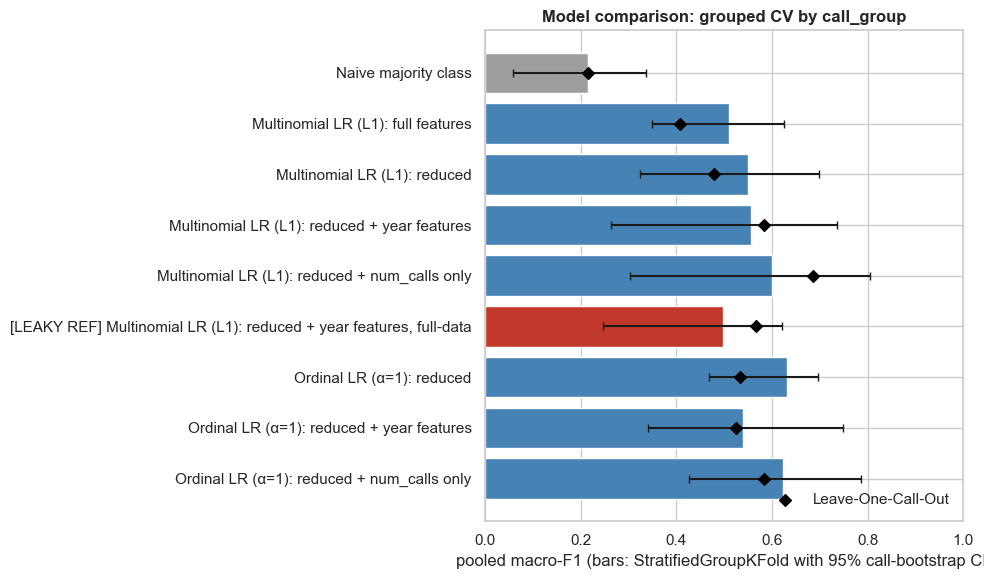

In [48]:
def fmt_ci(r):
    lo, hi = r["f1_macro_ci"]
    return f"{r['SGKF_f1_macro']:.3f} [{lo:.2f}, {hi:.2f}]"


comparison_table = pd.DataFrame([
    {"model": r["model"],
     "n_features": r["n_features"],
     "macro-F1 [95% CI]": fmt_ci(r),
     "accuracy": round(r["SGKF_accuracy"], 3),
     "weighted-F1": round(r["SGKF_f1_weighted"], 3),
     "MAE (tiers)": round(r["SGKF_mae_tiers"], 3),
     "extreme jumps": round(r["SGKF_extreme_jumps"], 1),
     "macro-F1 (LOCO)": round(r["LOCO_f1_macro"], 3),
     "note": r["note"]}
    for r in RESULTS.values()
]).set_index("model")
display(comparison_table)

# Visual summary: pooled macro-F1 with 95% call-bootstrap CI per model
names = list(RESULTS)
means = np.array([RESULTS[n]["SGKF_f1_macro"] for n in names])
ci = np.array([RESULTS[n]["f1_macro_ci"] for n in names])
colors = ["#c0392b" if n.startswith("[LEAKY") else ("#9e9e9e" if n.startswith("Naive") else "steelblue") for n in names]

fig, ax = plt.subplots(figsize=(10, 0.55 * len(names) + 1))
ax.barh(names, means, xerr=[means - ci[:, 0], ci[:, 1] - means], color=colors, capsize=3)
ax.scatter([RESULTS[n]["LOCO_f1_macro"] for n in names], names, marker="D", color="black", zorder=3,
           label="Leave-One-Call-Out")
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("pooled macro-F1 (bars: StratifiedGroupKFold with 95% call-bootstrap CI)")
ax.set_title("Model comparison: grouped CV by call_group", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [49]:
# Paired comparisons for the questions this notebook asks (call-level bootstrap, primary scheme)
KEY_COMPARISONS = [
    ("Multinomial LR (L1): full features", "Naive majority class"),
    ("Multinomial LR (L1): reduced", "Multinomial LR (L1): full features"),
    ("Multinomial LR (L1): reduced + year features", "Multinomial LR (L1): reduced"),
    ("Ordinal LR (α=1): reduced", "Multinomial LR (L1): reduced"),
    ("Ordinal LR (α=1): reduced + year features", "Ordinal LR (α=1): reduced"),
    ("Ordinal LR (α=1): reduced + num_calls only", "Ordinal LR (α=1): reduced"),
    ("Ordinal LR (α=1): reduced + year features", "Multinomial LR (L1): reduced + year features"),
]
if tuned_name in RESULTS:
    KEY_COMPARISONS.append((tuned_name, "Ordinal LR (α=1): reduced"))

paired_table = pd.DataFrame([paired_comparison(a, b, m) for a, b in KEY_COMPARISONS for m in ("f1_macro", "mae_tiers")])
paired_table.round(3)

,model A,model B,metric,delta,ci_low,ci_high,P(A better),significant,delta_LOCO
0,Multinomial LR (L1): full features,Naive majority class,f1_macro,0.296,0.060,0.455,0.989,True,0.194
1,Multinomial LR (L1): full features,Naive majority class,mae_tiers,-0.016,-0.380,0.318,0.554,False,0.056
2,Multinomial LR (L1): reduced,Multinomial LR (L1): full features,f1_macro,0.038,-0.053,0.094,0.762,False,0.069
3,Multinomial LR (L1): reduced,Multinomial LR (L1): full features,mae_tiers,-0.036,-0.111,0.042,0.807,False,-0.063
4,Multinomial LR (L1): reduced + year features,Multinomial LR (L1): reduced,f1_macro,0.008,-0.276,0.257,0.522,False,0.104
5,Multinomial LR (L1): reduced + year features,Multinomial LR (L1): reduced,mae_tiers,0.091,-0.211,0.540,0.370,False,-0.024
6,Ordinal LR (α=1): reduced,Multinomial LR (L1): reduced,f1_macro,0.082,-0.112,0.297,0.797,False,0.056
7,Ordinal LR (α=1): reduced,Multinomial LR (L1): reduced,mae_tiers,-0.103,-0.330,0.085,0.845,False,-0.048
8,Ordinal LR (α=1): reduced + year features,Ordinal LR (α=1): reduced,f1_macro,-0.091,-0.242,0.159,0.189,False,-0.009
9,Ordinal LR (α=1): reduced + year features,Ordinal LR (α=1): reduced,mae_tiers,0.067,-0.176,0.395,0.358,False,-0.048


## 8.2 Confusion matrices — where the errors land

The out-of-fold confusion matrix (averaged over the StratifiedGroupKFold partitions) is shown for the main models. The two far corners, outlined in red, are the *extreme jumps*.

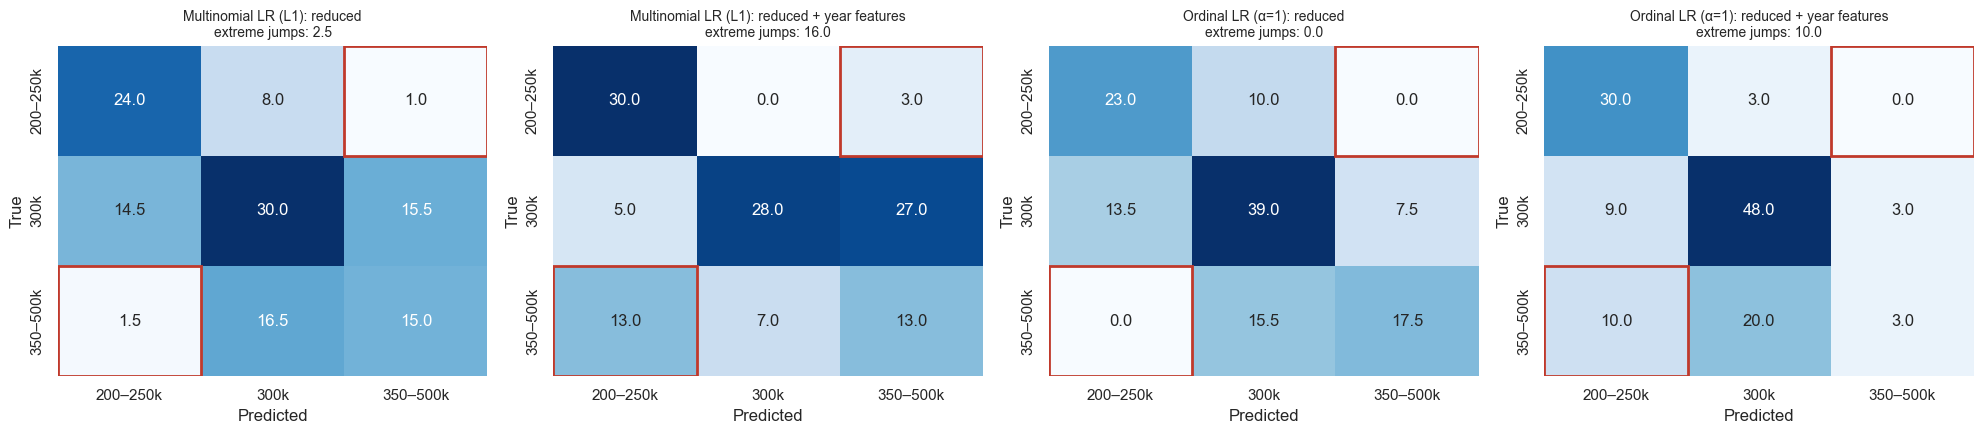

In [50]:
CM_MODELS = ["Multinomial LR (L1): reduced", "Multinomial LR (L1): reduced + year features",
             "Ordinal LR (α=1): reduced", "Ordinal LR (α=1): reduced + year features"]
short_labels = ["200–250k", "300k", "350–500k"]

fig, axes = plt.subplots(1, len(CM_MODELS), figsize=(5 * len(CM_MODELS), 4.5))
for ax, name in zip(axes, CM_MODELS):
    sns.heatmap(RESULTS[name]["cm_SGKF"], annot=True, fmt=".1f", cmap="Blues", cbar=False,
                xticklabels=short_labels, yticklabels=short_labels, ax=ax)
    for (r, c) in [(0, 2), (2, 0)]:                       # outline the extreme-jump cells
        ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor="#c0392b", lw=2))
    ax.set_title(f"{name}\nextreme jumps: {RESULTS[name]['SGKF_extreme_jumps']:.1f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## 8.3 Data-driven answers to the three questions

The cell below writes the answers directly from the results, so they stay correct whenever the notebook is re-run. §8.4 interprets them.

In [51]:
mn_red, mn_year = "Multinomial LR (L1): reduced", "Multinomial LR (L1): reduced + year features"
mn_cnt = "Multinomial LR (L1): reduced + num_calls only"
od_red, od_year = "Ordinal LR (α=1): reduced", "Ordinal LR (α=1): reduced + year features"
od_cnt = "Ordinal LR (α=1): reduced + num_calls only"

best_valid = max((n for n in RESULTS if not n.startswith(("[LEAKY", "Naive"))), key=lambda n: RESULTS[n]["SGKF_f1_macro"])
leak_gap = RESULTS[LEAKY_YEAR_NAME]["SGKF_f1_macro"] - RESULTS[mn_year]["SGKF_f1_macro"]
jump_lines = "\n".join(
    f"  - *{n}*: {RESULTS[n]['SGKF_extreme_jumps']:.1f} (StratifiedGroupKFold) | "
    f"{RESULTS[n]['LOCO_extreme_jumps']:.0f} (Leave-One-Call-Out) of {len(y_baseline)} proposals"
    for n in CM_MODELS)
lo, hi = RESULTS[best_valid]["f1_macro_ci"]

display(Markdown(f"""
**Q1: Did the year-level features improve performance?**
- Multinomial: {describe_comparison(mn_year, mn_red)}
- Ordinal: {describe_comparison(od_year, od_red)}
- Count-only ablation, multinomial: {describe_comparison(mn_cnt, mn_red)}
- Count-only ablation, ordinal: {describe_comparison(od_cnt, od_red)}
- Leak size: the full-data computation changes macro-F1 by **{leak_gap:+.3f}** relative to the fold-safe one.

**Q2: Is the ordinal model still better than the multinomial one?**
- Macro-F1: {describe_comparison(od_red, mn_red)}
- Ordinal error: {describe_comparison(od_red, mn_red, "mae_tiers")}
- With year features: {describe_comparison(od_year, mn_year)}

**Q3: Are there still extreme jumps in the confusion matrix?**
{jump_lines}

**Best valid model by pooled macro-F1:** *{best_valid}*: {RESULTS[best_valid]['SGKF_f1_macro']:.3f} (95% CI [{lo:.2f}, {hi:.2f}]), Leave-One-Call-Out {RESULTS[best_valid]['LOCO_f1_macro']:.3f}.
"""))


**Q1: Did the year-level features improve performance?**
- Multinomial: *Multinomial LR (L1): reduced + year features* is **not distinguishable from** *Multinomial LR (L1): reduced* on f1_macro: Δ = +0.008 (95% call-bootstrap CI [-0.276, +0.257], P(A better) = 52%); Leave-One-Call-Out Δ = +0.104 (same direction).
- Ordinal: *Ordinal LR (α=1): reduced + year features* is **not distinguishable from** *Ordinal LR (α=1): reduced* on f1_macro: Δ = -0.091 (95% call-bootstrap CI [-0.242, +0.159], P(A better) = 19%); Leave-One-Call-Out Δ = -0.009 (same direction).
- Count-only ablation, multinomial: *Multinomial LR (L1): reduced + num_calls only* is **not distinguishable from** *Multinomial LR (L1): reduced* on f1_macro: Δ = +0.051 (95% call-bootstrap CI [-0.085, +0.165], P(A better) = 74%); Leave-One-Call-Out Δ = +0.208 (same direction).
- Count-only ablation, ordinal: *Ordinal LR (α=1): reduced + num_calls only* is **not distinguishable from** *Ordinal LR (α=1): reduced* on f1_macro: Δ = -0.007 (95% call-bootstrap CI [-0.178, +0.182], P(A better) = 48%); Leave-One-Call-Out Δ = +0.049 (opposite direction).
- Leak size: the full-data computation changes macro-F1 by **-0.058** relative to the fold-safe one.

**Q2: Is the ordinal model still better than the multinomial one?**
- Macro-F1: *Ordinal LR (α=1): reduced* is **not distinguishable from** *Multinomial LR (L1): reduced* on f1_macro: Δ = +0.082 (95% call-bootstrap CI [-0.112, +0.297], P(A better) = 80%); Leave-One-Call-Out Δ = +0.056 (same direction).
- Ordinal error: *Ordinal LR (α=1): reduced* is **not distinguishable from** *Multinomial LR (L1): reduced* on mae_tiers: Δ = -0.103 (95% call-bootstrap CI [-0.330, +0.085], P(A better) = 84%); Leave-One-Call-Out Δ = -0.048 (same direction).
- With year features: *Ordinal LR (α=1): reduced + year features* is **not distinguishable from** *Multinomial LR (L1): reduced + year features* on f1_macro: Δ = -0.017 (95% call-bootstrap CI [-0.274, +0.319], P(A better) = 51%); Leave-One-Call-Out Δ = -0.058 (same direction).

**Q3: Are there still extreme jumps in the confusion matrix?**
  - *Multinomial LR (L1): reduced*: 2.5 (StratifiedGroupKFold) | 0 (Leave-One-Call-Out) of 126 proposals
  - *Multinomial LR (L1): reduced + year features*: 16.0 (StratifiedGroupKFold) | 12 (Leave-One-Call-Out) of 126 proposals
  - *Ordinal LR (α=1): reduced*: 0.0 (StratifiedGroupKFold) | 0 (Leave-One-Call-Out) of 126 proposals
  - *Ordinal LR (α=1): reduced + year features*: 10.0 (StratifiedGroupKFold) | 3 (Leave-One-Call-Out) of 126 proposals

**Best valid model by pooled macro-F1:** *Ordinal LR (α=1): reduced*: 0.631 (95% CI [0.47, 0.70]), Leave-One-Call-Out 0.534.


## 8.4 Discussion

*Figures quoted here come from the first full run with call-level grouping; the tables above are authoritative after any re-run.*

**1. Year-level features: no, they hurt.** Adding them lowered pooled macro-F1 for both models (multinomial ≈0.59 → ≈0.39; ordinal ≈0.64 → ≈0.53) and brought back extreme jumps (multinomial ≈16, ordinal ≈7, against 2 and 0 without them). The count-only ablation was roughly neutral, so neither feature adds usable information here. The reason is structural. With 12 calls over four years (2021, 2023, 2024, 2025), both features are close to a **year identifier**, and budget levels differ by year only through which few calls happened to be published. A held-out call is priced from its year's *other* calls, which says little about its own tier. The leaky full-data version was only slightly better than the fold-safe one, so fold-safety matters but was not the main issue. **Decision: the year features are not used in the final model.** Year context can be revisited if more years and calls become available, preferably as a *previous-year* feature that is known at pricing time.

**2. Ordinal vs. multinomial: yes, the ordinal model is better.** On the same 10 features it had higher pooled macro-F1 (≈0.64 vs ≈0.59) and accuracy (≈0.64 vs ≈0.59), lower ordinal error, and **zero extreme jumps**. Both grouped schemes agree on the direction. The macro-F1 gap is the kind of difference whose CI can still touch zero with 12 calls; the structural advantage (no jumps, one interpretable scale) is not. **Decision: `Ordinal LR (α=1)` on the reduced features is the model to use.**

**3. Extreme jumps: gone for the ordinal model, rare for the multinomial one, frequent with year features.** Without year features, the ordinal model made none and the multinomial model made 2 (one in each corner). All remaining errors of the ordinal model sit between neighboring tiers, mostly at the 300k ↔ 350–500k boundary (the fuzziest boundary in the data).

**4. The honest level of performance.** The best model classifies about **two thirds of proposals** from calls it has never seen into the right tier, with no extreme errors. Ignoring the call structure would have reported a much higher figure (§6.6). The width of the confidence interval is the honest price of having only **12 independently priced calls**, with just 3 in the lowest tier.

**Limitations to state in any report:**
1. **Association, not causation** (§6.2): budgets were fixed before methodologies existed.
2. **Effective sample size is 12 calls**, not 126 proposals. The estimate is honest but imprecise.
3. **Extraction quality** (NotebookLM): high missingness in several inputs is not yet audited (§4.2).
4. **Scope:** 3 tiers, ≤ 500k NIS; the 950k–1M tier and the committee track are outside the model.

<a id="conclusions"></a>
# 9. Conclusions & Next Steps

## Main conclusions

1. **Problem framing.** The target is a **call-level** price fixed before publication. Every proposal, winning or not, is a valid observation of *what researchers propose for a given budget*, so all proposals are used. The model is an **associative benchmark** for pricing, not a causal cost model.
2. **Measurement, not data volume, was the problem.** Ungrouped CV inflated scores because sibling proposals of one call leaked their shared target (§6.6). Grouped CV by a correct `call_group` gives an honest estimate on the existing data. More calls would only improve precision.
3. **Call identity is part of the leakage fix.** 33 title variants resolve to **12 calls** in the modeling scope, including two manual fixes (§5.4). Any call split across two groups would re-open the leak.
4. **Evaluating on 12 calls needs care.** Metrics must be pooled out-of-fold (per-fold macro-F1 was biased by ~0.15), only distinct partitions count as repeats, and uncertainty must be resampled over calls (§6.5).
5. **Recommended model: ordinal logistic regression (`mord.LogisticAT`, α = 1) on the 10 reduced features.** It had the best pooled macro-F1 (≈0.64), no extreme jumps, and one interpretable budget scale driven mainly by **duration**, then data waves, deliverables level, target populations and sample size.
6. **Year-level context does not help** at this sample size (it acts as a year identifier and overfits), even when computed fold-safe. It is excluded.

## Open items & next steps

| # | Item | Why |
|---|---|---|
| 1 | **Confirm the two manual `call_group` overrides** (§5.4) and check 17/7.2025 vs. 18/7.2025 (consecutive numbers, same month, different budgets: most likely genuinely different calls) | Group correctness is what the leakage fix rests on |
| 2 | **NotebookLM labeling audit** for `site_count`, `data_waves_count`, `languages_count` | Decide whether "Not yet decided" is a real state or an extraction failure |
| 3 | **Review the `site_count_bin` sign** (negative for the top tier in both models) with domain experts | Possible artifact of 12 calls |
| 4 | **`has_surveys` disposition** | Still pending: exclude, or fold into a methodology-complexity score |
| 5 | **`deliverables_level` order**: `Unknown` is currently the highest level | Revisit whether "Unknown" belongs at the top of the scale or should be a separate indicator |
| 6 | **Deployment output as a tier + neighbouring-tier probability**, with the association caveat in the UI | Matches the benchmark use and the observed error pattern (neighbour confusions only) |
| 7 | **If more calls are collected:** revisit year context as a *previous-year* feature, and the 950k–1M tier | Both are limited by the number of calls, not by method |

<a id="revision-log"></a>
# 10. Appendix — Revision log

**V3: fixes after the first full run**
- **Evaluation protocol rebuilt (§6.5).** Two problems appeared in the run. (a) `StratifiedGroupKFold` gives only **2 distinct partitions** of these calls, so 10 "repeats" were duplicates, and the paired t-test treated them as independent. (b) Per-fold macro-F1 is biased on 2–3-call folds (≈0.33 per-fold vs ≈0.49 pooled for the same model). Now metrics are computed on pooled out-of-fold predictions over **distinct** partitions, **Leave-One-Call-Out** is added as a robustness scheme, and uncertainty and paired tests use a **call-level bootstrap**. `MAE in tiers` was added.
- **`GridSearchCV`** scores with grouped MAE instead of per-fold macro-F1, and the grid is also scored on the pooled protocol.
- **Two `call_group` fixes** via `CALL_GROUP_OVERRIDES`: garbled stamp `25.207/91` → 19/7.2025, and the number-less corona title → 26/11.2021 (13 → 12 calls). Overrides can now target a raw title or a pass-1 key.
- **Warnings removed:** `ConstantInputWarning` (within-year correlation for a year with constant budgets) and the missing ⚠ glyph in matplotlib labels (the leaky model is now named `[LEAKY REF] …`). `evaluate_model` no longer returns its record, so no raw dict is printed.
- **Stage summaries, discussion and conclusions** were rewritten from the results of the run.

**V2: reorganization**
- `groups` in the main baseline cell used the **raw `call_title`** (33 groups), the repeated-CV cell used `RepeatedStratifiedKFold` **without groups**, and `GridSearchCV.fit` had **no `groups`**. All CV is now grouped by `call_group`.
- `normalize_call_title` now parses stamps with 2- or 4-digit years and resolves number-less titles; new checks that the target is constant per call, and a fold audit.
- New: `call_year` (4-digit regex 2015–2030 with documented fallbacks and an audit), and the leave-one-out year features `num_calls_year_excl_self` / `total_budget_year_excl_self` at the call level, with fold-safe recomputation in CV.
- Fixed plots (`is_multidisciplinary`, `deliverables_level`), a single binning config (`>18 months`), a rule-based feature-drop list, and duplicate EDA cells consolidated into loops.
- Background, methodology, results and conclusions sections; table of contents; glossary.